CISLR LANDMARK MODEL — L10
GRU BASELINE

PyTorch version : 2.14.0+cu130
Device          : cuda
GPU             : NVIDIA GeForce RTX 4050 Laptop GPU

[PASS] Required L9/L6 inputs exist.
[PASS] L9 checkpoint verified.
[PASS] L9 frozen split verified.

FROZEN L9 SPLIT
Train      : 585
Validation : 211
Test       : 211
[PASS] All 211 classes present in all frozen partitions.
[PASS] Zero UID overlap verified.
[PASS] Loaded frozen 211-class mapping.

LOADING TRAIN FEATURES
X_train: (585, 32, 254)
y_train: (585,)

LOADING VALIDATION FEATURES
X_val: (211, 32, 254)
y_val: (211,)

TRAIN-ONLY STANDARDIZATION
Continuous dimensions : 252
Mask dimensions       : 2
Near-zero std dims    : 12
Mean shape            : (252,)
Std shape             : (252,)
Mean range            : -0.41750195622444153 to 0.27084317803382874
Std range             : 0.11483586579561234 to 1.0

[PASS] Train-only standardization applied.
[PASS] Hand-presence masks preserved exactly.

Train standardized mean : -0.000000
Train 

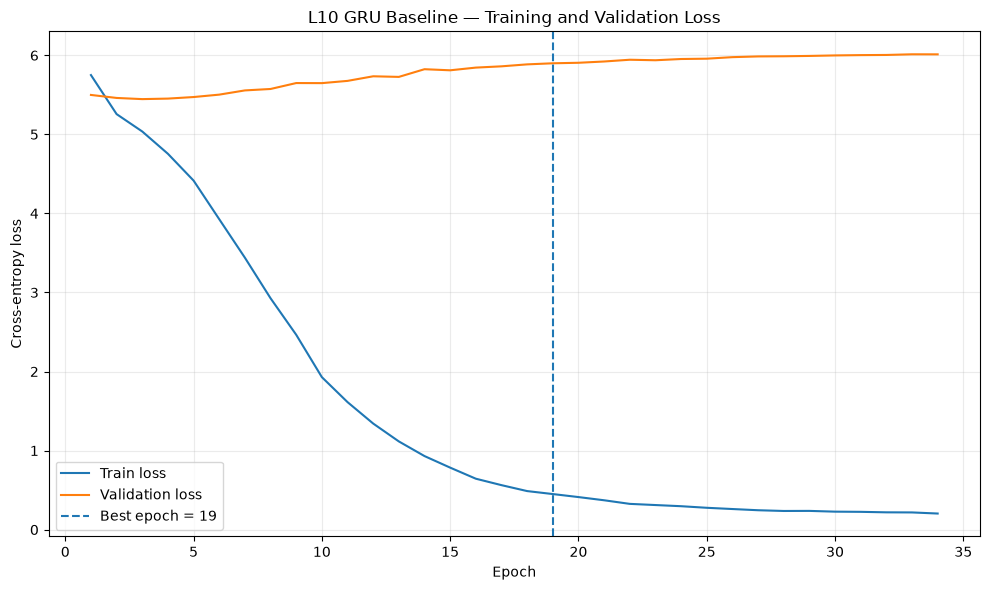

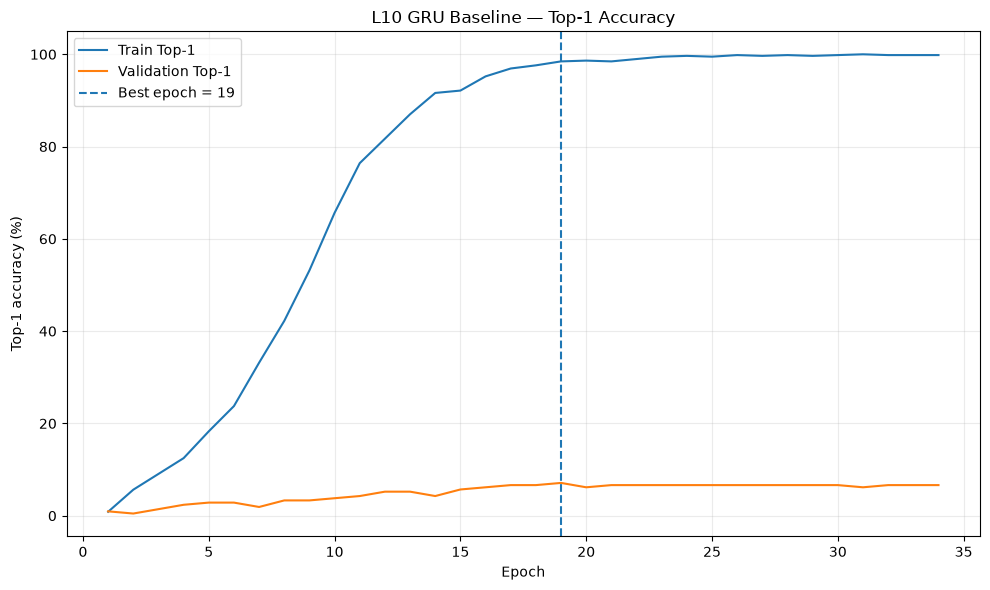


L10 FINAL REPORT

FROZEN DATA
-----------------------------------------------------------------------------------------------------------------------------
Classes               : 211
Train videos          : 585
Validation videos     : 211
Test videos           : 211 (FROZEN — NOT EVALUATED)
Input                 : 32 x 254

PREPROCESSING
-----------------------------------------------------------------------------------------------------------------------------
Statistics fitted on  : TRAIN ONLY
Standardized channels : 0..251
Preserved masks       : 252, 253
Near-zero std dims    : 12
Train std mean        : -0.000000
Train std std         : 0.975908

MODEL
-----------------------------------------------------------------------------------------------------------------------------
Architecture          : GRU
Hidden size           : 256
GRU layers            : 1
Dropout               : 0.3
Parameters            : 447,955

TRAINING
------------------------------------------------------

In [1]:
# ==========================================================================================
# CISLR LANDMARK MODEL — L10
# GRU BASELINE — CONTROLLED 211-CLASS EXPERIMENT
# ==========================================================================================
#
# FROZEN INPUT
# ------------
# L9:
#   Train      = 585 videos
#   Validation = 211 videos
#   Test       = 211 videos
#   Classes    = 211
#
# Representation:
#   32 temporal steps
#   254 features / step
#
#
# IMPORTANT EXPERIMENTAL RULES
# ----------------------------
# 1. L9 split is NEVER regenerated here.
# 2. Feature normalization statistics are fitted using TRAIN ONLY.
# 3. Validation is used for model selection / early stopping.
# 4. TEST IS NOT EVALUATED IN L10.
# 5. The best checkpoint is selected using validation Top-1 accuracy.
# 6. L11 BiLSTM must use the SAME preprocessing and SAME frozen split.
#
#
# MODEL
# -----
# Input:
#       [B, 32, 254]
#
#       ↓
#
# GRU
#
#       ↓
#
# final hidden representation
#
#       ↓
#
# LayerNorm
# Dropout
# Linear
#
#       ↓
#
# 211-class logits
#
#
# OUTPUT
# ------
# audit/l10_gru_baseline/
#
#   models/
#       l10_best_gru.pt
#       l10_last_gru.pt
#
#   preprocessing/
#       l10_train_feature_mean.npy
#       l10_train_feature_std.npy
#
#   reports/
#       l10_training_history.csv
#       l10_validation_predictions.csv
#       l10_summary.json
#       l10_checkpoint.json
#
#   plots/
#       l10_loss_curve.png
#       l10_accuracy_curve.png
#
# ==========================================================================================


# ==========================================================================================
# 0. IMPORTS
# ==========================================================================================

from pathlib import Path

import os
import json
import random
import hashlib
import time
import copy
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torch.utils.data import (
    Dataset,
    DataLoader
)


warnings.filterwarnings("ignore")

pd.set_option(
    "display.max_columns",
    100
)

pd.set_option(
    "display.width",
    250
)

np.set_printoptions(
    precision=6,
    suppress=True
)


# ==========================================================================================
# 1. EXPERIMENT CONFIGURATION
# ==========================================================================================

SEED = 42

SEQUENCE_LENGTH = 32
FEATURE_DIM = 254
NUM_CLASSES = 211

EXPECTED_TRAIN = 585
EXPECTED_VAL = 211
EXPECTED_TEST = 211

# ------------------------------------------------------------------------------------------
# GRU baseline
# ------------------------------------------------------------------------------------------

HIDDEN_SIZE = 256

NUM_GRU_LAYERS = 1

DROPOUT = 0.30

BIDIRECTIONAL = False


# ------------------------------------------------------------------------------------------
# Optimization
# ------------------------------------------------------------------------------------------

BATCH_SIZE = 32

LEARNING_RATE = 1e-3

WEIGHT_DECAY = 1e-4

MAX_EPOCHS = 100

EARLY_STOPPING_PATIENCE = 15

GRAD_CLIP_NORM = 5.0


# ------------------------------------------------------------------------------------------
# LR scheduler
# ------------------------------------------------------------------------------------------

LR_FACTOR = 0.5

LR_PATIENCE = 5

MIN_LR = 1e-6


# ------------------------------------------------------------------------------------------
# DataLoader
# ------------------------------------------------------------------------------------------

NUM_WORKERS = 0

PIN_MEMORY = torch.cuda.is_available()


# ==========================================================================================
# 2. REPRODUCIBILITY
# ==========================================================================================

os.environ[
    "PYTHONHASHSEED"
] = str(
    SEED
)

random.seed(
    SEED
)

np.random.seed(
    SEED
)

torch.manual_seed(
    SEED
)

if torch.cuda.is_available():

    torch.cuda.manual_seed(
        SEED
    )

    torch.cuda.manual_seed_all(
        SEED
    )


# deterministic settings

try:

    torch.use_deterministic_algorithms(
        True
    )

except Exception:

    pass


if torch.backends.cudnn.is_available():

    torch.backends.cudnn.deterministic = True

    torch.backends.cudnn.benchmark = False


# ==========================================================================================
# 3. DEVICE
# ==========================================================================================

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else
    "cpu"
)

print(
    "=" * 125
)

print(
    "CISLR LANDMARK MODEL — L10"
)

print(
    "GRU BASELINE"
)

print(
    "=" * 125
)

print()

print(
    "PyTorch version :",
    torch.__version__
)

print(
    "Device          :",
    DEVICE
)

if torch.cuda.is_available():

    print(
        "GPU             :",
        torch.cuda.get_device_name(
            0
        )
    )

else:

    print(
        "GPU             : Not used"
    )


# ==========================================================================================
# 4. PATHS
# ==========================================================================================

PROJECT_ROOT = Path(
    "/home/dipshikha/Music/cao/CISLR_RESEARCH"
)

LANDMARK_ROOT = (
    PROJECT_ROOT
    /
    "CISLR_LANDMARK_MODEL"
)


# ------------------------------------------------------------------------------------------
# L6 features
# ------------------------------------------------------------------------------------------

FEATURE_DIR = (
    LANDMARK_ROOT
    /
    "audit"
    /
    "l6_full_extraction"
    /
    "features_32x254"
)


# ------------------------------------------------------------------------------------------
# L9
# ------------------------------------------------------------------------------------------

L9_ROOT = (
    LANDMARK_ROOT
    /
    "audit"
    /
    "l9_split_freeze"
)

L9_SPLIT_DIR = (
    L9_ROOT
    /
    "splits"
)

L9_REPORT_DIR = (
    L9_ROOT
    /
    "reports"
)

L9_MAPPING_DIR = (
    L9_ROOT
    /
    "class_mapping"
)


TRAIN_MANIFEST_PATH = (
    L9_SPLIT_DIR
    /
    "l9_train_manifest.csv"
)

VAL_MANIFEST_PATH = (
    L9_SPLIT_DIR
    /
    "l9_validation_manifest.csv"
)

TEST_MANIFEST_PATH = (
    L9_SPLIT_DIR
    /
    "l9_test_manifest.csv"
)

L9_CHECKPOINT_PATH = (
    L9_REPORT_DIR
    /
    "l9_checkpoint.json"
)

L9_FREEZE_PATH = (
    L9_REPORT_DIR
    /
    "l9_freeze_manifest.json"
)

L9_CLASS_MAPPING_PATH = (
    L9_MAPPING_DIR
    /
    "l9_controlled_class_mapping.json"
)


# ==========================================================================================
# 5. L10 OUTPUT PATHS
# ==========================================================================================

L10_ROOT = (
    LANDMARK_ROOT
    /
    "audit"
    /
    "l10_gru_baseline"
)

MODEL_DIR = (
    L10_ROOT
    /
    "models"
)

PREPROCESS_DIR = (
    L10_ROOT
    /
    "preprocessing"
)

REPORT_DIR = (
    L10_ROOT
    /
    "reports"
)

PLOT_DIR = (
    L10_ROOT
    /
    "plots"
)


for directory in [
    L10_ROOT,
    MODEL_DIR,
    PREPROCESS_DIR,
    REPORT_DIR,
    PLOT_DIR
]:

    directory.mkdir(
        parents=True,
        exist_ok=True
    )


BEST_MODEL_PATH = (
    MODEL_DIR
    /
    "l10_best_gru.pt"
)

LAST_MODEL_PATH = (
    MODEL_DIR
    /
    "l10_last_gru.pt"
)

MEAN_PATH = (
    PREPROCESS_DIR
    /
    "l10_train_feature_mean.npy"
)

STD_PATH = (
    PREPROCESS_DIR
    /
    "l10_train_feature_std.npy"
)

HISTORY_PATH = (
    REPORT_DIR
    /
    "l10_training_history.csv"
)

VAL_PREDICTIONS_PATH = (
    REPORT_DIR
    /
    "l10_validation_predictions.csv"
)

SUMMARY_PATH = (
    REPORT_DIR
    /
    "l10_summary.json"
)

CHECKPOINT_PATH = (
    REPORT_DIR
    /
    "l10_checkpoint.json"
)

LOSS_PLOT_PATH = (
    PLOT_DIR
    /
    "l10_loss_curve.png"
)

ACCURACY_PLOT_PATH = (
    PLOT_DIR
    /
    "l10_accuracy_curve.png"
)


# ==========================================================================================
# 6. VERIFY REQUIRED INPUTS
# ==========================================================================================

required_paths = [
    FEATURE_DIR,
    TRAIN_MANIFEST_PATH,
    VAL_MANIFEST_PATH,
    TEST_MANIFEST_PATH,
    L9_CHECKPOINT_PATH,
    L9_FREEZE_PATH,
    L9_CLASS_MAPPING_PATH
]


for path in required_paths:

    if not path.exists():

        raise FileNotFoundError(
            f"Required L10 input missing:\n{path}"
        )


print()

print(
    "[PASS] Required L9/L6 inputs exist."
)


# ==========================================================================================
# 7. VERIFY L9 CHECKPOINT
# ==========================================================================================

with open(
    L9_CHECKPOINT_PATH,
    "r"
) as f:

    l9_checkpoint = json.load(
        f
    )


if not bool(
    l9_checkpoint.get(
        "l9_pass",
        False
    )
):

    raise RuntimeError(
        "L9 checkpoint is not PASS."
    )


with open(
    L9_FREEZE_PATH,
    "r"
) as f:

    l9_freeze = json.load(
        f
    )


if str(
    l9_freeze.get(
        "status",
        ""
    )
).upper() != "FROZEN":

    raise RuntimeError(
        "L9 split is not marked FROZEN."
    )


print(
    "[PASS] L9 checkpoint verified."
)

print(
    "[PASS] L9 frozen split verified."
)


# ==========================================================================================
# 8. LOAD MANIFESTS
# ==========================================================================================

train_manifest = pd.read_csv(
    TRAIN_MANIFEST_PATH
)

val_manifest = pd.read_csv(
    VAL_MANIFEST_PATH
)

# ------------------------------------------------------------------------------------------
# IMPORTANT:
#
# Test manifest is loaded ONLY to verify the frozen population.
#
# We do NOT load test feature tensors.
# We do NOT run inference on test samples.
# We do NOT calculate test accuracy.
# ------------------------------------------------------------------------------------------

test_manifest = pd.read_csv(
    TEST_MANIFEST_PATH
)


print()

print(
    "=" * 125
)

print(
    "FROZEN L9 SPLIT"
)

print(
    "=" * 125
)

print(
    "Train      :",
    len(
        train_manifest
    )
)

print(
    "Validation :",
    len(
        val_manifest
    )
)

print(
    "Test       :",
    len(
        test_manifest
    )
)


if len(
    train_manifest
) != EXPECTED_TRAIN:

    raise RuntimeError(
        "Unexpected train population."
    )


if len(
    val_manifest
) != EXPECTED_VAL:

    raise RuntimeError(
        "Unexpected validation population."
    )


if len(
    test_manifest
) != EXPECTED_TEST:

    raise RuntimeError(
        "Unexpected test population."
    )


# ==========================================================================================
# 9. VERIFY CLASS COVERAGE
# ==========================================================================================

for split_name, dataframe in [

    (
        "train",
        train_manifest
    ),

    (
        "validation",
        val_manifest
    ),

    (
        "test",
        test_manifest
    )
]:

    class_count = dataframe[
        "class_id"
    ].nunique()

    if class_count != NUM_CLASSES:

        raise RuntimeError(
            f"{split_name} contains "
            f"{class_count} classes, expected {NUM_CLASSES}."
        )


print(
    "[PASS] All 211 classes present in all frozen partitions."
)


# ==========================================================================================
# 10. VERIFY NO UID OVERLAP AGAIN
# ==========================================================================================

train_uid_set = set(
    train_manifest[
        "uid_clean"
    ].astype(str)
)

val_uid_set = set(
    val_manifest[
        "uid_clean"
    ].astype(str)
)

test_uid_set = set(
    test_manifest[
        "uid_clean"
    ].astype(str)
)


if (
    train_uid_set
    &
    val_uid_set
):

    raise RuntimeError(
        "Train/validation UID leakage."
    )


if (
    train_uid_set
    &
    test_uid_set
):

    raise RuntimeError(
        "Train/test UID leakage."
    )


if (
    val_uid_set
    &
    test_uid_set
):

    raise RuntimeError(
        "Validation/test UID leakage."
    )


print(
    "[PASS] Zero UID overlap verified."
)


# ==========================================================================================
# 11. LOAD CLASS MAPPING
# ==========================================================================================

with open(
    L9_CLASS_MAPPING_PATH,
    "r"
) as f:

    class_mapping = json.load(
        f
    )


id_to_gloss = {

    int(
        key
    ):
    str(
        value
    )

    for key, value
    in class_mapping[
        "id_to_gloss"
    ].items()
}


if len(
    id_to_gloss
) != NUM_CLASSES:

    raise RuntimeError(
        "Unexpected number of classes "
        "in L9 mapping."
    )


print(
    "[PASS] Loaded frozen 211-class mapping."
)


# ==========================================================================================
# 12. FEATURE LOADER
# ==========================================================================================

def load_feature_array(
    uid
):

    path = (
        FEATURE_DIR
        /
        f"{uid}.npz"
    )

    if not path.exists():

        raise FileNotFoundError(
            f"Feature file missing: {path}"
        )

    with np.load(
        path,
        allow_pickle=True
    ) as data:

        if "features" not in data.files:

            raise KeyError(
                f"'features' missing from {path}"
            )

        features = np.asarray(
            data[
                "features"
            ],
            dtype=np.float32
        )


    if features.shape != (
        SEQUENCE_LENGTH,
        FEATURE_DIM
    ):

        raise RuntimeError(
            f"{uid}: expected "
            f"{(SEQUENCE_LENGTH, FEATURE_DIM)}, "
            f"found {features.shape}"
        )


    if not np.isfinite(
        features
    ).all():

        raise RuntimeError(
            f"{uid}: non-finite features."
        )


    return features


# ==========================================================================================
# 13. LOAD TRAIN FEATURES
# ==========================================================================================

print()

print(
    "=" * 125
)

print(
    "LOADING TRAIN FEATURES"
)

print(
    "=" * 125
)


X_train_raw = np.empty(
    (
        len(
            train_manifest
        ),
        SEQUENCE_LENGTH,
        FEATURE_DIM
    ),
    dtype=np.float32
)


y_train = train_manifest[
    "class_id"
].to_numpy(
    dtype=np.int64
)


for i, row in enumerate(
    train_manifest.itertuples(
        index=False
    )
):

    uid = str(
        row.uid_clean
    )

    X_train_raw[
        i
    ] = load_feature_array(
        uid
    )


print(
    "X_train:",
    X_train_raw.shape
)

print(
    "y_train:",
    y_train.shape
)


# ==========================================================================================
# 14. LOAD VALIDATION FEATURES
# ==========================================================================================

print()

print(
    "=" * 125
)

print(
    "LOADING VALIDATION FEATURES"
)

print(
    "=" * 125
)


X_val_raw = np.empty(
    (
        len(
            val_manifest
        ),
        SEQUENCE_LENGTH,
        FEATURE_DIM
    ),
    dtype=np.float32
)


y_val = val_manifest[
    "class_id"
].to_numpy(
    dtype=np.int64
)


for i, row in enumerate(
    val_manifest.itertuples(
        index=False
    )
):

    uid = str(
        row.uid_clean
    )

    X_val_raw[
        i
    ] = load_feature_array(
        uid
    )


print(
    "X_val:",
    X_val_raw.shape
)

print(
    "y_val:",
    y_val.shape
)


# ==========================================================================================
# 15. TRAIN-ONLY FEATURE STANDARDIZATION
# ==========================================================================================
#
# IMPORTANT:
#
# Statistics are calculated from:
#
#       X_train_raw ONLY
#
# Validation and later test data NEVER contribute.
#
#
# We standardize the 252 continuous channels:
#
#       0 ... 125   normalized landmark XYZ
#       126 ... 251 motion XYZ
#
# We deliberately DO NOT standardize:
#
#       252, 253    hand-presence masks
#
# Those remain binary 0/1.
#
# ==========================================================================================

CONTINUOUS_DIM = 252

MASK_START = 252


train_continuous = X_train_raw[
    :,
    :,
    :CONTINUOUS_DIM
]


feature_mean = train_continuous.mean(
    axis=(
        0,
        1
    )
).astype(
    np.float32
)


feature_std = train_continuous.std(
    axis=(
        0,
        1
    )
).astype(
    np.float32
)


# ------------------------------------------------------------------------------------------
# Protect constant / near-constant dimensions.
# ------------------------------------------------------------------------------------------

STD_EPS = 1e-6

near_zero_std = (
    feature_std
    <
    STD_EPS
)


num_near_zero_std = int(
    near_zero_std.sum()
)


feature_std[
    near_zero_std
] = 1.0


np.save(
    MEAN_PATH,
    feature_mean
)

np.save(
    STD_PATH,
    feature_std
)


print()

print(
    "=" * 125
)

print(
    "TRAIN-ONLY STANDARDIZATION"
)

print(
    "=" * 125
)

print(
    "Continuous dimensions :",
    CONTINUOUS_DIM
)

print(
    "Mask dimensions       :",
    FEATURE_DIM
    -
    CONTINUOUS_DIM
)

print(
    "Near-zero std dims    :",
    num_near_zero_std
)

print(
    "Mean shape            :",
    feature_mean.shape
)

print(
    "Std shape             :",
    feature_std.shape
)

print(
    "Mean range            :",
    float(
        feature_mean.min()
    ),
    "to",
    float(
        feature_mean.max()
    )
)

print(
    "Std range             :",
    float(
        feature_std.min()
    ),
    "to",
    float(
        feature_std.max()
    )
)


# ==========================================================================================
# 16. APPLY STANDARDIZATION
# ==========================================================================================

def apply_standardization(
    X
):

    X = X.copy().astype(
        np.float32
    )

    X[
        :,
        :,
        :CONTINUOUS_DIM
    ] = (

        X[
            :,
            :,
            :CONTINUOUS_DIM
        ]

        -

        feature_mean[
            None,
            None,
            :
        ]

    ) / (

        feature_std[
            None,
            None,
            :
        ]

    )


    # ------------------------------------------------------------------
    # Preserve mask dimensions EXACTLY as the original binary values.
    # ------------------------------------------------------------------

    X[
        :,
        :,
        MASK_START:
    ] = X[
        :,
        :,
        MASK_START:
    ]


    return X


X_train = apply_standardization(
    X_train_raw
)

X_val = apply_standardization(
    X_val_raw
)


if not np.isfinite(
    X_train
).all():

    raise RuntimeError(
        "Non-finite values after train standardization."
    )


if not np.isfinite(
    X_val
).all():

    raise RuntimeError(
        "Non-finite values after validation standardization."
    )


print()

print(
    "[PASS] Train-only standardization applied."
)


# ==========================================================================================
# 17. VERIFY MASK CHANNELS WERE NOT CHANGED
# ==========================================================================================

train_mask_preserved = np.array_equal(

    X_train[
        :,
        :,
        MASK_START:
    ],

    X_train_raw[
        :,
        :,
        MASK_START:
    ]
)


val_mask_preserved = np.array_equal(

    X_val[
        :,
        :,
        MASK_START:
    ],

    X_val_raw[
        :,
        :,
        MASK_START:
    ]
)


if not (
    train_mask_preserved
    and
    val_mask_preserved
):

    raise RuntimeError(
        "Hand-presence masks changed during preprocessing."
    )


print(
    "[PASS] Hand-presence masks preserved exactly."
)


# ==========================================================================================
# 18. STANDARDIZATION DIAGNOSTIC
# ==========================================================================================

train_standardized_mean = float(

    X_train[
        :,
        :,
        :CONTINUOUS_DIM
    ].mean()
)


train_standardized_std = float(

    X_train[
        :,
        :,
        :CONTINUOUS_DIM
    ].std()
)


val_standardized_mean = float(

    X_val[
        :,
        :,
        :CONTINUOUS_DIM
    ].mean()
)


val_standardized_std = float(

    X_val[
        :,
        :,
        :CONTINUOUS_DIM
    ].std()
)


print()

print(
    "Train standardized mean :",
    f"{train_standardized_mean:.6f}"
)

print(
    "Train standardized std  :",
    f"{train_standardized_std:.6f}"
)

print(
    "Val standardized mean   :",
    f"{val_standardized_mean:.6f}"
)

print(
    "Val standardized std    :",
    f"{val_standardized_std:.6f}"
)


# ==========================================================================================
# 19. DATASET
# ==========================================================================================

class LandmarkSequenceDataset(
    Dataset
):

    def __init__(
        self,
        X,
        y
    ):

        self.X = torch.from_numpy(
            X
        ).float()

        self.y = torch.from_numpy(
            y
        ).long()


    def __len__(
        self
    ):

        return len(
            self.y
        )


    def __getitem__(
        self,
        index
    ):

        return (
            self.X[
                index
            ],
            self.y[
                index
            ]
        )


train_dataset = LandmarkSequenceDataset(
    X_train,
    y_train
)

val_dataset = LandmarkSequenceDataset(
    X_val,
    y_val
)


# ==========================================================================================
# 20. DATALOADERS
# ==========================================================================================

loader_generator = torch.Generator()

loader_generator.manual_seed(
    SEED
)


train_loader = DataLoader(

    train_dataset,

    batch_size=
        BATCH_SIZE,

    shuffle=
        True,

    num_workers=
        NUM_WORKERS,

    pin_memory=
        PIN_MEMORY,

    generator=
        loader_generator
)


val_loader = DataLoader(

    val_dataset,

    batch_size=
        BATCH_SIZE,

    shuffle=
        False,

    num_workers=
        NUM_WORKERS,

    pin_memory=
        PIN_MEMORY
)


print()

print(
    "=" * 125
)

print(
    "DATALOADERS"
)

print(
    "=" * 125
)

print(
    "Train batches      :",
    len(
        train_loader
    )
)

print(
    "Validation batches :",
    len(
        val_loader
    )
)


# ==========================================================================================
# 21. GRU BASELINE MODEL
# ==========================================================================================

class GRUBaseline(
    nn.Module
):

    def __init__(
        self,
        input_dim,
        hidden_size,
        num_layers,
        num_classes,
        dropout
    ):

        super().__init__()


        self.gru = nn.GRU(

            input_size=
                input_dim,

            hidden_size=
                hidden_size,

            num_layers=
                num_layers,

            batch_first=
                True,

            bidirectional=
                False,

            dropout=
                dropout
                if num_layers > 1
                else 0.0
        )


        self.layer_norm = nn.LayerNorm(
            hidden_size
        )


        self.dropout = nn.Dropout(
            dropout
        )


        self.classifier = nn.Linear(
            hidden_size,
            num_classes
        )


    def forward(
        self,
        x
    ):

        # x:
        # [B, 32, 254]

        output, hidden = self.gru(
            x
        )


        # hidden:
        # [num_layers, B, hidden_size]

        final_hidden = hidden[
            -1
        ]


        final_hidden = self.layer_norm(
            final_hidden
        )


        final_hidden = self.dropout(
            final_hidden
        )


        logits = self.classifier(
            final_hidden
        )


        return logits


model = GRUBaseline(

    input_dim=
        FEATURE_DIM,

    hidden_size=
        HIDDEN_SIZE,

    num_layers=
        NUM_GRU_LAYERS,

    num_classes=
        NUM_CLASSES,

    dropout=
        DROPOUT
)


model = model.to(
    DEVICE
)


# ==========================================================================================
# 22. MODEL SUMMARY
# ==========================================================================================

total_parameters = sum(

    p.numel()

    for p
    in model.parameters()
)


trainable_parameters = sum(

    p.numel()

    for p
    in model.parameters()

    if p.requires_grad
)


print()

print(
    "=" * 125
)

print(
    "GRU BASELINE ARCHITECTURE"
)

print(
    "=" * 125
)

print(
    model
)

print()

print(
    "Total parameters     :",
    f"{total_parameters:,}"
)

print(
    "Trainable parameters :",
    f"{trainable_parameters:,}"
)


# ==========================================================================================
# 23. LOSS
# ==========================================================================================
#
# We deliberately use standard CrossEntropyLoss.
#
# No class weights are used in the primary baseline.
#
# Reason:
# The controlled population already restricts the experiment to
# support >= 4, and L10 is intended to remain a simple reproducible
# baseline.
#
# ==========================================================================================

criterion = nn.CrossEntropyLoss()


# ==========================================================================================
# 24. OPTIMIZER
# ==========================================================================================

optimizer = torch.optim.AdamW(

    model.parameters(),

    lr=
        LEARNING_RATE,

    weight_decay=
        WEIGHT_DECAY
)


# ==========================================================================================
# 25. SCHEDULER
# ==========================================================================================

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(

    optimizer,

    mode=
        "min",

    factor=
        LR_FACTOR,

    patience=
        LR_PATIENCE,

    min_lr=
        MIN_LR
)


# ==========================================================================================
# 26. METRIC FUNCTIONS
# ==========================================================================================

def topk_correct_counts(
    logits,
    targets,
    topk=(
        1,
        5
    )
):

    max_k = min(
        max(
            topk
        ),
        logits.shape[
            1
        ]
    )


    _, pred = logits.topk(
        max_k,
        dim=1,
        largest=True,
        sorted=True
    )


    pred = pred.t()


    correct = pred.eq(
        targets.view(
            1,
            -1
        ).expand_as(
            pred
        )
    )


    result = {}


    for k in topk:

        k_eff = min(
            k,
            logits.shape[
                1
            ]
        )

        result[
            k
        ] = int(

            correct[
                :k_eff
            ]
            .reshape(
                -1
            )
            .float()
            .sum()
            .item()
        )


    return result


# ==========================================================================================
# 27. TRAIN ONE EPOCH
# ==========================================================================================

def train_one_epoch(
    model,
    loader,
    optimizer,
    criterion,
    device
):

    model.train()


    running_loss = 0.0

    total_samples = 0

    top1_correct = 0

    top5_correct = 0


    for X_batch, y_batch in loader:

        X_batch = X_batch.to(
            device,
            non_blocking=True
        )

        y_batch = y_batch.to(
            device,
            non_blocking=True
        )


        optimizer.zero_grad(
            set_to_none=True
        )


        logits = model(
            X_batch
        )


        loss = criterion(
            logits,
            y_batch
        )


        loss.backward()


        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            GRAD_CLIP_NORM
        )


        optimizer.step()


        batch_size = y_batch.size(
            0
        )


        running_loss += (
            loss.item()
            *
            batch_size
        )


        counts = topk_correct_counts(

            logits,
            y_batch,
            topk=(
                1,
                5
            )
        )


        top1_correct += counts[
            1
        ]

        top5_correct += counts[
            5
        ]


        total_samples += batch_size


    epoch_loss = (
        running_loss
        /
        total_samples
    )


    top1 = (
        top1_correct
        /
        total_samples
    )


    top5 = (
        top5_correct
        /
        total_samples
    )


    return (
        epoch_loss,
        top1,
        top5
    )


# ==========================================================================================
# 28. VALIDATE
# ==========================================================================================

@torch.no_grad()
def evaluate(
    model,
    loader,
    criterion,
    device
):

    model.eval()


    running_loss = 0.0

    total_samples = 0

    top1_correct = 0

    top5_correct = 0


    all_logits = []

    all_targets = []


    for X_batch, y_batch in loader:

        X_batch = X_batch.to(
            device,
            non_blocking=True
        )

        y_batch = y_batch.to(
            device,
            non_blocking=True
        )


        logits = model(
            X_batch
        )


        loss = criterion(
            logits,
            y_batch
        )


        batch_size = y_batch.size(
            0
        )


        running_loss += (
            loss.item()
            *
            batch_size
        )


        counts = topk_correct_counts(

            logits,
            y_batch,
            topk=(
                1,
                5
            )
        )


        top1_correct += counts[
            1
        ]

        top5_correct += counts[
            5
        ]


        total_samples += batch_size


        all_logits.append(
            logits.detach().cpu()
        )

        all_targets.append(
            y_batch.detach().cpu()
        )


    epoch_loss = (
        running_loss
        /
        total_samples
    )


    top1 = (
        top1_correct
        /
        total_samples
    )


    top5 = (
        top5_correct
        /
        total_samples
    )


    logits_all = torch.cat(
        all_logits,
        dim=0
    )


    targets_all = torch.cat(
        all_targets,
        dim=0
    )


    return (
        epoch_loss,
        top1,
        top5,
        logits_all,
        targets_all
    )


# ==========================================================================================
# 29. CHECKPOINT SAVE FUNCTION
# ==========================================================================================

def save_checkpoint(
    path,
    epoch,
    model,
    optimizer,
    scheduler,
    val_loss,
    val_top1,
    val_top5
):

    checkpoint = {

        "stage":
            "L10_GRU_BASELINE",

        "epoch":
            int(
                epoch
            ),

        "model_state_dict":
            model.state_dict(),

        "optimizer_state_dict":
            optimizer.state_dict(),

        "scheduler_state_dict":
            scheduler.state_dict(),

        "model_config":
            {
                "input_dim":
                    FEATURE_DIM,

                "sequence_length":
                    SEQUENCE_LENGTH,

                "hidden_size":
                    HIDDEN_SIZE,

                "num_layers":
                    NUM_GRU_LAYERS,

                "num_classes":
                    NUM_CLASSES,

                "dropout":
                    DROPOUT,

                "bidirectional":
                    False
            },

        "preprocessing":
            {
                "continuous_dimensions":
                    CONTINUOUS_DIM,

                "mask_dimensions":
                    [
                        252,
                        253
                    ],

                "mean_path":
                    str(
                        MEAN_PATH
                    ),

                "std_path":
                    str(
                        STD_PATH
                    ),

                "fitted_on":
                    "TRAIN_ONLY"
            },

        "validation":
            {
                "loss":
                    float(
                        val_loss
                    ),

                "top1":
                    float(
                        val_top1
                    ),

                "top5":
                    float(
                        val_top5
                    )
            },

        "seed":
            SEED
    }


    torch.save(
        checkpoint,
        path
    )


# ==========================================================================================
# 30. TRAINING
# ==========================================================================================

print()

print(
    "=" * 125
)

print(
    "STARTING L10 GRU TRAINING"
)

print(
    "=" * 125
)

print(
    "Maximum epochs          :",
    MAX_EPOCHS
)

print(
    "Early stopping patience :",
    EARLY_STOPPING_PATIENCE
)

print(
    "Batch size              :",
    BATCH_SIZE
)

print(
    "Learning rate           :",
    LEARNING_RATE
)

print(
    "Weight decay            :",
    WEIGHT_DECAY
)

print(
    "Gradient clipping       :",
    GRAD_CLIP_NORM
)

print()

print(
    "MODEL SELECTION:"
)

print(
    "Highest validation Top-1 accuracy."
)

print(
    "Validation loss is used as the tie-breaker."
)

print()


history = []


best_epoch = 0

best_val_top1 = -1.0

best_val_loss = float(
    "inf"
)

best_val_top5 = -1.0


epochs_without_improvement = 0


training_start_time = time.perf_counter()


for epoch in range(
    1,
    MAX_EPOCHS + 1
):

    epoch_start = time.perf_counter()


    # --------------------------------------------------------------------------------------
    # Train
    # --------------------------------------------------------------------------------------

    (
        train_loss,
        train_top1,
        train_top5
    ) = train_one_epoch(

        model,
        train_loader,
        optimizer,
        criterion,
        DEVICE
    )


    # --------------------------------------------------------------------------------------
    # Validation
    # --------------------------------------------------------------------------------------

    (
        val_loss,
        val_top1,
        val_top5,
        _,
        _
    ) = evaluate(

        model,
        val_loader,
        criterion,
        DEVICE
    )


    # --------------------------------------------------------------------------------------
    # Scheduler uses validation loss only.
    # --------------------------------------------------------------------------------------

    scheduler.step(
        val_loss
    )


    current_lr = float(
        optimizer.param_groups[
            0
        ][
            "lr"
        ]
    )


    epoch_seconds = (
        time.perf_counter()
        -
        epoch_start
    )


    # --------------------------------------------------------------------------------------
    # Model-selection criterion
    # --------------------------------------------------------------------------------------

    improved = False


    if val_top1 > best_val_top1:

        improved = True


    elif np.isclose(
        val_top1,
        best_val_top1
    ) and val_loss < best_val_loss:

        improved = True


    if improved:

        best_epoch = epoch

        best_val_top1 = val_top1

        best_val_top5 = val_top5

        best_val_loss = val_loss

        epochs_without_improvement = 0


        save_checkpoint(

            BEST_MODEL_PATH,

            epoch,

            model,

            optimizer,

            scheduler,

            val_loss,

            val_top1,

            val_top5
        )


    else:

        epochs_without_improvement += 1


    # --------------------------------------------------------------------------------------
    # History
    # --------------------------------------------------------------------------------------

    history.append(
        {
            "epoch":
                epoch,

            "train_loss":
                train_loss,

            "train_top1":
                train_top1,

            "train_top5":
                train_top5,

            "val_loss":
                val_loss,

            "val_top1":
                val_top1,

            "val_top5":
                val_top5,

            "learning_rate":
                current_lr,

            "epoch_seconds":
                epoch_seconds,

            "best_so_far":
                improved
        }
    )


    print(

        f"Epoch {epoch:03d}/{MAX_EPOCHS} | "

        f"train loss={train_loss:.4f} | "
        f"Top1={100.0 * train_top1:6.2f}% | "
        f"Top5={100.0 * train_top5:6.2f}% || "

        f"val loss={val_loss:.4f} | "
        f"Top1={100.0 * val_top1:6.2f}% | "
        f"Top5={100.0 * val_top5:6.2f}% | "

        f"lr={current_lr:.2e} | "

        f"{epoch_seconds:.2f}s"

        +

        (
            "  <-- BEST"
            if improved
            else ""
        )
    )


    # --------------------------------------------------------------------------------------
    # Early stopping
    # --------------------------------------------------------------------------------------

    if (
        epochs_without_improvement
        >=
        EARLY_STOPPING_PATIENCE
    ):

        print()

        print(
            "[EARLY STOPPING]"
        )

        print(
            f"No validation Top-1 improvement for "
            f"{EARLY_STOPPING_PATIENCE} epochs."
        )

        break


total_training_seconds = (
    time.perf_counter()
    -
    training_start_time
)


epochs_completed = len(
    history
)


# ==========================================================================================
# 31. SAVE LAST MODEL
# ==========================================================================================

save_checkpoint(

    LAST_MODEL_PATH,

    epochs_completed,

    model,

    optimizer,

    scheduler,

    history[
        -1
    ][
        "val_loss"
    ],

    history[
        -1
    ][
        "val_top1"
    ],

    history[
        -1
    ][
        "val_top5"
    ]
)


# ==========================================================================================
# 32. SAVE TRAINING HISTORY
# ==========================================================================================

history_df = pd.DataFrame(
    history
)


history_df.to_csv(
    HISTORY_PATH,
    index=False
)


# ==========================================================================================
# 33. LOAD BEST MODEL
# ==========================================================================================

if not BEST_MODEL_PATH.exists():

    raise RuntimeError(
        "Best GRU checkpoint was not created."
    )


best_checkpoint = torch.load(

    BEST_MODEL_PATH,

    map_location=
        DEVICE
)


model.load_state_dict(
    best_checkpoint[
        "model_state_dict"
    ]
)


model.eval()


print()

print(
    "[PASS] Reloaded best GRU checkpoint."
)


# ==========================================================================================
# 34. FINAL VALIDATION EVALUATION OF BEST MODEL
# ==========================================================================================

(
    final_val_loss,
    final_val_top1,
    final_val_top5,
    final_val_logits,
    final_val_targets
) = evaluate(

    model,
    val_loader,
    criterion,
    DEVICE
)


print()

print(
    "=" * 125
)

print(
    "BEST MODEL — VALIDATION RESULT"
)

print(
    "=" * 125
)

print(
    "Best epoch          :",
    best_epoch
)

print(
    "Validation loss     :",
    f"{final_val_loss:.6f}"
)

print(
    "Validation Top-1    :",
    f"{100.0 * final_val_top1:.2f}%"
)

print(
    "Validation Top-5    :",
    f"{100.0 * final_val_top5:.2f}%"
)


# ==========================================================================================
# 35. RANDOM-CHANCE REFERENCE
# ==========================================================================================

chance_top1 = (
    1.0
    /
    NUM_CLASSES
)


chance_top5 = (
    5.0
    /
    NUM_CLASSES
)


print()

print(
    "Chance Top-1        :",
    f"{100.0 * chance_top1:.3f}%"
)

print(
    "Chance Top-5        :",
    f"{100.0 * chance_top5:.3f}%"
)


# ==========================================================================================
# 36. VALIDATION PREDICTIONS
# ==========================================================================================

val_probabilities = torch.softmax(

    final_val_logits,

    dim=1
)


top5_probabilities, top5_indices = torch.topk(

    val_probabilities,

    k=5,

    dim=1
)


prediction_rows = []


for i in range(
    len(
        val_manifest
    )
):

    uid = str(
        val_manifest.iloc[
            i
        ][
            "uid_clean"
        ]
    )


    true_id = int(
        final_val_targets[
            i
        ].item()
    )


    true_gloss = id_to_gloss[
        true_id
    ]


    predicted_ids = [

        int(
            x
        )

        for x
        in top5_indices[
            i
        ].tolist()
    ]


    predicted_probs = [

        float(
            x
        )

        for x
        in top5_probabilities[
            i
        ].tolist()
    ]


    top1_id = predicted_ids[
        0
    ]


    top1_gloss = id_to_gloss[
        top1_id
    ]


    top1_correct = (
        top1_id
        ==
        true_id
    )


    top5_correct = (
        true_id
        in
        predicted_ids
    )


    row = {

        "uid":
            uid,

        "true_class_id":
            true_id,

        "true_gloss":
            true_gloss,

        "predicted_class_id":
            top1_id,

        "predicted_gloss":
            top1_gloss,

        "top1_probability":
            predicted_probs[
                0
            ],

        "top1_correct":
            top1_correct,

        "top5_correct":
            top5_correct
    }


    for rank in range(
        5
    ):

        class_id = predicted_ids[
            rank
        ]

        probability = predicted_probs[
            rank
        ]


        row[
            f"rank_{rank + 1}_class_id"
        ] = class_id


        row[
            f"rank_{rank + 1}_gloss"
        ] = id_to_gloss[
            class_id
        ]


        row[
            f"rank_{rank + 1}_probability"
        ] = probability


    prediction_rows.append(
        row
    )


val_predictions_df = pd.DataFrame(
    prediction_rows
)


val_predictions_df.to_csv(
    VAL_PREDICTIONS_PATH,
    index=False
)


# ==========================================================================================
# 37. VALIDATION ERROR SUMMARY
# ==========================================================================================

num_val_top1_correct = int(

    val_predictions_df[
        "top1_correct"
    ].sum()
)


num_val_top5_correct = int(

    val_predictions_df[
        "top5_correct"
    ].sum()
)


print()

print(
    "Validation Top-1 correct:",
    num_val_top1_correct,
    "/",
    len(
        val_predictions_df
    )
)

print(
    "Validation Top-5 correct:",
    num_val_top5_correct,
    "/",
    len(
        val_predictions_df
    )
)


# ==========================================================================================
# 38. TRAINING CURVES — LOSS
# ==========================================================================================

plt.figure(
    figsize=(
        10,
        6
    )
)


plt.plot(
    history_df[
        "epoch"
    ],
    history_df[
        "train_loss"
    ],
    label=
        "Train loss"
)


plt.plot(
    history_df[
        "epoch"
    ],
    history_df[
        "val_loss"
    ],
    label=
        "Validation loss"
)


plt.axvline(
    best_epoch,
    linestyle=
        "--",
    label=
        f"Best epoch = {best_epoch}"
)


plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Cross-entropy loss"
)

plt.title(
    "L10 GRU Baseline — Training and Validation Loss"
)

plt.legend()

plt.grid(
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    LOSS_PLOT_PATH,
    dpi=160
)

plt.show()

plt.close()


# ==========================================================================================
# 39. TRAINING CURVES — TOP-1 ACCURACY
# ==========================================================================================

plt.figure(
    figsize=(
        10,
        6
    )
)


plt.plot(
    history_df[
        "epoch"
    ],
    100.0
    *
    history_df[
        "train_top1"
    ],
    label=
        "Train Top-1"
)


plt.plot(
    history_df[
        "epoch"
    ],
    100.0
    *
    history_df[
        "val_top1"
    ],
    label=
        "Validation Top-1"
)


plt.axvline(
    best_epoch,
    linestyle=
        "--",
    label=
        f"Best epoch = {best_epoch}"
)


plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Top-1 accuracy (%)"
)

plt.title(
    "L10 GRU Baseline — Top-1 Accuracy"
)

plt.legend()

plt.grid(
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    ACCURACY_PLOT_PATH,
    dpi=160
)

plt.show()

plt.close()


# ==========================================================================================
# 40. MODEL FILE HASH
# ==========================================================================================

def sha256_file(
    path
):

    sha = hashlib.sha256()


    with open(
        path,
        "rb"
    ) as f:

        while True:

            chunk = f.read(
                1024
                *
                1024
            )


            if not chunk:

                break


            sha.update(
                chunk
            )


    return sha.hexdigest()


best_model_sha256 = sha256_file(
    BEST_MODEL_PATH
)


mean_sha256 = sha256_file(
    MEAN_PATH
)


std_sha256 = sha256_file(
    STD_PATH
)


# ==========================================================================================
# 41. SUMMARY
# ==========================================================================================

summary = {

    "stage":
        "L10_GRU_BASELINE",

    "status":
        "COMPLETE",

    "seed":
        SEED,

    "device":
        str(
            DEVICE
        ),

    "population":
        {
            "classes":
                NUM_CLASSES,

            "train":
                len(
                    train_manifest
                ),

            "validation":
                len(
                    val_manifest
                ),

            "test_frozen_not_evaluated":
                len(
                    test_manifest
                )
        },

    "representation":
        {
            "sequence_length":
                SEQUENCE_LENGTH,

            "feature_dim":
                FEATURE_DIM,

            "continuous_dimensions_standardized":
                CONTINUOUS_DIM,

            "mask_dimensions_not_standardized":
                [
                    252,
                    253
                ]
        },

    "preprocessing":
        {
            "statistics_fitted_on":
                "TRAIN_ONLY",

            "near_zero_std_dimensions":
                num_near_zero_std,

            "mean_sha256":
                mean_sha256,

            "std_sha256":
                std_sha256
        },

    "model":
        {
            "type":
                "GRU",

            "hidden_size":
                HIDDEN_SIZE,

            "num_layers":
                NUM_GRU_LAYERS,

            "dropout":
                DROPOUT,

            "bidirectional":
                False,

            "total_parameters":
                total_parameters,

            "trainable_parameters":
                trainable_parameters
        },

    "training":
        {
            "batch_size":
                BATCH_SIZE,

            "initial_learning_rate":
                LEARNING_RATE,

            "weight_decay":
                WEIGHT_DECAY,

            "max_epochs":
                MAX_EPOCHS,

            "epochs_completed":
                epochs_completed,

            "early_stopping_patience":
                EARLY_STOPPING_PATIENCE,

            "best_epoch":
                best_epoch,

            "training_seconds":
                total_training_seconds
        },

    "validation":
        {
            "loss":
                float(
                    final_val_loss
                ),

            "top1":
                float(
                    final_val_top1
                ),

            "top1_percent":
                float(
                    100.0
                    *
                    final_val_top1
                ),

            "top5":
                float(
                    final_val_top5
                ),

            "top5_percent":
                float(
                    100.0
                    *
                    final_val_top5
                ),

            "top1_correct":
                num_val_top1_correct,

            "top5_correct":
                num_val_top5_correct,

            "samples":
                len(
                    val_manifest
                )
        },

    "chance_reference":
        {
            "top1_percent":
                float(
                    100.0
                    *
                    chance_top1
                ),

            "top5_percent":
                float(
                    100.0
                    *
                    chance_top5
                )
        },

    "test_evaluated":
        False,

    "best_model":
        {
            "path":
                str(
                    BEST_MODEL_PATH
                ),

            "sha256":
                best_model_sha256
        }
}


with open(
    SUMMARY_PATH,
    "w"
) as f:

    json.dump(
        summary,
        f,
        indent=4
    )


# ==========================================================================================
# 42. L10 CHECKPOINT
# ==========================================================================================

preprocessing_pass = bool(

    np.isfinite(
        feature_mean
    ).all()

    and

    np.isfinite(
        feature_std
    ).all()

    and

    np.isfinite(
        X_train
    ).all()

    and

    np.isfinite(
        X_val
    ).all()

    and

    train_mask_preserved

    and

    val_mask_preserved
)


model_checkpoint_pass = bool(

    BEST_MODEL_PATH.exists()

    and

    LAST_MODEL_PATH.exists()
)


validation_pass = bool(

    np.isfinite(
        final_val_loss
    )

    and

    np.isfinite(
        final_val_top1
    )

    and

    np.isfinite(
        final_val_top5
    )
)


test_untouched_pass = True


l10_pass = bool(

    bool(
        l9_checkpoint.get(
            "l9_pass",
            False
        )
    )

    and

    preprocessing_pass

    and

    model_checkpoint_pass

    and

    validation_pass

    and

    test_untouched_pass
)


checkpoint = {

    "l9_pass_verified":
        bool(
            l9_checkpoint.get(
                "l9_pass",
                False
            )
        ),

    "train_only_preprocessing":
        True,

    "preprocessing_integrity":
        preprocessing_pass,

    "train_mask_preserved":
        train_mask_preserved,

    "validation_mask_preserved":
        val_mask_preserved,

    "best_model_saved":
        BEST_MODEL_PATH.exists(),

    "last_model_saved":
        LAST_MODEL_PATH.exists(),

    "validation_metrics_finite":
        validation_pass,

    "test_features_loaded":
        False,

    "test_evaluated":
        False,

    "l10_pass":
        l10_pass
}


with open(
    CHECKPOINT_PATH,
    "w"
) as f:

    json.dump(
        checkpoint,
        f,
        indent=4
    )


# ==========================================================================================
# 43. FINAL REPORT
# ==========================================================================================

print()

print(
    "=" * 125
)

print(
    "L10 FINAL REPORT"
)

print(
    "=" * 125
)


print()

print(
    "FROZEN DATA"
)

print(
    "-" * 125
)

print(
    "Classes               :",
    NUM_CLASSES
)

print(
    "Train videos          :",
    len(
        train_manifest
    )
)

print(
    "Validation videos     :",
    len(
        val_manifest
    )
)

print(
    "Test videos           :",
    len(
        test_manifest
    ),
    "(FROZEN — NOT EVALUATED)"
)

print(
    "Input                 :",
    f"{SEQUENCE_LENGTH} x {FEATURE_DIM}"
)


print()

print(
    "PREPROCESSING"
)

print(
    "-" * 125
)

print(
    "Statistics fitted on  : TRAIN ONLY"
)

print(
    "Standardized channels : 0..251"
)

print(
    "Preserved masks       : 252, 253"
)

print(
    "Near-zero std dims    :",
    num_near_zero_std
)

print(
    "Train std mean        :",
    f"{train_standardized_mean:.6f}"
)

print(
    "Train std std         :",
    f"{train_standardized_std:.6f}"
)


print()

print(
    "MODEL"
)

print(
    "-" * 125
)

print(
    "Architecture          : GRU"
)

print(
    "Hidden size           :",
    HIDDEN_SIZE
)

print(
    "GRU layers            :",
    NUM_GRU_LAYERS
)

print(
    "Dropout               :",
    DROPOUT
)

print(
    "Parameters            :",
    f"{total_parameters:,}"
)


print()

print(
    "TRAINING"
)

print(
    "-" * 125
)

print(
    "Epochs completed      :",
    epochs_completed
)

print(
    "Best epoch            :",
    best_epoch
)

print(
    "Training time         :",
    f"{total_training_seconds:.2f} sec"
)


print()

print(
    "BEST VALIDATION RESULT"
)

print(
    "-" * 125
)

print(
    "Loss                  :",
    f"{final_val_loss:.6f}"
)

print(
    "Top-1                 :",
    f"{100.0 * final_val_top1:.2f}%"
)

print(
    "Top-5                 :",
    f"{100.0 * final_val_top5:.2f}%"
)

print(
    "Top-1 correct         :",
    f"{num_val_top1_correct}/{len(val_manifest)}"
)

print(
    "Top-5 correct         :",
    f"{num_val_top5_correct}/{len(val_manifest)}"
)

print()

print(
    "Random chance Top-1   :",
    f"{100.0 * chance_top1:.3f}%"
)

print(
    "Random chance Top-5   :",
    f"{100.0 * chance_top5:.3f}%"
)


print()

print(
    "TEST SET"
)

print(
    "-" * 125
)

print(
    "Test features loaded  : NO"
)

print(
    "Test evaluated        : NO"
)

print(
    "Reason                : Reserved for L13 final held-out evaluation."
)


# ==========================================================================================
# 44. CHECKPOINT REPORT
# ==========================================================================================

print()

print(
    "=" * 125
)

print(
    "L10 CHECKPOINT"
)

print(
    "=" * 125
)


if l10_pass:

    print()

    print(
        "[PASS] L10 GRU BASELINE COMPLETE."
    )

    print()

    print(
        "The GRU was trained only on the frozen L9 training partition."
    )

    print(
        "Preprocessing statistics were fitted using TRAIN ONLY."
    )

    print(
        "Model selection used VALIDATION ONLY."
    )

    print(
        "The TEST partition remains untouched."
    )

    print()

    print(
        "DO NOT select the final architecture yet."
    )

    print(
        "NEXT STAGE: L11 — BiLSTM"
    )

else:

    print()

    print(
        "[REVIEW] L10 FAILED ONE OR MORE CHECKPOINT CONDITIONS."
    )

    print()

    print(
        "Do NOT proceed to L11."
    )


# ==========================================================================================
# 45. OUTPUT PATHS
# ==========================================================================================

print()

print(
    "=" * 125
)

print(
    "L10 OUTPUT FILES"
)

print(
    "=" * 125
)


print()

print(
    "BEST GRU"
)

print(
    BEST_MODEL_PATH
)


print()

print(
    "LAST GRU"
)

print(
    LAST_MODEL_PATH
)


print()

print(
    "TRAIN FEATURE MEAN"
)

print(
    MEAN_PATH
)


print()

print(
    "TRAIN FEATURE STD"
)

print(
    STD_PATH
)


print()

print(
    "TRAINING HISTORY"
)

print(
    HISTORY_PATH
)


print()

print(
    "VALIDATION PREDICTIONS"
)

print(
    VAL_PREDICTIONS_PATH
)


print()

print(
    "LOSS CURVE"
)

print(
    LOSS_PLOT_PATH
)


print()

print(
    "ACCURACY CURVE"
)

print(
    ACCURACY_PLOT_PATH
)


print()

print(
    "SUMMARY"
)

print(
    SUMMARY_PATH
)


print()

print(
    "CHECKPOINT"
)

print(
    CHECKPOINT_PATH
)


print()

print(
    "=" * 125
)

CISLR LANDMARK MODEL — L10.2
ENHANCED SKELETON-MOTION REPRESENTATION + REGULARIZED GRU

PyTorch version : 2.14.0+cu130
Device          : cuda
GPU             : NVIDIA GeForce RTX 4050 Laptop GPU

[PASS] Required L6/L9/L10 files exist.
[PASS] L9 split verified.
[PASS] L10 baseline verified.

L10.0 baseline Top-1 : 7.11%
L10.0 baseline Top-5 : 13.74%

FROZEN L9 POPULATION
Train      : 585
Validation : 211
Test       : 211 (LOCKED)
[PASS] Zero UID overlap.

ENHANCED SKELETON REPRESENTATION
Sequence length      : 32
Old feature dim      : 254
Enhanced feature dim : 617
Sample shape         : (32, 617)

Building TRAIN enhanced features...
  100/585
  200/585
  300/585
  400/585
  500/585
  585/585
[DONE] TRAIN: 3.51 sec

Building VALIDATION enhanced features...
  100/211
  200/211
  211/211
[DONE] VALIDATION: 1.25 sec

Train shape: (585, 32, 617)
Val shape  : (211, 32, 617)

[PASS] Enhanced representation structural audit.

Continuous dimensions: 615
Mask dimensions      : [615, 616]

TRAIN

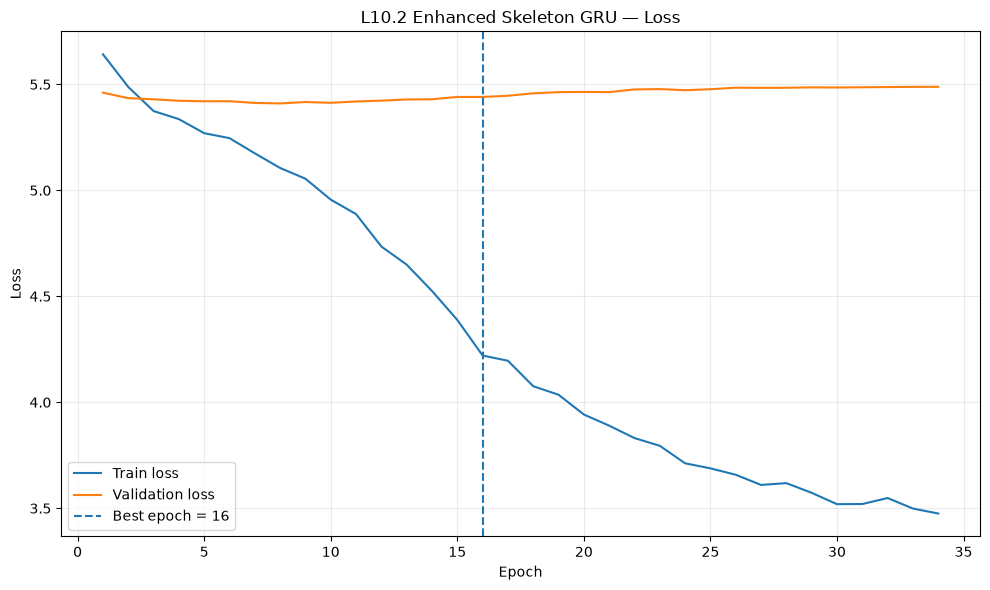

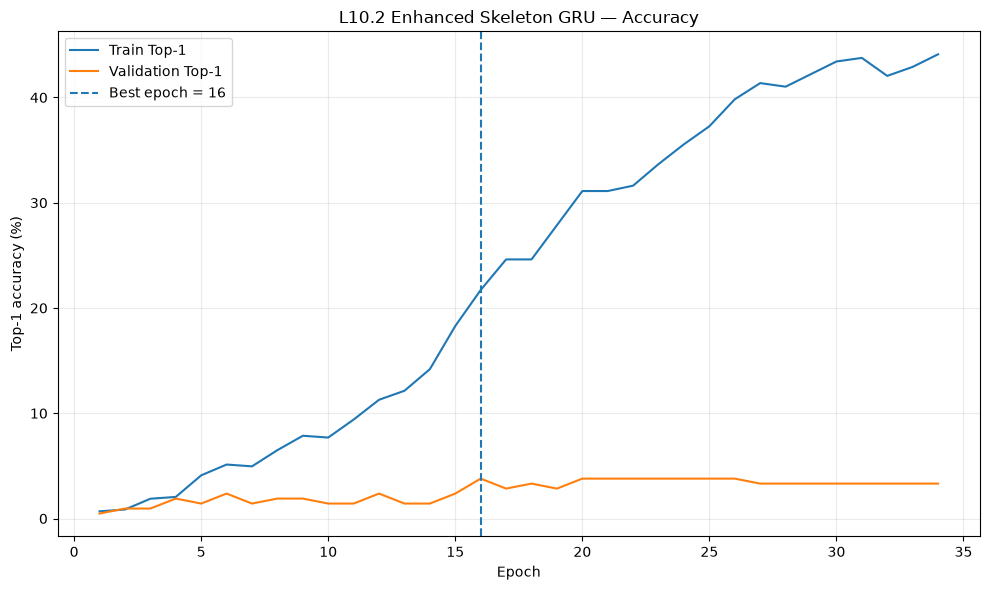


L10.0 vs L10.2

L10.0 Original GRU Top-1 : 7.11%
L10.2 Enhanced GRU Top-1 : 3.79%
Top-1 delta               : -3.32 pp

L10.0 Original GRU Top-5 : 13.74%
L10.2 Enhanced GRU Top-5 : 6.64%
Top-5 delta               : -7.11 pp

GENERALIZATION DIAGNOSTIC

Train Top-1 at selected epoch : 21.71%
Validation Top-1              : 3.79%
Generalization gap            : 17.92 pp

L10.2 FINAL REPORT

REPRESENTATION
----------------------------------------------------------------------------------------------------------------------------------
Sequence                 : 32 frames
Feature dimension        : 617
Includes                 : XYZ + velocity + acceleration + bones + angles + palm + fingertips + two-hand geometry

MODEL
----------------------------------------------------------------------------------------------------------------------------------
Architecture             : Regularized GRU
Hidden units             : 128
Parameters               : 315,557
Dropout                  : 0.45
L

In [3]:
# ==========================================================================================
# CISLR LANDMARK MODEL — L10.2
# ENHANCED SKELETON-MOTION REPRESENTATION + REGULARIZED GRU RETRAINING
# ==========================================================================================
#
# GOAL
# ----
# Improve generalization over the frozen L10.0 GRU baseline by:
#
#   1. Preserving the frozen L9 train/validation/test split.
#   2. Reconstructing the two-hand 21-landmark skeleton from L6 32x254 features.
#   3. Explicitly deriving:
#        - normalized XYZ
#        - velocity
#        - acceleration
#        - bone vectors
#        - bone lengths
#        - finger joint angles
#        - fingertip/palm geometry
#        - palm orientation
#        - two-hand relative geometry
#        - presence masks
#   4. Fitting preprocessing ONLY on training data.
#   5. Training a smaller, more regularized GRU.
#   6. Using validation ONLY for model selection.
#
# IMPORTANT
# ---------
# TEST FEATURES ARE NOT LOADED.
# TEST ACCURACY IS NOT CALCULATED.
#
# L10.0 remains frozen and untouched.
# L11.0 remains frozen and untouched.
#
# ==========================================================================================


# ==========================================================================================
# 0. IMPORTS
# ==========================================================================================

from pathlib import Path

import os
import json
import math
import time
import random
import hashlib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader


warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 300)

np.set_printoptions(
    precision=6,
    suppress=True
)


# ==========================================================================================
# 1. GLOBAL CONFIGURATION
# ==========================================================================================

SEED = 42

SEQUENCE_LENGTH = 32

OLD_FEATURE_DIM = 254

NUM_HANDS = 2

NUM_LANDMARKS = 21

NUM_COORDS = 3

NUM_CLASSES = 211


EXPECTED_TRAIN = 585

EXPECTED_VAL = 211

EXPECTED_TEST = 211


# ==========================================================================================
# 2. TRAINING CONFIGURATION
# ==========================================================================================
#
# L10.0:
#     GRU hidden = 256
#     dropout    = 0.30
#
# L10.2 intentionally reduces capacity and increases regularization.
#
# This is NOT arbitrary accuracy hunting.
# It directly addresses the L10/L11 memorization pattern.
# ==========================================================================================

GRU_HIDDEN_SIZE = 128

GRU_LAYERS = 1

DROPOUT = 0.45

LABEL_SMOOTHING = 0.10


BATCH_SIZE = 32

LEARNING_RATE = 5e-4

WEIGHT_DECAY = 5e-4

MAX_EPOCHS = 120

EARLY_STOPPING_PATIENCE = 18

GRAD_CLIP_NORM = 5.0


LR_FACTOR = 0.5

LR_PATIENCE = 6

MIN_LR = 1e-6


# ------------------------------------------------------------------------------------------
# Training-only augmentation
# ------------------------------------------------------------------------------------------

TEMPORAL_MASK_PROBABILITY = 0.25

MAX_TEMPORAL_MASK_LENGTH = 3

FEATURE_NOISE_STD = 0.015

HAND_DROP_PROBABILITY = 0.10


NUM_WORKERS = 0

PIN_MEMORY = torch.cuda.is_available()


# ==========================================================================================
# 3. REPRODUCIBILITY
# ==========================================================================================

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)

np.random.seed(SEED)

torch.manual_seed(SEED)


if torch.cuda.is_available():

    torch.cuda.manual_seed(SEED)

    torch.cuda.manual_seed_all(SEED)


try:

    torch.use_deterministic_algorithms(True)

except Exception:

    pass


if torch.backends.cudnn.is_available():

    torch.backends.cudnn.deterministic = True

    torch.backends.cudnn.benchmark = False


# ==========================================================================================
# 4. DEVICE
# ==========================================================================================

DEVICE = torch.device(

    "cuda"

    if torch.cuda.is_available()

    else "cpu"
)


print("=" * 130)

print(
    "CISLR LANDMARK MODEL — L10.2"
)

print(
    "ENHANCED SKELETON-MOTION REPRESENTATION + REGULARIZED GRU"
)

print("=" * 130)

print()

print(
    "PyTorch version :",
    torch.__version__
)

print(
    "Device          :",
    DEVICE
)


if torch.cuda.is_available():

    print(
        "GPU             :",
        torch.cuda.get_device_name(0)
    )


# ==========================================================================================
# 5. PATHS
# ==========================================================================================

PROJECT_ROOT = Path(
    "/home/dipshikha/Music/cao/CISLR_RESEARCH"
)


LANDMARK_ROOT = (

    PROJECT_ROOT
    /
    "CISLR_LANDMARK_MODEL"
)


# ------------------------------------------------------------------------------------------
# Frozen L6 features
# ------------------------------------------------------------------------------------------

L6_ROOT = (

    LANDMARK_ROOT
    /
    "audit"
    /
    "l6_full_extraction"
)


FEATURE_DIR = (

    L6_ROOT
    /
    "features_32x254"
)


# ------------------------------------------------------------------------------------------
# Frozen L9 split
# ------------------------------------------------------------------------------------------

L9_ROOT = (

    LANDMARK_ROOT
    /
    "audit"
    /
    "l9_split_freeze"
)


TRAIN_MANIFEST_PATH = (

    L9_ROOT
    /
    "splits"
    /
    "l9_train_manifest.csv"
)


VAL_MANIFEST_PATH = (

    L9_ROOT
    /
    "splits"
    /
    "l9_validation_manifest.csv"
)


TEST_MANIFEST_PATH = (

    L9_ROOT
    /
    "splits"
    /
    "l9_test_manifest.csv"
)


L9_CHECKPOINT_PATH = (

    L9_ROOT
    /
    "reports"
    /
    "l9_checkpoint.json"
)


L9_MAPPING_PATH = (

    L9_ROOT
    /
    "class_mapping"
    /
    "l9_controlled_class_mapping.json"
)


# ------------------------------------------------------------------------------------------
# Frozen L10 baseline
# ------------------------------------------------------------------------------------------

L10_BASELINE_ROOT = (

    LANDMARK_ROOT
    /
    "audit"
    /
    "l10_gru_baseline"
)


L10_SUMMARY_PATH = (

    L10_BASELINE_ROOT
    /
    "reports"
    /
    "l10_summary.json"
)


L10_CHECKPOINT_PATH = (

    L10_BASELINE_ROOT
    /
    "reports"
    /
    "l10_checkpoint.json"
)


# ==========================================================================================
# 6. L10.2 OUTPUT
# ==========================================================================================

L102_ROOT = (

    LANDMARK_ROOT
    /
    "audit"
    /
    "l10_2_enhanced_skeleton_gru"
)


FEATURE_OUTPUT_DIR = (

    L102_ROOT
    /
    "enhanced_features"
)


PREPROCESS_DIR = (

    L102_ROOT
    /
    "preprocessing"
)


MODEL_DIR = (

    L102_ROOT
    /
    "models"
)


REPORT_DIR = (

    L102_ROOT
    /
    "reports"
)


PLOT_DIR = (

    L102_ROOT
    /
    "plots"
)


for directory in [

    L102_ROOT,

    FEATURE_OUTPUT_DIR,

    PREPROCESS_DIR,

    MODEL_DIR,

    REPORT_DIR,

    PLOT_DIR

]:

    directory.mkdir(
        parents=True,
        exist_ok=True
    )


MEAN_PATH = (

    PREPROCESS_DIR
    /
    "l10_2_train_mean.npy"
)


STD_PATH = (

    PREPROCESS_DIR
    /
    "l10_2_train_std.npy"
)


BEST_MODEL_PATH = (

    MODEL_DIR
    /
    "l10_2_best_gru.pt"
)


LAST_MODEL_PATH = (

    MODEL_DIR
    /
    "l10_2_last_gru.pt"
)


HISTORY_PATH = (

    REPORT_DIR
    /
    "l10_2_training_history.csv"
)


VAL_PREDICTIONS_PATH = (

    REPORT_DIR
    /
    "l10_2_validation_predictions.csv"
)


FEATURE_AUDIT_PATH = (

    REPORT_DIR
    /
    "l10_2_feature_audit.json"
)


SUMMARY_PATH = (

    REPORT_DIR
    /
    "l10_2_summary.json"
)


CHECKPOINT_PATH = (

    REPORT_DIR
    /
    "l10_2_checkpoint.json"
)


LOSS_PLOT_PATH = (

    PLOT_DIR
    /
    "l10_2_loss_curve.png"
)


ACCURACY_PLOT_PATH = (

    PLOT_DIR
    /
    "l10_2_accuracy_curve.png"
)


# ==========================================================================================
# 7. VERIFY INPUTS
# ==========================================================================================

required_paths = [

    FEATURE_DIR,

    TRAIN_MANIFEST_PATH,

    VAL_MANIFEST_PATH,

    TEST_MANIFEST_PATH,

    L9_CHECKPOINT_PATH,

    L9_MAPPING_PATH,

    L10_SUMMARY_PATH,

    L10_CHECKPOINT_PATH
]


for path in required_paths:

    if not path.exists():

        raise FileNotFoundError(
            f"Missing required input:\n{path}"
        )


print()

print(
    "[PASS] Required L6/L9/L10 files exist."
)


# ==========================================================================================
# 8. VERIFY L9
# ==========================================================================================

with open(
    L9_CHECKPOINT_PATH,
    "r"
) as f:

    l9_checkpoint = json.load(f)


if not bool(
    l9_checkpoint.get(
        "l9_pass",
        False
    )
):

    raise RuntimeError(
        "L9 checkpoint is not PASS."
    )


# ==========================================================================================
# 9. VERIFY L10 BASELINE
# ==========================================================================================

with open(
    L10_CHECKPOINT_PATH,
    "r"
) as f:

    l10_checkpoint = json.load(f)


if not bool(
    l10_checkpoint.get(
        "l10_pass",
        False
    )
):

    raise RuntimeError(
        "L10 baseline checkpoint is not PASS."
    )


with open(
    L10_SUMMARY_PATH,
    "r"
) as f:

    l10_summary = json.load(f)


BASELINE_TOP1 = float(

    l10_summary[
        "validation"
    ][
        "top1"
    ]
)


BASELINE_TOP5 = float(

    l10_summary[
        "validation"
    ][
        "top5"
    ]
)


print(
    "[PASS] L9 split verified."
)

print(
    "[PASS] L10 baseline verified."
)

print()

print(
    f"L10.0 baseline Top-1 : "
    f"{100 * BASELINE_TOP1:.2f}%"
)

print(
    f"L10.0 baseline Top-5 : "
    f"{100 * BASELINE_TOP5:.2f}%"
)


# ==========================================================================================
# 10. LOAD SPLITS
# ==========================================================================================

train_manifest = pd.read_csv(
    TRAIN_MANIFEST_PATH
)


val_manifest = pd.read_csv(
    VAL_MANIFEST_PATH
)


# ------------------------------------------------------------------------------------------
# Test manifest ONLY.
#
# No test feature files are loaded.
# ------------------------------------------------------------------------------------------

test_manifest = pd.read_csv(
    TEST_MANIFEST_PATH
)


if len(train_manifest) != EXPECTED_TRAIN:

    raise RuntimeError(
        "Unexpected training population."
    )


if len(val_manifest) != EXPECTED_VAL:

    raise RuntimeError(
        "Unexpected validation population."
    )


if len(test_manifest) != EXPECTED_TEST:

    raise RuntimeError(
        "Unexpected test population."
    )


print()

print("=" * 130)

print(
    "FROZEN L9 POPULATION"
)

print("=" * 130)

print(
    "Train      :",
    len(train_manifest)
)

print(
    "Validation :",
    len(val_manifest)
)

print(
    "Test       :",
    len(test_manifest),
    "(LOCKED)"
)


# ==========================================================================================
# 11. VERIFY UID LEAKAGE
# ==========================================================================================

train_uids = set(
    train_manifest[
        "uid_clean"
    ].astype(str)
)


val_uids = set(
    val_manifest[
        "uid_clean"
    ].astype(str)
)


test_uids = set(
    test_manifest[
        "uid_clean"
    ].astype(str)
)


assert not (
    train_uids
    &
    val_uids
)


assert not (
    train_uids
    &
    test_uids
)


assert not (
    val_uids
    &
    test_uids
)


print(
    "[PASS] Zero UID overlap."
)


# ==========================================================================================
# 12. CLASS MAPPING
# ==========================================================================================

with open(
    L9_MAPPING_PATH,
    "r"
) as f:

    mapping = json.load(f)


id_to_gloss = {

    int(k):
    str(v)

    for k, v
    in mapping[
        "id_to_gloss"
    ].items()

}


if len(id_to_gloss) != NUM_CLASSES:

    raise RuntimeError(
        "Expected 211 classes."
    )


# ==========================================================================================
# 13. HAND SKELETON TOPOLOGY
# ==========================================================================================
#
# MediaPipe 21-landmark hand:
#
# 0  wrist
#
# Thumb:
# 0-1-2-3-4
#
# Index:
# 0-5-6-7-8
#
# Middle:
# 0-9-10-11-12
#
# Ring:
# 0-13-14-15-16
#
# Pinky:
# 0-17-18-19-20
#
# ==========================================================================================

HAND_EDGES = [

    (0, 1),
    (1, 2),
    (2, 3),
    (3, 4),

    (0, 5),
    (5, 6),
    (6, 7),
    (7, 8),

    (0, 9),
    (9, 10),
    (10, 11),
    (11, 12),

    (0, 13),
    (13, 14),
    (14, 15),
    (15, 16),

    (0, 17),
    (17, 18),
    (18, 19),
    (19, 20)
]


# ------------------------------------------------------------------------------------------
# Three-joint angle definitions
# ------------------------------------------------------------------------------------------

ANGLE_TRIPLETS = [

    # Thumb
    (1, 2, 3),
    (2, 3, 4),

    # Index
    (5, 6, 7),
    (6, 7, 8),

    # Middle
    (9, 10, 11),
    (10, 11, 12),

    # Ring
    (13, 14, 15),
    (14, 15, 16),

    # Pinky
    (17, 18, 19),
    (18, 19, 20)
]


FINGERTIPS = [
    4,
    8,
    12,
    16,
    20
]


MCP_POINTS = [
    5,
    9,
    13,
    17
]


# ==========================================================================================
# 14. LOAD OLD 32x254 FEATURE
# ==========================================================================================

def load_old_feature(
    uid
):

    path = (
        FEATURE_DIR
        /
        f"{uid}.npz"
    )


    if not path.exists():

        raise FileNotFoundError(
            path
        )


    with np.load(
        path,
        allow_pickle=True
    ) as data:

        X = np.asarray(
            data[
                "features"
            ],
            dtype=np.float32
        )


    if X.shape != (
        32,
        254
    ):

        raise RuntimeError(
            f"{uid}: invalid shape {X.shape}"
        )


    if not np.isfinite(
        X
    ).all():

        raise RuntimeError(
            f"{uid}: non-finite feature."
        )


    return X


# ==========================================================================================
# 15. RECONSTRUCT SKELETON
# ==========================================================================================
#
# Original first 126 dimensions:
#
# 2 hands × 21 landmarks × XYZ
#
# reshape:
#
# [T, 2, 21, 3]
#
# ==========================================================================================

def reconstruct_skeleton(
    old_features
):

    xyz = old_features[
        :,
        :126
    ].reshape(

        SEQUENCE_LENGTH,
        NUM_HANDS,
        NUM_LANDMARKS,
        NUM_COORDS
    )


    masks = old_features[
        :,
        252:254
    ]


    # Guarantee missing hands remain exactly zero.

    xyz = (

        xyz
        *
        masks[
            :,
            :,
            None,
            None
        ]
    )


    return (

        xyz.astype(
            np.float32
        ),

        masks.astype(
            np.float32
        )
    )


# ==========================================================================================
# 16. SAFE VECTOR NORMALIZATION
# ==========================================================================================

EPS = 1e-6


def safe_unit_vector(
    vector
):

    norm = np.linalg.norm(
        vector,
        axis=-1,
        keepdims=True
    )


    return np.divide(

        vector,

        np.maximum(
            norm,
            EPS
        ),

        out=np.zeros_like(
            vector
        ),

        where=(
            norm
            >
            EPS
        )
    )


# ==========================================================================================
# 17. SAFE ANGLE
# ==========================================================================================

def vector_angle(
    a,
    b
):

    a_norm = np.linalg.norm(
        a
    )

    b_norm = np.linalg.norm(
        b
    )


    if (
        a_norm < EPS
        or
        b_norm < EPS
    ):

        return 0.0


    cosine = np.dot(
        a,
        b
    ) / (
        a_norm
        *
        b_norm
    )


    cosine = np.clip(
        cosine,
        -1.0,
        1.0
    )


    # Normalize angle to [0, 1].

    return float(
        np.arccos(
            cosine
        )
        /
        np.pi
    )


# ==========================================================================================
# 18. TEMPORAL VELOCITY
# ==========================================================================================

def temporal_velocity(
    xyz,
    masks
):

    velocity = np.zeros_like(
        xyz,
        dtype=np.float32
    )


    for t in range(
        1,
        SEQUENCE_LENGTH
    ):

        valid = (

            masks[
                t
            ]
            *
            masks[
                t - 1
            ]
        )


        velocity[
            t
        ] = (

            xyz[
                t
            ]
            -
            xyz[
                t - 1
            ]

        ) * (

            valid[
                :,
                None,
                None
            ]
        )


    return velocity


# ==========================================================================================
# 19. TEMPORAL ACCELERATION
# ==========================================================================================

def temporal_acceleration(
    velocity,
    masks
):

    acceleration = np.zeros_like(
        velocity,
        dtype=np.float32
    )


    for t in range(
        2,
        SEQUENCE_LENGTH
    ):

        valid = (

            masks[
                t
            ]
            *
            masks[
                t - 1
            ]
            *
            masks[
                t - 2
            ]
        )


        acceleration[
            t
        ] = (

            velocity[
                t
            ]
            -
            velocity[
                t - 1
            ]

        ) * (

            valid[
                :,
                None,
                None
            ]
        )


    return acceleration


# ==========================================================================================
# 20. BONE FEATURES
# ==========================================================================================

def bone_features(
    xyz,
    masks
):

    T = xyz.shape[0]


    bone_vectors = np.zeros(

        (
            T,
            NUM_HANDS,
            len(HAND_EDGES),
            3
        ),

        dtype=np.float32
    )


    bone_lengths = np.zeros(

        (
            T,
            NUM_HANDS,
            len(HAND_EDGES)
        ),

        dtype=np.float32
    )


    for t in range(T):

        for h in range(
            NUM_HANDS
        ):

            if masks[
                t,
                h
            ] < 0.5:

                continue


            for edge_index, (
                parent,
                child
            ) in enumerate(
                HAND_EDGES
            ):

                vector = (

                    xyz[
                        t,
                        h,
                        child
                    ]
                    -
                    xyz[
                        t,
                        h,
                        parent
                    ]
                )


                bone_vectors[
                    t,
                    h,
                    edge_index
                ] = vector


                bone_lengths[
                    t,
                    h,
                    edge_index
                ] = np.linalg.norm(
                    vector
                )


    return (
        bone_vectors,
        bone_lengths
    )


# ==========================================================================================
# 21. JOINT ANGLES
# ==========================================================================================

def joint_angle_features(
    xyz,
    masks
):

    angles = np.zeros(

        (
            SEQUENCE_LENGTH,
            NUM_HANDS,
            len(ANGLE_TRIPLETS)
        ),

        dtype=np.float32
    )


    for t in range(
        SEQUENCE_LENGTH
    ):

        for h in range(
            NUM_HANDS
        ):

            if masks[
                t,
                h
            ] < 0.5:

                continue


            hand = xyz[
                t,
                h
            ]


            for i, (
                a,
                b,
                c
            ) in enumerate(
                ANGLE_TRIPLETS
            ):

                vector_1 = (
                    hand[a]
                    -
                    hand[b]
                )


                vector_2 = (
                    hand[c]
                    -
                    hand[b]
                )


                angles[
                    t,
                    h,
                    i
                ] = vector_angle(
                    vector_1,
                    vector_2
                )


    return angles


# ==========================================================================================
# 22. PALM GEOMETRY
# ==========================================================================================
#
# Per hand:
#
#   palm normal XYZ
#   palm forward XYZ
#   palm width
#   palm length
#
# 8 features / hand.
#
# ==========================================================================================

def palm_geometry_features(
    xyz,
    masks
):

    features = np.zeros(

        (
            SEQUENCE_LENGTH,
            NUM_HANDS,
            8
        ),

        dtype=np.float32
    )


    for t in range(
        SEQUENCE_LENGTH
    ):

        for h in range(
            NUM_HANDS
        ):

            if masks[
                t,
                h
            ] < 0.5:

                continue


            hand = xyz[
                t,
                h
            ]


            wrist = hand[0]

            index_mcp = hand[5]

            middle_mcp = hand[9]

            pinky_mcp = hand[17]


            across = (
                index_mcp
                -
                pinky_mcp
            )


            forward = (
                middle_mcp
                -
                wrist
            )


            normal = np.cross(
                across,
                forward
            )


            normal = safe_unit_vector(
                normal
            )


            forward_unit = safe_unit_vector(
                forward
            )


            palm_width = np.linalg.norm(
                across
            )


            palm_length = np.linalg.norm(
                forward
            )


            features[
                t,
                h
            ] = np.concatenate(

                [

                    normal,

                    forward_unit,

                    np.array(
                        [
                            palm_width,
                            palm_length
                        ],
                        dtype=np.float32
                    )
                ]
            )


    return features


# ==========================================================================================
# 23. FINGERTIP GEOMETRY
# ==========================================================================================
#
# Per hand:
#
#   5 fingertip-to-wrist distances
#
#   4 adjacent fingertip distances:
#       thumb-index
#       index-middle
#       middle-ring
#       ring-pinky
#
#   5 fingertip speeds
#
# = 14 features / hand
#
# ==========================================================================================

def fingertip_features(
    xyz,
    velocity,
    masks
):

    output = np.zeros(

        (
            SEQUENCE_LENGTH,
            NUM_HANDS,
            14
        ),

        dtype=np.float32
    )


    for t in range(
        SEQUENCE_LENGTH
    ):

        for h in range(
            NUM_HANDS
        ):

            if masks[
                t,
                h
            ] < 0.5:

                continue


            hand = xyz[
                t,
                h
            ]


            wrist = hand[0]


            tips = hand[
                FINGERTIPS
            ]


            wrist_distances = np.linalg.norm(

                tips
                -
                wrist[
                    None,
                    :
                ],

                axis=1
            )


            adjacent_distances = []


            for i in range(4):

                adjacent_distances.append(

                    np.linalg.norm(

                        tips[
                            i + 1
                        ]
                        -
                        tips[
                            i
                        ]
                    )
                )


            tip_speeds = np.linalg.norm(

                velocity[
                    t,
                    h,
                    FINGERTIPS
                ],

                axis=1
            )


            output[
                t,
                h
            ] = np.concatenate(

                [

                    wrist_distances,

                    np.asarray(
                        adjacent_distances,
                        dtype=np.float32
                    ),

                    tip_speeds
                ]
            )


    return output


# ==========================================================================================
# 24. TWO-HAND RELATIVE GEOMETRY
# ==========================================================================================
#
# Features:
#
# relative wrist XYZ                  3
# wrist distance                      1
# relative wrist velocity XYZ         3
# relative wrist speed                1
# relative middle-MCP XYZ             3
# middle-MCP distance                 1
# both-hand mask                      1
#
# Total = 13
#
# ==========================================================================================

def two_hand_features(
    xyz,
    velocity,
    masks
):

    output = np.zeros(

        (
            SEQUENCE_LENGTH,
            13
        ),

        dtype=np.float32
    )


    for t in range(
        SEQUENCE_LENGTH
    ):

        both_present = (

            masks[
                t,
                0
            ] >= 0.5

            and

            masks[
                t,
                1
            ] >= 0.5
        )


        if not both_present:

            continue


        wrist_relative = (

            xyz[
                t,
                1,
                0
            ]
            -
            xyz[
                t,
                0,
                0
            ]
        )


        wrist_distance = np.linalg.norm(
            wrist_relative
        )


        velocity_relative = (

            velocity[
                t,
                1,
                0
            ]
            -
            velocity[
                t,
                0,
                0
            ]
        )


        relative_speed = np.linalg.norm(
            velocity_relative
        )


        middle_relative = (

            xyz[
                t,
                1,
                9
            ]
            -
            xyz[
                t,
                0,
                9
            ]
        )


        middle_distance = np.linalg.norm(
            middle_relative
        )


        output[
            t
        ] = np.concatenate(

            [

                wrist_relative,

                np.array(
                    [
                        wrist_distance
                    ],
                    dtype=np.float32
                ),

                velocity_relative,

                np.array(
                    [
                        relative_speed
                    ],
                    dtype=np.float32
                ),

                middle_relative,

                np.array(
                    [
                        middle_distance,
                        1.0
                    ],
                    dtype=np.float32
                )
            ]
        )


    return output


# ==========================================================================================
# 25. BUILD ENHANCED REPRESENTATION
# ==========================================================================================

def build_enhanced_features(
    old_features
):

    xyz, masks = reconstruct_skeleton(
        old_features
    )


    velocity = temporal_velocity(
        xyz,
        masks
    )


    acceleration = temporal_acceleration(
        velocity,
        masks
    )


    bone_vectors, bone_lengths = bone_features(
        xyz,
        masks
    )


    angles = joint_angle_features(
        xyz,
        masks
    )


    palm = palm_geometry_features(
        xyz,
        masks
    )


    fingertips = fingertip_features(
        xyz,
        velocity,
        masks
    )


    two_hand = two_hand_features(
        xyz,
        velocity,
        masks
    )


    # --------------------------------------------------------------------------------------
    # Flatten hand-specific features per frame.
    # --------------------------------------------------------------------------------------

    xyz_flat = xyz.reshape(
        SEQUENCE_LENGTH,
        -1
    )


    velocity_flat = velocity.reshape(
        SEQUENCE_LENGTH,
        -1
    )


    acceleration_flat = acceleration.reshape(
        SEQUENCE_LENGTH,
        -1
    )


    bone_vector_flat = bone_vectors.reshape(
        SEQUENCE_LENGTH,
        -1
    )


    bone_length_flat = bone_lengths.reshape(
        SEQUENCE_LENGTH,
        -1
    )


    angle_flat = angles.reshape(
        SEQUENCE_LENGTH,
        -1
    )


    palm_flat = palm.reshape(
        SEQUENCE_LENGTH,
        -1
    )


    fingertip_flat = fingertips.reshape(
        SEQUENCE_LENGTH,
        -1
    )


    enhanced = np.concatenate(

        [

            xyz_flat,

            velocity_flat,

            acceleration_flat,

            bone_vector_flat,

            bone_length_flat,

            angle_flat,

            palm_flat,

            fingertip_flat,

            two_hand,

            masks

        ],

        axis=1
    ).astype(
        np.float32
    )


    if not np.isfinite(
        enhanced
    ).all():

        raise RuntimeError(
            "Enhanced representation contains NaN/Inf."
        )


    return enhanced


# ==========================================================================================
# 26. DETERMINE FEATURE DIMENSION
# ==========================================================================================

sample_uid = str(
    train_manifest.iloc[
        0
    ][
        "uid_clean"
    ]
)


sample_old = load_old_feature(
    sample_uid
)


sample_enhanced = build_enhanced_features(
    sample_old
)


ENHANCED_FEATURE_DIM = int(
    sample_enhanced.shape[1]
)


print()

print("=" * 130)

print(
    "ENHANCED SKELETON REPRESENTATION"
)

print("=" * 130)

print(
    "Sequence length      :",
    SEQUENCE_LENGTH
)

print(
    "Old feature dim      :",
    OLD_FEATURE_DIM
)

print(
    "Enhanced feature dim :",
    ENHANCED_FEATURE_DIM
)

print(
    "Sample shape         :",
    sample_enhanced.shape
)


# ==========================================================================================
# 27. LOAD TRAIN + VALIDATION ENHANCED FEATURES
# ==========================================================================================
#
# IMPORTANT:
#
# TEST FEATURES ARE NOT GENERATED OR LOADED HERE.
#
# ==========================================================================================

def build_population_features(
    manifest,
    split_name
):

    X = np.zeros(

        (
            len(manifest),
            SEQUENCE_LENGTH,
            ENHANCED_FEATURE_DIM
        ),

        dtype=np.float32
    )


    y = manifest[
        "class_id"
    ].to_numpy(
        dtype=np.int64
    )


    print()

    print(
        f"Building {split_name} enhanced features..."
    )


    start = time.perf_counter()


    for i, row in enumerate(
        manifest.itertuples(
            index=False
        )
    ):

        uid = str(
            row.uid_clean
        )


        old = load_old_feature(
            uid
        )


        enhanced = build_enhanced_features(
            old
        )


        X[
            i
        ] = enhanced


        if (
            (i + 1) % 100 == 0
            or
            (i + 1) == len(manifest)
        ):

            print(
                f"  {i + 1}/{len(manifest)}"
            )


    elapsed = (
        time.perf_counter()
        -
        start
    )


    print(
        f"[DONE] {split_name}: "
        f"{elapsed:.2f} sec"
    )


    return X, y


X_train_raw, y_train = build_population_features(

    train_manifest,

    "TRAIN"
)


X_val_raw, y_val = build_population_features(

    val_manifest,

    "VALIDATION"
)


print()

print(
    "Train shape:",
    X_train_raw.shape
)

print(
    "Val shape  :",
    X_val_raw.shape
)


# ==========================================================================================
# 28. STRUCTURAL AUDIT
# ==========================================================================================

if X_train_raw.shape != (

    EXPECTED_TRAIN,
    SEQUENCE_LENGTH,
    ENHANCED_FEATURE_DIM
):

    raise RuntimeError(
        "Invalid training shape."
    )


if X_val_raw.shape != (

    EXPECTED_VAL,
    SEQUENCE_LENGTH,
    ENHANCED_FEATURE_DIM
):

    raise RuntimeError(
        "Invalid validation shape."
    )


if not np.isfinite(
    X_train_raw
).all():

    raise RuntimeError(
        "Train enhanced features contain NaN/Inf."
    )


if not np.isfinite(
    X_val_raw
).all():

    raise RuntimeError(
        "Validation enhanced features contain NaN/Inf."
    )


print()

print(
    "[PASS] Enhanced representation structural audit."
)


# ==========================================================================================
# 29. FEATURE GROUP BOUNDARIES
# ==========================================================================================
#
# Used for augmentation.
#
# ==========================================================================================

D_XYZ = 126

D_VEL = 126

D_ACC = 126

D_BONE_VEC = (
    2
    *
    len(HAND_EDGES)
    *
    3
)

D_BONE_LEN = (
    2
    *
    len(HAND_EDGES)
)

D_ANGLES = (
    2
    *
    len(ANGLE_TRIPLETS)
)

D_PALM = 16

D_FINGERTIPS = 28

D_TWO_HAND = 13

D_MASKS = 2


EXPECTED_ENHANCED_DIM = (

    D_XYZ
    +
    D_VEL
    +
    D_ACC
    +
    D_BONE_VEC
    +
    D_BONE_LEN
    +
    D_ANGLES
    +
    D_PALM
    +
    D_FINGERTIPS
    +
    D_TWO_HAND
    +
    D_MASKS
)


if (
    EXPECTED_ENHANCED_DIM
    !=
    ENHANCED_FEATURE_DIM
):

    raise RuntimeError(
        "Feature dimension bookkeeping mismatch."
    )


MASK_START = (
    ENHANCED_FEATURE_DIM
    -
    2
)


CONTINUOUS_DIM = MASK_START


print()

print(
    "Continuous dimensions:",
    CONTINUOUS_DIM
)

print(
    "Mask dimensions      :",
    [
        MASK_START,
        MASK_START + 1
    ]
)


# ==========================================================================================
# 30. TRAIN-ONLY STANDARDIZATION
# ==========================================================================================
#
# Fit statistics ONLY on training data.
#
# Missing/padded zeros are included, matching the original baseline philosophy.
#
# ==========================================================================================

flat_train = X_train_raw[
    :,
    :,
    :CONTINUOUS_DIM
].reshape(
    -1,
    CONTINUOUS_DIM
)


train_mean = flat_train.mean(
    axis=0
).astype(
    np.float32
)


train_std = flat_train.std(
    axis=0
).astype(
    np.float32
)


near_zero_std = (

    train_std
    <
    1e-6
)


near_zero_count = int(
    near_zero_std.sum()
)


train_std[
    near_zero_std
] = 1.0


np.save(
    MEAN_PATH,
    train_mean
)


np.save(
    STD_PATH,
    train_std
)


print()

print("=" * 130)

print(
    "TRAIN-ONLY PREPROCESSING"
)

print("=" * 130)

print(
    "Mean shape           :",
    train_mean.shape
)

print(
    "Std shape            :",
    train_std.shape
)

print(
    "Near-zero std dims   :",
    near_zero_count
)


# ==========================================================================================
# 31. APPLY STANDARDIZATION
# ==========================================================================================

def standardize(
    X
):

    Y = X.copy().astype(
        np.float32
    )


    Y[
        :,
        :,
        :CONTINUOUS_DIM
    ] = (

        Y[
            :,
            :,
            :CONTINUOUS_DIM
        ]

        -

        train_mean[
            None,
            None,
            :
        ]

    ) / (

        train_std[
            None,
            None,
            :
        ]

    )


    return Y


X_train = standardize(
    X_train_raw
)


X_val = standardize(
    X_val_raw
)


if not np.isfinite(
    X_train
).all():

    raise RuntimeError(
        "Standardized training features invalid."
    )


if not np.isfinite(
    X_val
).all():

    raise RuntimeError(
        "Standardized validation features invalid."
    )


# ==========================================================================================
# 32. MASK INTEGRITY
# ==========================================================================================

assert np.array_equal(

    X_train[
        :,
        :,
        MASK_START:
    ],

    X_train_raw[
        :,
        :,
        MASK_START:
    ]
)


assert np.array_equal(

    X_val[
        :,
        :,
        MASK_START:
    ],

    X_val_raw[
        :,
        :,
        MASK_START:
    ]
)


print(
    "[PASS] Presence masks preserved."
)


# ==========================================================================================
# 33. FEATURE AUDIT
# ==========================================================================================

feature_audit = {

    "sequence_length":
        SEQUENCE_LENGTH,

    "old_feature_dim":
        OLD_FEATURE_DIM,

    "enhanced_feature_dim":
        ENHANCED_FEATURE_DIM,

    "continuous_dim":
        CONTINUOUS_DIM,

    "mask_dim":
        2,

    "train_shape":
        list(
            X_train.shape
        ),

    "validation_shape":
        list(
            X_val.shape
        ),

    "train_raw_abs_max":
        float(
            np.max(
                np.abs(
                    X_train_raw
                )
            )
        ),

    "validation_raw_abs_max":
        float(
            np.max(
                np.abs(
                    X_val_raw
                )
            )
        ),

    "train_standardized_abs_max":
        float(
            np.max(
                np.abs(
                    X_train
                )
            )
        ),

    "validation_standardized_abs_max":
        float(
            np.max(
                np.abs(
                    X_val
                )
            )
        ),

    "near_zero_std_dimensions":
        near_zero_count,

    "finite_train":
        bool(
            np.isfinite(
                X_train
            ).all()
        ),

    "finite_validation":
        bool(
            np.isfinite(
                X_val
            ).all()
        ),

    "test_features_loaded":
        False
}


with open(
    FEATURE_AUDIT_PATH,
    "w"
) as f:

    json.dump(
        feature_audit,
        f,
        indent=4
    )


# ==========================================================================================
# 34. TRAINING DATASET WITH REGULARIZATION AUGMENTATION
# ==========================================================================================

class EnhancedSkeletonDataset(
    Dataset
):

    def __init__(
        self,
        X,
        y,
        training=False
    ):

        self.X = X

        self.y = y

        self.training = training


    def __len__(
        self
    ):

        return len(
            self.y
        )


    def __getitem__(
        self,
        index
    ):

        x = self.X[
            index
        ].copy()


        y = int(
            self.y[
                index
            ]
        )


        if self.training:

            # ------------------------------------------------------------------
            # 1. Small Gaussian noise on continuous dimensions only.
            # ------------------------------------------------------------------

            if FEATURE_NOISE_STD > 0:

                noise = np.random.normal(

                    0.0,

                    FEATURE_NOISE_STD,

                    size=(
                        SEQUENCE_LENGTH,
                        CONTINUOUS_DIM
                    )

                ).astype(
                    np.float32
                )


                x[
                    :,
                    :CONTINUOUS_DIM
                ] += noise


            # ------------------------------------------------------------------
            # 2. Temporal masking.
            #
            # Simulates short tracking failures and discourages memorization
            # of exact frame trajectories.
            # ------------------------------------------------------------------

            if (
                np.random.rand()
                <
                TEMPORAL_MASK_PROBABILITY
            ):

                length = np.random.randint(

                    1,

                    MAX_TEMPORAL_MASK_LENGTH + 1
                )


                start = np.random.randint(

                    0,

                    SEQUENCE_LENGTH
                    -
                    length
                    +
                    1
                )


                x[
                    start:
                    start + length,
                    :
                ] = 0.0


            # ------------------------------------------------------------------
            # 3. Hand-presence perturbation.
            #
            # Conservative probability.
            #
            # This is not intended to synthetically create a new sign.
            # It makes the classifier less dependent on one exact track.
            # ------------------------------------------------------------------

            if (
                np.random.rand()
                <
                HAND_DROP_PROBABILITY
            ):

                hand_to_drop = np.random.randint(
                    0,
                    2
                )


                # Only change mask signal here.
                #
                # We do NOT attempt to zero every derived feature because many
                # groups combine both hands. The explicit mask teaches the model
                # that the selected hand should be treated cautiously.

                x[
                    :,
                    MASK_START
                    +
                    hand_to_drop
                ] = 0.0


        return (

            torch.from_numpy(
                x
            ).float(),

            torch.tensor(
                y,
                dtype=torch.long
            )
        )


train_dataset = EnhancedSkeletonDataset(

    X_train,

    y_train,

    training=True
)


val_dataset = EnhancedSkeletonDataset(

    X_val,

    y_val,

    training=False
)


# ==========================================================================================
# 35. DATALOADERS
# ==========================================================================================

generator = torch.Generator()

generator.manual_seed(
    SEED
)


train_loader = DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=True,

    num_workers=NUM_WORKERS,

    pin_memory=PIN_MEMORY,

    generator=generator
)


val_loader = DataLoader(

    val_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=NUM_WORKERS,

    pin_memory=PIN_MEMORY
)


# ==========================================================================================
# 36. REGULARIZED GRU
# ==========================================================================================

class EnhancedGRUClassifier(
    nn.Module
):

    def __init__(
        self,
        input_dim,
        hidden_dim,
        num_classes,
        dropout
    ):

        super().__init__()


        # ----------------------------------------------------------------------
        # Feature normalization inside model.
        # ----------------------------------------------------------------------

        self.input_norm = nn.LayerNorm(
            input_dim
        )


        self.input_dropout = nn.Dropout(
            dropout * 0.5
        )


        self.gru = nn.GRU(

            input_size=input_dim,

            hidden_size=hidden_dim,

            num_layers=1,

            batch_first=True
        )


        self.hidden_norm = nn.LayerNorm(
            hidden_dim
        )


        self.dropout = nn.Dropout(
            dropout
        )


        self.classifier = nn.Linear(
            hidden_dim,
            num_classes
        )


    def forward(
        self,
        x
    ):

        x = self.input_norm(
            x
        )


        x = self.input_dropout(
            x
        )


        output, hidden = self.gru(
            x
        )


        h = hidden[
            -1
        ]


        h = self.hidden_norm(
            h
        )


        h = self.dropout(
            h
        )


        logits = self.classifier(
            h
        )


        return logits


model = EnhancedGRUClassifier(

    input_dim=
        ENHANCED_FEATURE_DIM,

    hidden_dim=
        GRU_HIDDEN_SIZE,

    num_classes=
        NUM_CLASSES,

    dropout=
        DROPOUT

).to(
    DEVICE
)


# ==========================================================================================
# 37. MODEL SIZE
# ==========================================================================================

total_parameters = sum(

    p.numel()

    for p
    in model.parameters()
)


trainable_parameters = sum(

    p.numel()

    for p
    in model.parameters()

    if p.requires_grad
)


print()

print("=" * 130)

print(
    "L10.2 REGULARIZED GRU"
)

print("=" * 130)

print(model)

print()

print(
    "Input dimension :",
    ENHANCED_FEATURE_DIM
)

print(
    "GRU hidden      :",
    GRU_HIDDEN_SIZE
)

print(
    "Dropout         :",
    DROPOUT
)

print(
    "Label smoothing :",
    LABEL_SMOOTHING
)

print(
    "Parameters      :",
    f"{total_parameters:,}"
)


# ==========================================================================================
# 38. LOSS
# ==========================================================================================

criterion = nn.CrossEntropyLoss(

    label_smoothing=
        LABEL_SMOOTHING
)


# ==========================================================================================
# 39. OPTIMIZER
# ==========================================================================================

optimizer = torch.optim.AdamW(

    model.parameters(),

    lr=
        LEARNING_RATE,

    weight_decay=
        WEIGHT_DECAY
)


scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(

    optimizer,

    mode="min",

    factor=
        LR_FACTOR,

    patience=
        LR_PATIENCE,

    min_lr=
        MIN_LR
)


# ==========================================================================================
# 40. TOP-K
# ==========================================================================================

def topk_counts(
    logits,
    targets
):

    _, predictions = torch.topk(

        logits,

        k=5,

        dim=1
    )


    top1 = (

        predictions[
            :,
            0
        ]
        ==
        targets

    ).sum().item()


    top5 = (

        predictions
        ==
        targets[
            :,
            None
        ]

    ).any(
        dim=1
    ).sum().item()


    return (
        int(top1),
        int(top5)
    )


# ==========================================================================================
# 41. TRAIN ONE EPOCH
# ==========================================================================================

def train_epoch():

    model.train()


    total_loss = 0.0

    total = 0

    correct1 = 0

    correct5 = 0


    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(
            DEVICE,
            non_blocking=True
        )


        y_batch = y_batch.to(
            DEVICE,
            non_blocking=True
        )


        optimizer.zero_grad(
            set_to_none=True
        )


        logits = model(
            X_batch
        )


        loss = criterion(
            logits,
            y_batch
        )


        loss.backward()


        torch.nn.utils.clip_grad_norm_(

            model.parameters(),

            GRAD_CLIP_NORM
        )


        optimizer.step()


        batch_size = y_batch.size(
            0
        )


        c1, c5 = topk_counts(
            logits,
            y_batch
        )


        total_loss += (
            loss.item()
            *
            batch_size
        )


        total += batch_size

        correct1 += c1

        correct5 += c5


    return (

        total_loss
        /
        total,

        correct1
        /
        total,

        correct5
        /
        total
    )


# ==========================================================================================
# 42. VALIDATION
# ==========================================================================================

@torch.no_grad()
def evaluate():

    model.eval()


    total_loss = 0.0

    total = 0

    correct1 = 0

    correct5 = 0


    logits_all = []

    targets_all = []


    for X_batch, y_batch in val_loader:

        X_batch = X_batch.to(
            DEVICE,
            non_blocking=True
        )


        y_batch = y_batch.to(
            DEVICE,
            non_blocking=True
        )


        logits = model(
            X_batch
        )


        loss = criterion(
            logits,
            y_batch
        )


        batch_size = y_batch.size(
            0
        )


        c1, c5 = topk_counts(
            logits,
            y_batch
        )


        total_loss += (
            loss.item()
            *
            batch_size
        )


        total += batch_size

        correct1 += c1

        correct5 += c5


        logits_all.append(
            logits.cpu()
        )


        targets_all.append(
            y_batch.cpu()
        )


    return (

        total_loss
        /
        total,

        correct1
        /
        total,

        correct5
        /
        total,

        torch.cat(
            logits_all
        ),

        torch.cat(
            targets_all
        )
    )


# ==========================================================================================
# 43. CHECKPOINT SAVER
# ==========================================================================================

def save_model_checkpoint(
    path,
    epoch,
    val_loss,
    val_top1,
    val_top5
):

    torch.save(

        {

            "stage":
                "L10.2",

            "architecture":
                "EnhancedSkeletonRegularizedGRU",

            "epoch":
                int(epoch),

            "model_state_dict":
                model.state_dict(),

            "model_config":
                {

                    "input_dim":
                        ENHANCED_FEATURE_DIM,

                    "hidden_dim":
                        GRU_HIDDEN_SIZE,

                    "num_classes":
                        NUM_CLASSES,

                    "dropout":
                        DROPOUT
                },

            "representation":
                {

                    "sequence_length":
                        32,

                    "xyz":
                        True,

                    "velocity":
                        True,

                    "acceleration":
                        True,

                    "bone_vectors":
                        True,

                    "bone_lengths":
                        True,

                    "joint_angles":
                        True,

                    "palm_geometry":
                        True,

                    "fingertip_geometry":
                        True,

                    "two_hand_geometry":
                        True,

                    "presence_masks":
                        True
                },

            "preprocessing":
                {

                    "mean_path":
                        str(
                            MEAN_PATH
                        ),

                    "std_path":
                        str(
                            STD_PATH
                        ),

                    "fit_on":
                        "L9_TRAIN_ONLY"
                },

            "validation":
                {

                    "loss":
                        float(
                            val_loss
                        ),

                    "top1":
                        float(
                            val_top1
                        ),

                    "top5":
                        float(
                            val_top5
                        )
                },

            "test_evaluated":
                False

        },

        path
    )


# ==========================================================================================
# 44. TRAIN
# ==========================================================================================

print()

print("=" * 130)

print(
    "STARTING L10.2 TRAINING"
)

print("=" * 130)

print()

print(
    "Enhanced feature dimension :",
    ENHANCED_FEATURE_DIM
)

print(
    "Training samples            :",
    len(train_dataset)
)

print(
    "Validation samples          :",
    len(val_dataset)
)

print(
    "Test samples                :",
    len(test_manifest),
    "(LOCKED)"
)

print()

print(
    "GRU hidden                  :",
    GRU_HIDDEN_SIZE
)

print(
    "Dropout                     :",
    DROPOUT
)

print(
    "Label smoothing             :",
    LABEL_SMOOTHING
)

print(
    "Noise std                   :",
    FEATURE_NOISE_STD
)

print(
    "Temporal masking probability:",
    TEMPORAL_MASK_PROBABILITY
)

print(
    "Hand mask perturbation      :",
    HAND_DROP_PROBABILITY
)

print()


history = []


best_epoch = 0

best_val_top1 = -1.0

best_val_top5 = -1.0

best_val_loss = float(
    "inf"
)


epochs_without_improvement = 0


training_start = time.perf_counter()


for epoch in range(
    1,
    MAX_EPOCHS + 1
):

    epoch_start = time.perf_counter()


    (
        train_loss,
        train_top1,
        train_top5
    ) = train_epoch()


    (
        val_loss,
        val_top1,
        val_top5,
        _,
        _
    ) = evaluate()


    scheduler.step(
        val_loss
    )


    current_lr = float(

        optimizer.param_groups[
            0
        ][
            "lr"
        ]
    )


    # --------------------------------------------------------------------------------------
    # Primary model-selection criterion:
    #
    # validation Top-1.
    #
    # Tie-break:
    #
    # lower validation loss.
    # --------------------------------------------------------------------------------------

    improved = False


    if (
        val_top1
        >
        best_val_top1
    ):

        improved = True


    elif (

        np.isclose(
            val_top1,
            best_val_top1
        )

        and

        val_loss
        <
        best_val_loss
    ):

        improved = True


    if improved:

        best_epoch = epoch

        best_val_top1 = val_top1

        best_val_top5 = val_top5

        best_val_loss = val_loss

        epochs_without_improvement = 0


        save_model_checkpoint(

            BEST_MODEL_PATH,

            epoch,

            val_loss,

            val_top1,

            val_top5
        )


    else:

        epochs_without_improvement += 1


    epoch_seconds = (

        time.perf_counter()
        -
        epoch_start
    )


    history.append(

        {

            "epoch":
                epoch,

            "train_loss":
                train_loss,

            "train_top1":
                train_top1,

            "train_top5":
                train_top5,

            "val_loss":
                val_loss,

            "val_top1":
                val_top1,

            "val_top5":
                val_top5,

            "learning_rate":
                current_lr,

            "epoch_seconds":
                epoch_seconds,

            "best_so_far":
                improved
        }
    )


    print(

        f"Epoch {epoch:03d}/{MAX_EPOCHS} | "

        f"train loss={train_loss:.4f} | "

        f"Top1={100 * train_top1:6.2f}% | "

        f"Top5={100 * train_top5:6.2f}% || "

        f"val loss={val_loss:.4f} | "

        f"Top1={100 * val_top1:6.2f}% | "

        f"Top5={100 * val_top5:6.2f}% | "

        f"lr={current_lr:.2e} | "

        f"{epoch_seconds:.2f}s"

        +

        (
            "  <-- BEST"

            if improved

            else ""
        )
    )


    if (

        epochs_without_improvement
        >=
        EARLY_STOPPING_PATIENCE
    ):

        print()

        print(
            "[EARLY STOPPING]"
        )

        print(
            f"No validation Top-1 improvement for "
            f"{EARLY_STOPPING_PATIENCE} epochs."
        )

        break


training_seconds = (

    time.perf_counter()
    -
    training_start
)


# ==========================================================================================
# 45. SAVE HISTORY
# ==========================================================================================

history_df = pd.DataFrame(
    history
)


history_df.to_csv(

    HISTORY_PATH,

    index=False
)


# ==========================================================================================
# 46. SAVE LAST MODEL
# ==========================================================================================

last_row = history[
    -1
]


save_model_checkpoint(

    LAST_MODEL_PATH,

    int(
        last_row[
            "epoch"
        ]
    ),

    float(
        last_row[
            "val_loss"
        ]
    ),

    float(
        last_row[
            "val_top1"
        ]
    ),

    float(
        last_row[
            "val_top5"
        ]
    )
)


# ==========================================================================================
# 47. RELOAD BEST MODEL
# ==========================================================================================

best_checkpoint = torch.load(

    BEST_MODEL_PATH,

    map_location=DEVICE
)


model.load_state_dict(

    best_checkpoint[
        "model_state_dict"
    ]
)


model.eval()


# ==========================================================================================
# 48. FINAL VALIDATION
# ==========================================================================================

(
    final_val_loss,
    final_val_top1,
    final_val_top5,
    final_logits,
    final_targets
) = evaluate()


final_top1_correct = int(
    round(
        final_val_top1
        *
        len(val_manifest)
    )
)


final_top5_correct = int(
    round(
        final_val_top5
        *
        len(val_manifest)
    )
)


print()

print("=" * 130)

print(
    "BEST L10.2 VALIDATION RESULT"
)

print("=" * 130)

print(
    "Best epoch       :",
    best_epoch
)

print(
    "Validation loss  :",
    f"{final_val_loss:.6f}"
)

print(
    "Validation Top-1 :",
    f"{100 * final_val_top1:.2f}%"
)

print(
    "Validation Top-5 :",
    f"{100 * final_val_top5:.2f}%"
)

print(
    "Top-1 correct    :",
    f"{final_top1_correct}/211"
)

print(
    "Top-5 correct    :",
    f"{final_top5_correct}/211"
)


# ==========================================================================================
# 49. CHANCE LEVEL
# ==========================================================================================

chance_top1 = (
    1.0
    /
    NUM_CLASSES
)


chance_top5 = (
    5.0
    /
    NUM_CLASSES
)


print()

print(
    "Chance Top-1     :",
    f"{100 * chance_top1:.3f}%"
)

print(
    "Chance Top-5     :",
    f"{100 * chance_top5:.3f}%"
)


# ==========================================================================================
# 50. VALIDATION PREDICTIONS
# ==========================================================================================

probabilities = torch.softmax(

    final_logits,

    dim=1
)


top5_probabilities, top5_indices = torch.topk(

    probabilities,

    k=5,

    dim=1
)


rows = []


for i in range(
    len(val_manifest)
):

    true_id = int(
        final_targets[
            i
        ].item()
    )


    pred_ids = [

        int(x)

        for x
        in top5_indices[
            i
        ].tolist()
    ]


    pred_probs = [

        float(x)

        for x
        in top5_probabilities[
            i
        ].tolist()
    ]


    row = {

        "uid":
            str(
                val_manifest.iloc[
                    i
                ][
                    "uid_clean"
                ]
            ),

        "true_class_id":
            true_id,

        "true_gloss":
            id_to_gloss[
                true_id
            ],

        "predicted_class_id":
            pred_ids[0],

        "predicted_gloss":
            id_to_gloss[
                pred_ids[0]
            ],

        "top1_probability":
            pred_probs[0],

        "top1_correct":
            pred_ids[0]
            ==
            true_id,

        "top5_correct":
            true_id
            in
            pred_ids
    }


    for rank in range(
        5
    ):

        row[
            f"rank_{rank + 1}_class_id"
        ] = pred_ids[
            rank
        ]


        row[
            f"rank_{rank + 1}_gloss"
        ] = id_to_gloss[
            pred_ids[
                rank
            ]
        ]


        row[
            f"rank_{rank + 1}_probability"
        ] = pred_probs[
            rank
        ]


    rows.append(
        row
    )


prediction_df = pd.DataFrame(
    rows
)


prediction_df.to_csv(

    VAL_PREDICTIONS_PATH,

    index=False
)


# ==========================================================================================
# 51. PLOTS
# ==========================================================================================

plt.figure(
    figsize=(10, 6)
)


plt.plot(

    history_df[
        "epoch"
    ],

    history_df[
        "train_loss"
    ],

    label="Train loss"
)


plt.plot(

    history_df[
        "epoch"
    ],

    history_df[
        "val_loss"
    ],

    label="Validation loss"
)


plt.axvline(

    best_epoch,

    linestyle="--",

    label=f"Best epoch = {best_epoch}"
)


plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.title(
    "L10.2 Enhanced Skeleton GRU — Loss"
)

plt.legend()

plt.grid(
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    LOSS_PLOT_PATH,
    dpi=160
)

plt.show()

plt.close()


plt.figure(
    figsize=(10, 6)
)


plt.plot(

    history_df[
        "epoch"
    ],

    100
    *
    history_df[
        "train_top1"
    ],

    label="Train Top-1"
)


plt.plot(

    history_df[
        "epoch"
    ],

    100
    *
    history_df[
        "val_top1"
    ],

    label="Validation Top-1"
)


plt.axvline(

    best_epoch,

    linestyle="--",

    label=f"Best epoch = {best_epoch}"
)


plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Top-1 accuracy (%)"
)

plt.title(
    "L10.2 Enhanced Skeleton GRU — Accuracy"
)

plt.legend()

plt.grid(
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    ACCURACY_PLOT_PATH,
    dpi=160
)

plt.show()

plt.close()


# ==========================================================================================
# 52. COMPARISON
# ==========================================================================================

top1_delta_pp = (

    100
    *
    (
        final_val_top1
        -
        BASELINE_TOP1
    )
)


top5_delta_pp = (

    100
    *
    (
        final_val_top5
        -
        BASELINE_TOP5
    )
)


print()

print("=" * 130)

print(
    "L10.0 vs L10.2"
)

print("=" * 130)

print()

print(
    f"L10.0 Original GRU Top-1 : "
    f"{100 * BASELINE_TOP1:.2f}%"
)

print(
    f"L10.2 Enhanced GRU Top-1 : "
    f"{100 * final_val_top1:.2f}%"
)

print(
    f"Top-1 delta               : "
    f"{top1_delta_pp:+.2f} pp"
)

print()

print(
    f"L10.0 Original GRU Top-5 : "
    f"{100 * BASELINE_TOP5:.2f}%"
)

print(
    f"L10.2 Enhanced GRU Top-5 : "
    f"{100 * final_val_top5:.2f}%"
)

print(
    f"Top-5 delta               : "
    f"{top5_delta_pp:+.2f} pp"
)


# ==========================================================================================
# 53. OVERFITTING DIAGNOSTIC
# ==========================================================================================

best_history_row = history_df.loc[

    history_df[
        "epoch"
    ]
    ==
    best_epoch

].iloc[
    0
]


best_train_top1 = float(

    best_history_row[
        "train_top1"
    ]
)


generalization_gap_pp = (

    100
    *
    (
        best_train_top1
        -
        final_val_top1
    )
)


print()

print("=" * 130)

print(
    "GENERALIZATION DIAGNOSTIC"
)

print("=" * 130)

print()

print(
    "Train Top-1 at selected epoch :",
    f"{100 * best_train_top1:.2f}%"
)

print(
    "Validation Top-1              :",
    f"{100 * final_val_top1:.2f}%"
)

print(
    "Generalization gap            :",
    f"{generalization_gap_pp:.2f} pp"
)


# ==========================================================================================
# 54. HASH PREPROCESSING
# ==========================================================================================

def sha256_file(
    path
):

    sha = hashlib.sha256()


    with open(
        path,
        "rb"
    ) as f:

        while True:

            chunk = f.read(
                1024 * 1024
            )


            if not chunk:

                break


            sha.update(
                chunk
            )


    return sha.hexdigest()


mean_hash = sha256_file(
    MEAN_PATH
)


std_hash = sha256_file(
    STD_PATH
)


best_model_hash = sha256_file(
    BEST_MODEL_PATH
)


# ==========================================================================================
# 55. SUMMARY
# ==========================================================================================

summary = {

    "stage":
        "L10.2_ENHANCED_SKELETON_GRU",

    "status":
        "COMPLETE",

    "seed":
        SEED,

    "population":
        {

            "classes":
                NUM_CLASSES,

            "train":
                EXPECTED_TRAIN,

            "validation":
                EXPECTED_VAL,

            "test_locked":
                EXPECTED_TEST
        },

    "representation":
        {

            "sequence_length":
                SEQUENCE_LENGTH,

            "feature_dim":
                ENHANCED_FEATURE_DIM,

            "xyz":
                True,

            "velocity":
                True,

            "acceleration":
                True,

            "bone_vectors":
                True,

            "bone_lengths":
                True,

            "joint_angles":
                True,

            "palm_geometry":
                True,

            "fingertip_geometry":
                True,

            "two_hand_geometry":
                True,

            "presence_masks":
                True
        },

    "preprocessing":
        {

            "fit_on":
                "L9_TRAIN_ONLY",

            "mean_path":
                str(
                    MEAN_PATH
                ),

            "std_path":
                str(
                    STD_PATH
                ),

            "mean_sha256":
                mean_hash,

            "std_sha256":
                std_hash
        },

    "model":
        {

            "architecture":
                "GRU",

            "hidden_size":
                GRU_HIDDEN_SIZE,

            "dropout":
                DROPOUT,

            "label_smoothing":
                LABEL_SMOOTHING,

            "parameters":
                total_parameters
        },

    "augmentation":
        {

            "feature_noise_std":
                FEATURE_NOISE_STD,

            "temporal_mask_probability":
                TEMPORAL_MASK_PROBABILITY,

            "max_temporal_mask_length":
                MAX_TEMPORAL_MASK_LENGTH,

            "hand_mask_perturbation_probability":
                HAND_DROP_PROBABILITY
        },

    "training":
        {

            "best_epoch":
                int(
                    best_epoch
                ),

            "epochs_completed":
                int(
                    len(
                        history_df
                    )
                ),

            "training_seconds":
                float(
                    training_seconds
                )
        },

    "validation":
        {

            "loss":
                float(
                    final_val_loss
                ),

            "top1":
                float(
                    final_val_top1
                ),

            "top1_percent":
                float(
                    100
                    *
                    final_val_top1
                ),

            "top5":
                float(
                    final_val_top5
                ),

            "top5_percent":
                float(
                    100
                    *
                    final_val_top5
                )
        },

    "comparison_to_l10_0":
        {

            "baseline_top1_percent":
                float(
                    100
                    *
                    BASELINE_TOP1
                ),

            "enhanced_top1_percent":
                float(
                    100
                    *
                    final_val_top1
                ),

            "top1_delta_pp":
                float(
                    top1_delta_pp
                ),

            "baseline_top5_percent":
                float(
                    100
                    *
                    BASELINE_TOP5
                ),

            "enhanced_top5_percent":
                float(
                    100
                    *
                    final_val_top5
                ),

            "top5_delta_pp":
                float(
                    top5_delta_pp
                )
        },

    "generalization":
        {

            "train_top1_at_best_epoch":
                float(
                    best_train_top1
                ),

            "validation_top1":
                float(
                    final_val_top1
                ),

            "gap_percentage_points":
                float(
                    generalization_gap_pp
                )
        },

    "best_model":
        {

            "path":
                str(
                    BEST_MODEL_PATH
                ),

            "sha256":
                best_model_hash
        },

    "test_features_loaded":
        False,

    "test_evaluated":
        False
}


with open(
    SUMMARY_PATH,
    "w"
) as f:

    json.dump(
        summary,
        f,
        indent=4
    )


# ==========================================================================================
# 56. CHECKPOINT
# ==========================================================================================

l102_pass = bool(

    BEST_MODEL_PATH.exists()

    and

    LAST_MODEL_PATH.exists()

    and

    np.isfinite(
        final_val_loss
    )

    and

    np.isfinite(
        final_val_top1
    )

    and

    np.isfinite(
        final_val_top5
    )

    and

    X_train.shape[
        0
    ]
    ==
    EXPECTED_TRAIN

    and

    X_val.shape[
        0
    ]
    ==
    EXPECTED_VAL
)


checkpoint = {

    "l9_split_preserved":
        True,

    "l10_baseline_preserved":
        True,

    "enhanced_representation_valid":
        True,

    "training_statistics_fit_on_train_only":
        True,

    "validation_used_for_selection":
        True,

    "test_features_loaded":
        False,

    "test_evaluated":
        False,

    "l10_2_pass":
        l102_pass
}


with open(
    CHECKPOINT_PATH,
    "w"
) as f:

    json.dump(
        checkpoint,
        f,
        indent=4
    )


# ==========================================================================================
# 57. FINAL REPORT
# ==========================================================================================

print()

print("=" * 130)

print(
    "L10.2 FINAL REPORT"
)

print("=" * 130)

print()

print(
    "REPRESENTATION"
)

print("-" * 130)

print(
    "Sequence                 :",
    f"{SEQUENCE_LENGTH} frames"
)

print(
    "Feature dimension        :",
    ENHANCED_FEATURE_DIM
)

print(
    "Includes                 : XYZ + velocity + acceleration + bones + angles + palm + fingertips + two-hand geometry"
)


print()

print(
    "MODEL"
)

print("-" * 130)

print(
    "Architecture             : Regularized GRU"
)

print(
    "Hidden units             :",
    GRU_HIDDEN_SIZE
)

print(
    "Parameters               :",
    f"{total_parameters:,}"
)

print(
    "Dropout                  :",
    DROPOUT
)

print(
    "Label smoothing          :",
    LABEL_SMOOTHING
)


print()

print(
    "VALIDATION"
)

print("-" * 130)

print(
    "Best epoch               :",
    best_epoch
)

print(
    "Top-1                    :",
    f"{100 * final_val_top1:.2f}%"
)

print(
    "Top-5                    :",
    f"{100 * final_val_top5:.2f}%"
)

print(
    "Loss                     :",
    f"{final_val_loss:.6f}"
)


print()

print(
    "BASELINE COMPARISON"
)

print("-" * 130)

print(
    "L10.0 Top-1             :",
    f"{100 * BASELINE_TOP1:.2f}%"
)

print(
    "L10.2 Top-1             :",
    f"{100 * final_val_top1:.2f}%"
)

print(
    "Top-1 change            :",
    f"{top1_delta_pp:+.2f} pp"
)

print()

print(
    "L10.0 Top-5             :",
    f"{100 * BASELINE_TOP5:.2f}%"
)

print(
    "L10.2 Top-5             :",
    f"{100 * final_val_top5:.2f}%"
)

print(
    "Top-5 change            :",
    f"{top5_delta_pp:+.2f} pp"
)


print()

print(
    "GENERALIZATION"
)

print("-" * 130)

print(
    "Train Top-1 @ best      :",
    f"{100 * best_train_top1:.2f}%"
)

print(
    "Validation Top-1        :",
    f"{100 * final_val_top1:.2f}%"
)

print(
    "Gap                     :",
    f"{generalization_gap_pp:.2f} pp"
)


print()

print(
    "TEST"
)

print("-" * 130)

print(
    "Test manifest           : verified"
)

print(
    "Test features loaded    : NO"
)

print(
    "Test evaluated          : NO"
)

print(
    "Status                  : LOCKED"
)


print()

print("=" * 130)

print(
    "L10.2 CHECKPOINT"
)

print("=" * 130)

print()


if l102_pass:

    print(
        "[PASS] L10.2 COMPLETE."
    )

else:

    print(
        "[REVIEW] L10.2 FAILED INTEGRITY CHECK."
    )


print()

print(
    "IMPORTANT:"
)

print(
    "A PASS means the experiment is technically valid."
)

print(
    "It does NOT mean accuracy improved."
)

print()

print(
    "Do not modify parameters or rerun based only on the validation score."
)

print(
    "First inspect this result against L10.0 and L11.0."
)


print()

print("=" * 130)

print(
    "OUTPUTS"
)

print("=" * 130)

print()

print(
    "Best model:"
)

print(
    BEST_MODEL_PATH
)

print()

print(
    "History:"
)

print(
    HISTORY_PATH
)

print()

print(
    "Validation predictions:"
)

print(
    VAL_PREDICTIONS_PATH
)

print()

print(
    "Feature audit:"
)

print(
    FEATURE_AUDIT_PATH
)

print()

print(
    "Summary:"
)

print(
    SUMMARY_PATH
)

print()

print(
    "Checkpoint:"
)

print(
    CHECKPOINT_PATH
)

print()

print("=" * 130)

In [4]:
from pathlib import Path
import numpy as np

RAW_DIR = Path(
    "/home/dipshikha/Music/cao/CISLR_RESEARCH/"
    "CISLR_LANDMARK_MODEL/audit/l6_full_extraction/raw_sequences"
)

files = sorted(RAW_DIR.glob("*.npz"))

print("Raw sequence files:", len(files))
print("Example:", files[0])

with np.load(files[0], allow_pickle=True) as d:
    print("\nKEYS")
    print("=" * 80)

    for key in d.files:
        value = d[key]

        print(
            f"{key:25s}",
            "shape =",
            value.shape,
            "| dtype =",
            value.dtype
        )

        if np.issubdtype(value.dtype, np.number):
            print(
                "    min =",
                np.nanmin(value),
                "max =",
                np.nanmax(value)
            )

Raw sequence files: 7050
Example: /home/dipshikha/Music/cao/CISLR_RESEARCH/CISLR_LANDMARK_MODEL/audit/l6_full_extraction/raw_sequences/--7-rCNOiK0_1.npz

KEYS
uid                       shape = () | dtype = <U13
gloss                     shape = () | dtype = <U6
video_path                shape = () | dtype = <U63
fps                       shape = () | dtype = float32
    min = 30.0 max = 30.0
width                     shape = () | dtype = int32
    min = 300 max = 300
height                    shape = () | dtype = int32
    min = 300 max = 300
frame_numbers             shape = (90,) | dtype = int32
    min = 0 max = 89
landmarks_px              shape = (90, 2, 21, 3) | dtype = float32
    min = -29.735634 max = 340.69727
world_landmarks           shape = (90, 2, 21, 3) | dtype = float32
    min = -0.08452088 max = 0.076128006
hand_mask                 shape = (90, 2) | dtype = uint8
    min = 0 max = 1
palm_scores               shape = (90, 2) | dtype = float32
    min = 0.0 max = 0.981

CISLR LANDMARK MODEL — L12A
TWO-HAND GRAPH-NATIVE ST-GCN

PyTorch version : 2.14.0+cu130
Device          : cuda
GPU             : NVIDIA GeForce RTX 4050 Laptop GPU

Raw L6 sequence files: 7050
[PASS] Required files exist.
[PASS] Frozen L9 checkpoint verified.

FROZEN L9 SPLIT
Train      : 585
Validation : 211
Test       : 211 (LOCKED)
[PASS] Zero UID overlap.
[PASS] 211-class mapping verified.

GRAPH
Nodes              : 42
Hand components    : 2
Partitions         : 3
Adjacency shape    : (3, 42, 42)
Inter-hand edge    : NO

SAMPLE GRAPH
UID                 : IMlXe5o44pc_1
Graph shape         : (11, 32, 42)
Node mask shape     : (32, 42)
Finite              : True
Absolute maximum    : 2.0067901611328125
Metadata            : {'original_frames': 120, 'original_valid_track0': 81, 'original_valid_track1': 59, 'repaired_valid_track0': 84, 'repaired_valid_track1': 60, 'sampled_valid_track0': 23, 'sampled_valid_track1': 16, 'interpolated_track0': 3, 'interpolated_track1': 1}

Building TRA

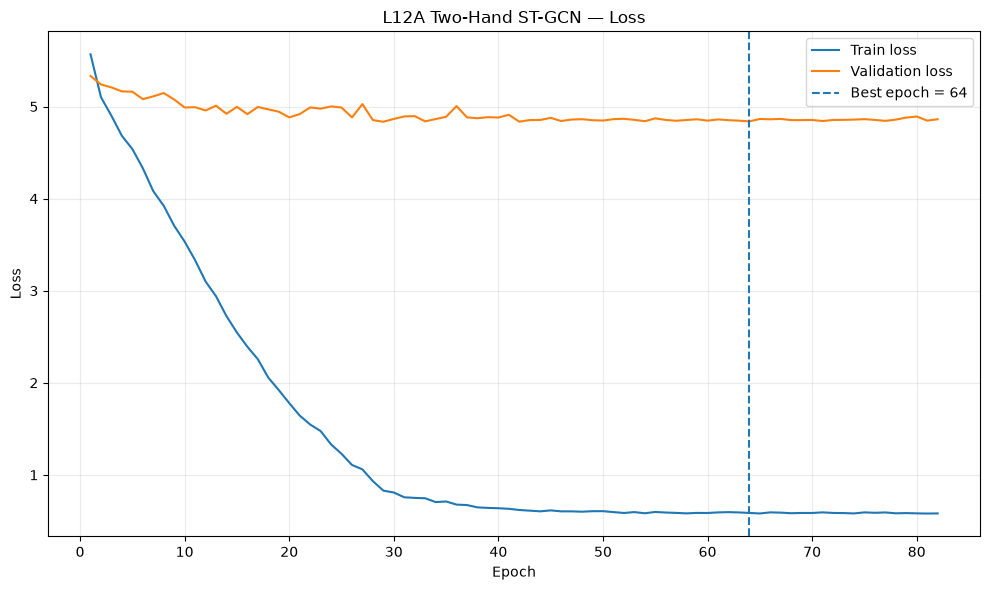

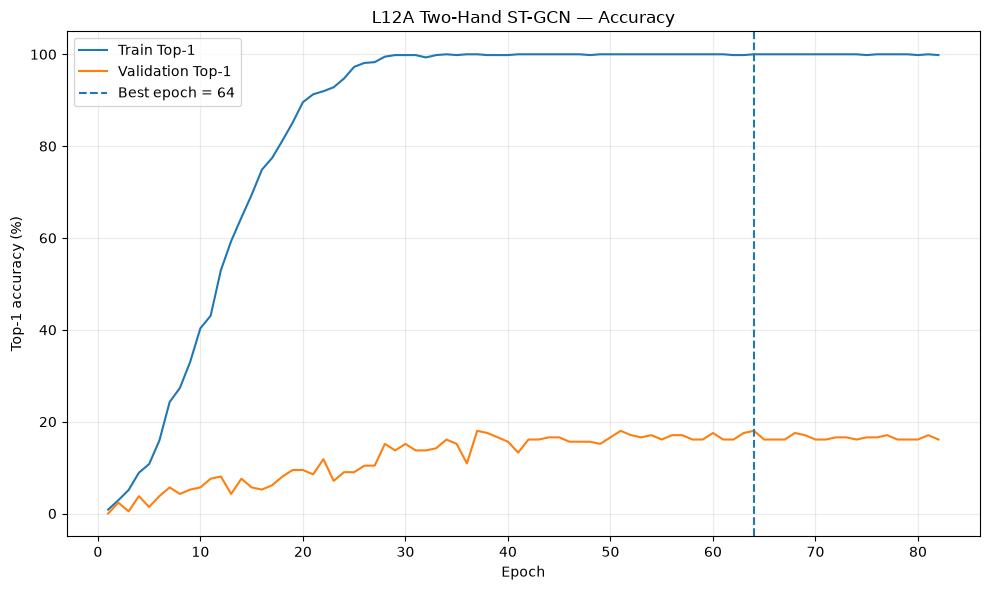


L12A FINAL REPORT

REPRESENTATION
----------------------------------------------------------------------------------------------------------------------------------
Source                   : L6 raw_sequences
Input                    : 11 channels × 32 frames × 42 nodes
Track-0                  : nodes 0-20
Track-1                  : nodes 21-41
Anatomical handedness    : NOT assumed
Inter-hand graph edge    : NO
World XYZ                : YES
World velocity           : YES
Global image XY          : YES
Global image velocity    : YES
Presence mask            : YES

MODEL
----------------------------------------------------------------------------------------------------------------------------------
Architecture             : Two-Hand ST-GCN
Graph partitions         : self + inward + outward
Parameters               : 495,151

VALIDATION
----------------------------------------------------------------------------------------------------------------------------------
Best epoch       

In [5]:
# ==========================================================================================
# CISLR LANDMARK MODEL — L12A
# TWO-HAND GRAPH-NATIVE SPATIOTEMPORAL GCN (ST-GCN)
# ==========================================================================================
#
# RESEARCH QUESTION
# -----------------
# Does explicit hand-skeleton graph topology improve sign recognition compared with:
#
#   L10.0  GRU       + original 32x254 representation
#   L11.0  BiLSTM    + original 32x254 representation
#   L10.2  GRU       + engineered 617-D representation
#
#
# INPUT
# -----
# Frozen L6 RAW sequences:
#
#   landmarks_px       [T, 2, 21, 3]
#   world_landmarks    [T, 2, 21, 3]
#   hand_mask          [T, 2]
#   frame_numbers      [T]
#   width / height
#
#
# GRAPH
# -----
# 42 nodes:
#
#   nodes  0..20  = Track-0 hand
#   nodes 21..41  = Track-1 hand
#
# Each hand uses the real 21-joint hand topology.
#
# IMPORTANT:
# Track-0 / Track-1 are NOT claimed to be anatomical left/right hands.
#
#
# NODE CHANNELS
# -------------
#  0-2 : world XYZ
#  3-5 : world XYZ velocity
#  6-7 : normalized image XY
#  8-9 : normalized image XY velocity
# 10   : hand-presence mask
#
# Total = 11 channels / node
#
#
# PREPROCESSING
# -------------
# - Short internal gaps <= 3 frames interpolated.
# - No long-gap interpolation.
# - No extrapolation.
# - Uniform resampling to 32 frames.
# - Continuous channels normalized using TRAINING DATA ONLY.
# - Missing nodes remain zero after normalization.
#
#
# MODEL
# -----
# Genuine topology-aware ST-GCN:
#
#   input [B,C,T,V]
#       ↓
#   graph convolution using:
#       A0 = self
#       A1 = inward hand edges
#       A2 = outward hand edges
#       ↓
#   temporal convolution
#       ↓
#   residual connection
#       ↓
#   multiple ST-GCN blocks
#       ↓
#   mask-aware temporal/spatial pooling
#       ↓
#   211-way classifier
#
#
# SCIENTIFIC INTEGRITY
# --------------------
# Exact frozen L9 split:
#
#   Train      = 585
#   Validation = 211
#   Test       = 211  <-- LOCKED
#
# TEST RAW SEQUENCES ARE NOT LOADED.
# TEST ACCURACY IS NOT CALCULATED.
#
# ==========================================================================================


# ==========================================================================================
# 0. IMPORTS
# ==========================================================================================

from pathlib import Path

import os
import json
import time
import math
import random
import hashlib
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader


warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 300)

np.set_printoptions(
    precision=6,
    suppress=True
)


# ==========================================================================================
# 1. GLOBAL CONFIGURATION
# ==========================================================================================

SEED = 42

NUM_CLASSES = 211

NUM_HANDS = 2

NUM_LANDMARKS = 21

NUM_NODES = 42

SEQUENCE_LENGTH = 32

MAX_INTERPOLATION_GAP = 3


EXPECTED_TRAIN = 585

EXPECTED_VAL = 211

EXPECTED_TEST = 211


# ==========================================================================================
# 2. NODE CHANNELS
# ==========================================================================================

WORLD_XYZ_CHANNELS = 3

WORLD_VEL_CHANNELS = 3

IMAGE_XY_CHANNELS = 2

IMAGE_VEL_CHANNELS = 2

MASK_CHANNELS = 1


INPUT_CHANNELS = (

    WORLD_XYZ_CHANNELS
    +
    WORLD_VEL_CHANNELS
    +
    IMAGE_XY_CHANNELS
    +
    IMAGE_VEL_CHANNELS
    +
    MASK_CHANNELS
)


assert INPUT_CHANNELS == 11


# ==========================================================================================
# 3. TRAINING CONFIGURATION
# ==========================================================================================
#
# Small dataset:
#
#   585 train videos
#   211 classes
#
# Therefore keep model moderate.
#
# ==========================================================================================

BATCH_SIZE = 32

MAX_EPOCHS = 120

EARLY_STOPPING_PATIENCE = 18


LEARNING_RATE = 5e-4

WEIGHT_DECAY = 5e-4

LABEL_SMOOTHING = 0.05

GRAD_CLIP_NORM = 5.0


LR_FACTOR = 0.5

LR_PATIENCE = 6

MIN_LR = 1e-6


DROPOUT = 0.35


# ------------------------------------------------------------------------------------------
# Conservative training-only augmentation
# ------------------------------------------------------------------------------------------

TEMPORAL_MASK_PROBABILITY = 0.20

MAX_TEMPORAL_MASK_LENGTH = 2

COORD_NOISE_STD = 0.01


NUM_WORKERS = 0

PIN_MEMORY = torch.cuda.is_available()


# ==========================================================================================
# 4. REPRODUCIBILITY
# ==========================================================================================

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)

np.random.seed(SEED)

torch.manual_seed(SEED)


if torch.cuda.is_available():

    torch.cuda.manual_seed(SEED)

    torch.cuda.manual_seed_all(SEED)


try:

    torch.use_deterministic_algorithms(True)

except Exception:

    pass


if torch.backends.cudnn.is_available():

    torch.backends.cudnn.deterministic = True

    torch.backends.cudnn.benchmark = False


# ==========================================================================================
# 5. DEVICE
# ==========================================================================================

DEVICE = torch.device(

    "cuda"

    if torch.cuda.is_available()

    else "cpu"
)


print("=" * 130)

print("CISLR LANDMARK MODEL — L12A")

print("TWO-HAND GRAPH-NATIVE ST-GCN")

print("=" * 130)

print()

print("PyTorch version :", torch.__version__)

print("Device          :", DEVICE)


if torch.cuda.is_available():

    print(
        "GPU             :",
        torch.cuda.get_device_name(0)
    )


# ==========================================================================================
# 6. PATHS
# ==========================================================================================

PROJECT_ROOT = Path(
    "/home/dipshikha/Music/cao/CISLR_RESEARCH"
)


LANDMARK_ROOT = (

    PROJECT_ROOT
    /
    "CISLR_LANDMARK_MODEL"
)


# ------------------------------------------------------------------------------------------
# L6 RAW sequences
# ------------------------------------------------------------------------------------------

L6_ROOT = (

    LANDMARK_ROOT
    /
    "audit"
    /
    "l6_full_extraction"
)


RAW_DIR = (

    L6_ROOT
    /
    "raw_sequences"
)


# ------------------------------------------------------------------------------------------
# L9 frozen split
# ------------------------------------------------------------------------------------------

L9_ROOT = (

    LANDMARK_ROOT
    /
    "audit"
    /
    "l9_split_freeze"
)


TRAIN_MANIFEST_PATH = (

    L9_ROOT
    /
    "splits"
    /
    "l9_train_manifest.csv"
)


VAL_MANIFEST_PATH = (

    L9_ROOT
    /
    "splits"
    /
    "l9_validation_manifest.csv"
)


TEST_MANIFEST_PATH = (

    L9_ROOT
    /
    "splits"
    /
    "l9_test_manifest.csv"
)


L9_CHECKPOINT_PATH = (

    L9_ROOT
    /
    "reports"
    /
    "l9_checkpoint.json"
)


L9_MAPPING_PATH = (

    L9_ROOT
    /
    "class_mapping"
    /
    "l9_controlled_class_mapping.json"
)


# ------------------------------------------------------------------------------------------
# Previous experiments
# ------------------------------------------------------------------------------------------

L10_SUMMARY_PATH = (

    LANDMARK_ROOT
    /
    "audit"
    /
    "l10_gru_baseline"
    /
    "reports"
    /
    "l10_summary.json"
)


L11_SUMMARY_PATH = (

    LANDMARK_ROOT
    /
    "audit"
    /
    "l11_bilstm"
    /
    "reports"
    /
    "l11_summary.json"
)


L102_SUMMARY_PATH = (

    LANDMARK_ROOT
    /
    "audit"
    /
    "l10_2_enhanced_skeleton_gru"
    /
    "reports"
    /
    "l10_2_summary.json"
)


# ==========================================================================================
# 7. L12 OUTPUT PATHS
# ==========================================================================================

L12_ROOT = (

    LANDMARK_ROOT
    /
    "audit"
    /
    "l12_stgcn"
)


MODEL_DIR = (

    L12_ROOT
    /
    "models"
)


PREPROCESS_DIR = (

    L12_ROOT
    /
    "preprocessing"
)


REPORT_DIR = (

    L12_ROOT
    /
    "reports"
)


PLOT_DIR = (

    L12_ROOT
    /
    "plots"
)


for directory in [

    L12_ROOT,

    MODEL_DIR,

    PREPROCESS_DIR,

    REPORT_DIR,

    PLOT_DIR

]:

    directory.mkdir(
        parents=True,
        exist_ok=True
    )


BEST_MODEL_PATH = (

    MODEL_DIR
    /
    "l12_best_stgcn.pt"
)


LAST_MODEL_PATH = (

    MODEL_DIR
    /
    "l12_last_stgcn.pt"
)


CHANNEL_MEAN_PATH = (

    PREPROCESS_DIR
    /
    "l12_train_channel_mean.npy"
)


CHANNEL_STD_PATH = (

    PREPROCESS_DIR
    /
    "l12_train_channel_std.npy"
)


ADJACENCY_PATH = (

    PREPROCESS_DIR
    /
    "l12_adjacency.npy"
)


HISTORY_PATH = (

    REPORT_DIR
    /
    "l12_training_history.csv"
)


VAL_PREDICTIONS_PATH = (

    REPORT_DIR
    /
    "l12_validation_predictions.csv"
)


COMPARISON_PATH = (

    REPORT_DIR
    /
    "l12_model_comparison.csv"
)


REPRESENTATION_AUDIT_PATH = (

    REPORT_DIR
    /
    "l12_representation_audit.json"
)


SUMMARY_PATH = (

    REPORT_DIR
    /
    "l12_summary.json"
)


CHECKPOINT_PATH = (

    REPORT_DIR
    /
    "l12_checkpoint.json"
)


LOSS_PLOT_PATH = (

    PLOT_DIR
    /
    "l12_loss_curve.png"
)


ACCURACY_PLOT_PATH = (

    PLOT_DIR
    /
    "l12_accuracy_curve.png"
)


# ==========================================================================================
# 8. VERIFY INPUT FILES
# ==========================================================================================

required_paths = [

    RAW_DIR,

    TRAIN_MANIFEST_PATH,

    VAL_MANIFEST_PATH,

    TEST_MANIFEST_PATH,

    L9_CHECKPOINT_PATH,

    L9_MAPPING_PATH,

    L10_SUMMARY_PATH,

    L11_SUMMARY_PATH,

    L102_SUMMARY_PATH
]


for path in required_paths:

    if not path.exists():

        raise FileNotFoundError(
            f"Missing required path:\n{path}"
        )


raw_file_count = len(
    list(
        RAW_DIR.glob("*.npz")
    )
)


print()

print(
    "Raw L6 sequence files:",
    raw_file_count
)


if raw_file_count != 7050:

    print(
        "[WARNING] Expected 7050 raw files."
    )


print(
    "[PASS] Required files exist."
)


# ==========================================================================================
# 9. VERIFY L9 CHECKPOINT
# ==========================================================================================

with open(
    L9_CHECKPOINT_PATH,
    "r"
) as f:

    l9_checkpoint = json.load(f)


if not bool(
    l9_checkpoint.get(
        "l9_pass",
        False
    )
):

    raise RuntimeError(
        "Frozen L9 checkpoint is not PASS."
    )


print(
    "[PASS] Frozen L9 checkpoint verified."
)


# ==========================================================================================
# 10. LOAD SPLIT MANIFESTS
# ==========================================================================================

train_manifest = pd.read_csv(
    TRAIN_MANIFEST_PATH
)


val_manifest = pd.read_csv(
    VAL_MANIFEST_PATH
)


# ------------------------------------------------------------------------------------------
# TEST MANIFEST ONLY.
#
# NO TEST RAW FILES ARE OPENED.
# ------------------------------------------------------------------------------------------

test_manifest = pd.read_csv(
    TEST_MANIFEST_PATH
)


if len(train_manifest) != EXPECTED_TRAIN:

    raise RuntimeError(
        f"Expected {EXPECTED_TRAIN} train videos, got {len(train_manifest)}."
    )


if len(val_manifest) != EXPECTED_VAL:

    raise RuntimeError(
        f"Expected {EXPECTED_VAL} validation videos, got {len(val_manifest)}."
    )


if len(test_manifest) != EXPECTED_TEST:

    raise RuntimeError(
        f"Expected {EXPECTED_TEST} test videos, got {len(test_manifest)}."
    )


print()

print("=" * 130)

print("FROZEN L9 SPLIT")

print("=" * 130)

print("Train      :", len(train_manifest))

print("Validation :", len(val_manifest))

print("Test       :", len(test_manifest), "(LOCKED)")


# ==========================================================================================
# 11. VERIFY UID OVERLAP
# ==========================================================================================

train_uids = set(
    train_manifest[
        "uid_clean"
    ].astype(str)
)


val_uids = set(
    val_manifest[
        "uid_clean"
    ].astype(str)
)


test_uids = set(
    test_manifest[
        "uid_clean"
    ].astype(str)
)


assert len(
    train_uids
    &
    val_uids
) == 0


assert len(
    train_uids
    &
    test_uids
) == 0


assert len(
    val_uids
    &
    test_uids
) == 0


print(
    "[PASS] Zero UID overlap."
)


# ==========================================================================================
# 12. CLASS MAPPING
# ==========================================================================================

with open(
    L9_MAPPING_PATH,
    "r"
) as f:

    mapping = json.load(f)


id_to_gloss = {

    int(k):
    str(v)

    for k, v
    in mapping[
        "id_to_gloss"
    ].items()
}


if len(id_to_gloss) != NUM_CLASSES:

    raise RuntimeError(
        f"Expected {NUM_CLASSES} classes."
    )


print(
    "[PASS] 211-class mapping verified."
)


# ==========================================================================================
# 13. HAND GRAPH TOPOLOGY
# ==========================================================================================
#
# MediaPipe-style 21-point hand skeleton.
#
# No arbitrary connection between Track-0 and Track-1.
#
# Therefore graph contains TWO disconnected hand components.
#
# ==========================================================================================

HAND_EDGES = [

    # Thumb
    (0, 1),
    (1, 2),
    (2, 3),
    (3, 4),

    # Index
    (0, 5),
    (5, 6),
    (6, 7),
    (7, 8),

    # Middle
    (0, 9),
    (9, 10),
    (10, 11),
    (11, 12),

    # Ring
    (0, 13),
    (13, 14),
    (14, 15),
    (15, 16),

    # Pinky
    (0, 17),
    (17, 18),
    (18, 19),
    (19, 20),

    # Palm base relation
    (5, 9),
    (9, 13),
    (13, 17)
]


# ==========================================================================================
# 14. BUILD 42-NODE GRAPH
# ==========================================================================================

def build_graph_partitions():

    # --------------------------------------------------------------------------------------
    # A0 = self connections
    # A1 = parent -> child
    # A2 = child -> parent
    #
    # Shape:
    #     [3, 42, 42]
    # --------------------------------------------------------------------------------------

    A = np.zeros(
        (
            3,
            NUM_NODES,
            NUM_NODES
        ),
        dtype=np.float32
    )


    # Self

    for node in range(
        NUM_NODES
    ):

        A[
            0,
            node,
            node
        ] = 1.0


    # Both hand tracks

    for hand_index in range(
        NUM_HANDS
    ):

        offset = (
            hand_index
            *
            NUM_LANDMARKS
        )


        for parent, child in HAND_EDGES:

            p = (
                offset
                +
                parent
            )


            c = (
                offset
                +
                child
            )


            # Parent -> child partition

            A[
                1,
                c,
                p
            ] = 1.0


            # Child -> parent partition

            A[
                2,
                p,
                c
            ] = 1.0


    # --------------------------------------------------------------------------------------
    # Normalize each adjacency partition by destination degree.
    # --------------------------------------------------------------------------------------

    for k in range(
        A.shape[0]
    ):

        degree = A[
            k
        ].sum(
            axis=1,
            keepdims=True
        )


        degree[
            degree
            <
            1.0
        ] = 1.0


        A[
            k
        ] = (
            A[
                k
            ]
            /
            degree
        )


    return A


A_numpy = build_graph_partitions()


np.save(
    ADJACENCY_PATH,
    A_numpy
)


print()

print("=" * 130)

print("GRAPH")

print("=" * 130)

print("Nodes              :", NUM_NODES)

print("Hand components    :", 2)

print("Partitions         :", A_numpy.shape[0])

print("Adjacency shape    :", A_numpy.shape)

print("Inter-hand edge    : NO")


# ==========================================================================================
# 15. RAW FILE LOADER
# ==========================================================================================

def load_raw_sequence(
    uid
):

    path = (

        RAW_DIR
        /
        f"{uid}.npz"
    )


    if not path.exists():

        raise FileNotFoundError(
            path
        )


    with np.load(
        path,
        allow_pickle=True
    ) as d:

        landmarks_px = np.asarray(
            d[
                "landmarks_px"
            ],
            dtype=np.float32
        )


        world_landmarks = np.asarray(
            d[
                "world_landmarks"
            ],
            dtype=np.float32
        )


        hand_mask = np.asarray(
            d[
                "hand_mask"
            ],
            dtype=np.float32
        )


        frame_numbers = np.asarray(
            d[
                "frame_numbers"
            ],
            dtype=np.int32
        )


        width = float(
            np.asarray(
                d[
                    "width"
                ]
            ).item()
        )


        height = float(
            np.asarray(
                d[
                    "height"
                ]
            ).item()
        )


    # --------------------------------------------------------------------------------------
    # Structural checks
    # --------------------------------------------------------------------------------------

    T = len(
        frame_numbers
    )


    if landmarks_px.shape != (
        T,
        2,
        21,
        3
    ):

        raise RuntimeError(
            f"{uid}: invalid landmarks_px shape {landmarks_px.shape}"
        )


    if world_landmarks.shape != (
        T,
        2,
        21,
        3
    ):

        raise RuntimeError(
            f"{uid}: invalid world_landmarks shape {world_landmarks.shape}"
        )


    if hand_mask.shape != (
        T,
        2
    ):

        raise RuntimeError(
            f"{uid}: invalid hand_mask shape {hand_mask.shape}"
        )


    if width <= 0 or height <= 0:

        raise RuntimeError(
            f"{uid}: invalid width/height."
        )


    if not np.isfinite(
        landmarks_px
    ).all():

        raise RuntimeError(
            f"{uid}: landmarks_px contains NaN/Inf."
        )


    if not np.isfinite(
        world_landmarks
    ).all():

        raise RuntimeError(
            f"{uid}: world_landmarks contains NaN/Inf."
        )


    return {

        "landmarks_px":
            landmarks_px,

        "world_landmarks":
            world_landmarks,

        "hand_mask":
            hand_mask,

        "frame_numbers":
            frame_numbers,

        "width":
            width,

        "height":
            height
    }


# ==========================================================================================
# 16. SHORT-GAP INTERPOLATION
# ==========================================================================================
#
# Same principle as frozen L5:
#
# - internal gaps only
# - maximum gap = 3 frames
# - no extrapolation
#
# ==========================================================================================

def interpolate_short_gaps(
    values,
    mask,
    max_gap=3
):

    values = values.copy().astype(
        np.float32
    )


    mask = mask.copy().astype(
        np.float32
    )


    T = values.shape[0]


    state = np.zeros(
        (
            T,
            NUM_HANDS
        ),
        dtype=np.uint8
    )


    state[
        mask
        >
        0.5
    ] = 1


    for hand in range(
        NUM_HANDS
    ):

        valid_indices = np.where(
            mask[
                :,
                hand
            ]
            >
            0.5
        )[0]


        if len(
            valid_indices
        ) < 2:

            continue


        for i in range(
            len(
                valid_indices
            )
            -
            1
        ):

            left = int(
                valid_indices[
                    i
                ]
            )


            right = int(
                valid_indices[
                    i + 1
                ]
            )


            gap = (
                right
                -
                left
                -
                1
            )


            if (
                gap >= 1
                and
                gap <= max_gap
            ):

                for t in range(
                    left + 1,
                    right
                ):

                    alpha = (

                        (
                            t
                            -
                            left
                        )

                        /
                        (
                            right
                            -
                            left
                        )
                    )


                    values[
                        t,
                        hand
                    ] = (

                        (
                            1.0
                            -
                            alpha
                        )

                        *
                        values[
                            left,
                            hand
                        ]

                        +

                        alpha
                        *
                        values[
                            right,
                            hand
                        ]
                    )


                    mask[
                        t,
                        hand
                    ] = 1.0


                    state[
                        t,
                        hand
                    ] = 2


    return (
        values,
        mask,
        state
    )


# ==========================================================================================
# 17. NORMALIZE IMAGE COORDINATES
# ==========================================================================================
#
# Use global image-space coordinates:
#
# x_norm = x / width
# y_norm = y / height
#
# Then center around image center:
#
# x = x_norm - 0.5
# y = y_norm - 0.5
#
# This preserves global hand trajectory and relative hand positions.
#
# ==========================================================================================

def normalize_image_xy(
    landmarks_px,
    width,
    height,
    mask
):

    xy = landmarks_px[
        ...,
        :2
    ].copy().astype(
        np.float32
    )


    xy[
        ...,
        0
    ] = (

        xy[
            ...,
            0
        ]
        /
        width

        -
        0.5
    )


    xy[
        ...,
        1
    ] = (

        xy[
            ...,
            1
        ]
        /
        height

        -
        0.5
    )


    xy *= mask[
        :,
        :,
        None,
        None
    ]


    return xy


# ==========================================================================================
# 18. WORLD LANDMARK NORMALIZATION
# ==========================================================================================
#
# We preserve the geometry from world_landmarks but make each hand translation invariant.
#
# For every valid hand:
#
#   1. subtract wrist
#   2. divide by robust palm scale
#
# Scale = mean distance:
#
#   wrist -> MCP 5
#   wrist -> MCP 9
#   wrist -> MCP 13
#   wrist -> MCP 17
#
# This gives local hand/finger geometry.
#
# ==========================================================================================

def normalize_world_landmarks(
    world,
    mask
):

    output = np.zeros_like(
        world,
        dtype=np.float32
    )


    scales = np.zeros(
        (
            world.shape[0],
            NUM_HANDS
        ),
        dtype=np.float32
    )


    mcp_indices = [
        5,
        9,
        13,
        17
    ]


    for t in range(
        world.shape[0]
    ):

        for hand in range(
            NUM_HANDS
        ):

            if mask[
                t,
                hand
            ] < 0.5:

                continue


            points = world[
                t,
                hand
            ]


            wrist = points[
                0
            ]


            centered = (
                points
                -
                wrist[
                    None,
                    :
                ]
            )


            distances = np.linalg.norm(

                centered[
                    mcp_indices
                ],

                axis=1
            )


            valid_distances = distances[
                distances
                >
                1e-6
            ]


            if len(
                valid_distances
            ) == 0:

                scale = 1.0

            else:

                scale = float(
                    np.mean(
                        valid_distances
                    )
                )


            if (
                not np.isfinite(
                    scale
                )
                or
                scale < 1e-6
            ):

                scale = 1.0


            output[
                t,
                hand
            ] = (
                centered
                /
                scale
            )


            scales[
                t,
                hand
            ] = scale


    return (
        output,
        scales
    )


# ==========================================================================================
# 19. TEMPORAL VELOCITY
# ==========================================================================================

def calculate_velocity(
    values,
    mask
):

    velocity = np.zeros_like(
        values,
        dtype=np.float32
    )


    for t in range(
        1,
        values.shape[0]
    ):

        valid = (

            mask[
                t
            ]
            *
            mask[
                t - 1
            ]
        )


        velocity[
            t
        ] = (

            values[
                t
            ]
            -
            values[
                t - 1
            ]

        ) * (

            valid[
                :,
                None,
                None
            ]
        )


    return velocity


# ==========================================================================================
# 20. RESAMPLE INDICES
# ==========================================================================================

def uniform_resample_indices(
    length,
    target_length=32
):

    if length <= 0:

        raise RuntimeError(
            "Cannot resample zero-length sequence."
        )


    if length == 1:

        return np.zeros(
            target_length,
            dtype=np.int64
        )


    indices = np.linspace(

        0,

        length - 1,

        target_length
    )


    indices = np.rint(
        indices
    ).astype(
        np.int64
    )


    indices = np.clip(

        indices,

        0,

        length - 1
    )


    return indices


# ==========================================================================================
# 21. BUILD GRAPH REPRESENTATION
# ==========================================================================================
#
# Output:
#
#   graph : [C, 32, 42]
#   mask  : [32, 42]
#
# ==========================================================================================

def build_graph_sequence(
    raw
):

    landmarks_px = raw[
        "landmarks_px"
    ]


    world = raw[
        "world_landmarks"
    ]


    original_mask = raw[
        "hand_mask"
    ].copy()


    width = raw[
        "width"
    ]


    height = raw[
        "height"
    ]


    # --------------------------------------------------------------------------------------
    # Interpolate the two coordinate representations independently,
    # using the same visibility mask.
    # --------------------------------------------------------------------------------------

    px_repaired, repaired_mask_px, state_px = interpolate_short_gaps(

        landmarks_px,

        original_mask,

        MAX_INTERPOLATION_GAP
    )


    world_repaired, repaired_mask_world, state_world = interpolate_short_gaps(

        world,

        original_mask,

        MAX_INTERPOLATION_GAP
    )


    # They should produce identical repaired masks.

    if not np.array_equal(

        repaired_mask_px,

        repaired_mask_world

    ):

        raise RuntimeError(
            "PX/world repaired-mask mismatch."
        )


    repaired_mask = repaired_mask_px


    # --------------------------------------------------------------------------------------
    # Global image coordinates.
    # --------------------------------------------------------------------------------------

    image_xy = normalize_image_xy(

        px_repaired,

        width,

        height,

        repaired_mask
    )


    # --------------------------------------------------------------------------------------
    # Local world skeleton.
    # --------------------------------------------------------------------------------------

    world_local, scales = normalize_world_landmarks(

        world_repaired,

        repaired_mask
    )


    # --------------------------------------------------------------------------------------
    # Motion.
    # --------------------------------------------------------------------------------------

    world_velocity = calculate_velocity(

        world_local,

        repaired_mask
    )


    image_velocity = calculate_velocity(

        image_xy,

        repaired_mask
    )


    # --------------------------------------------------------------------------------------
    # Uniform temporal resampling.
    # --------------------------------------------------------------------------------------

    indices = uniform_resample_indices(

        len(
            repaired_mask
        ),

        SEQUENCE_LENGTH
    )


    world_local = world_local[
        indices
    ]


    world_velocity = world_velocity[
        indices
    ]


    image_xy = image_xy[
        indices
    ]


    image_velocity = image_velocity[
        indices
    ]


    sampled_mask = repaired_mask[
        indices
    ]


    # --------------------------------------------------------------------------------------
    # Convert:
    #
    # [T, H, J, ...]
    #
    # to
    #
    # [T, V, ...]
    #
    # where V = 42.
    # --------------------------------------------------------------------------------------

    world_local = world_local.reshape(

        SEQUENCE_LENGTH,

        NUM_NODES,

        3
    )


    world_velocity = world_velocity.reshape(

        SEQUENCE_LENGTH,

        NUM_NODES,

        3
    )


    image_xy = image_xy.reshape(

        SEQUENCE_LENGTH,

        NUM_NODES,

        2
    )


    image_velocity = image_velocity.reshape(

        SEQUENCE_LENGTH,

        NUM_NODES,

        2
    )


    # Hand mask -> node mask

    node_mask = np.repeat(

        sampled_mask,

        NUM_LANDMARKS,

        axis=1
    ).astype(
        np.float32
    )


    # --------------------------------------------------------------------------------------
    # Concatenate node channels.
    #
    # [T,V,11]
    # --------------------------------------------------------------------------------------

    node_features = np.concatenate(

        [

            world_local,

            world_velocity,

            image_xy,

            image_velocity,

            node_mask[
                :,
                :,
                None
            ]

        ],

        axis=2
    ).astype(
        np.float32
    )


    # Missing nodes must remain zero.

    node_features[
        :,
        :,
        :10
    ] *= node_mask[
        :,
        :,
        None
    ]


    # --------------------------------------------------------------------------------------
    # [T,V,C] -> [C,T,V]
    # --------------------------------------------------------------------------------------

    graph = np.transpose(

        node_features,

        (
            2,
            0,
            1
        )
    ).astype(
        np.float32
    )


    if graph.shape != (

        INPUT_CHANNELS,

        SEQUENCE_LENGTH,

        NUM_NODES
    ):

        raise RuntimeError(
            f"Invalid graph shape: {graph.shape}"
        )


    if not np.isfinite(
        graph
    ).all():

        raise RuntimeError(
            "Graph contains NaN/Inf."
        )


    metadata = {

        "original_frames":
            int(
                len(
                    original_mask
                )
            ),

        "original_valid_track0":
            int(
                original_mask[
                    :,
                    0
                ].sum()
            ),

        "original_valid_track1":
            int(
                original_mask[
                    :,
                    1
                ].sum()
            ),

        "repaired_valid_track0":
            int(
                repaired_mask[
                    :,
                    0
                ].sum()
            ),

        "repaired_valid_track1":
            int(
                repaired_mask[
                    :,
                    1
                ].sum()
            ),

        "sampled_valid_track0":
            int(
                sampled_mask[
                    :,
                    0
                ].sum()
            ),

        "sampled_valid_track1":
            int(
                sampled_mask[
                    :,
                    1
                ].sum()
            ),

        "interpolated_track0":
            int(
                (
                    state_px[
                        :,
                        0
                    ]
                    ==
                    2
                ).sum()
            ),

        "interpolated_track1":
            int(
                (
                    state_px[
                        :,
                        1
                    ]
                    ==
                    2
                ).sum()
            )
    }


    return (
        graph,
        node_mask,
        metadata
    )


# ==========================================================================================
# 22. TEST ONE TRAINING SAMPLE
# ==========================================================================================

sample_uid = str(

    train_manifest.iloc[
        0
    ][
        "uid_clean"
    ]
)


sample_raw = load_raw_sequence(
    sample_uid
)


sample_graph, sample_mask, sample_meta = build_graph_sequence(
    sample_raw
)


print()

print("=" * 130)

print("SAMPLE GRAPH")

print("=" * 130)

print("UID                 :", sample_uid)

print("Graph shape         :", sample_graph.shape)

print("Node mask shape     :", sample_mask.shape)

print("Finite              :", np.isfinite(sample_graph).all())

print("Absolute maximum    :", float(np.abs(sample_graph).max()))

print("Metadata            :", sample_meta)


# ==========================================================================================
# 23. BUILD TRAIN/VALIDATION POPULATIONS
# ==========================================================================================
#
# IMPORTANT:
#
# ONLY TRAIN + VALIDATION RAW FILES ARE LOADED.
#
# ==========================================================================================

def build_population(
    manifest,
    split_name
):

    X = np.zeros(

        (
            len(manifest),
            INPUT_CHANNELS,
            SEQUENCE_LENGTH,
            NUM_NODES
        ),

        dtype=np.float32
    )


    node_masks = np.zeros(

        (
            len(manifest),
            SEQUENCE_LENGTH,
            NUM_NODES
        ),

        dtype=np.float32
    )


    y = manifest[
        "class_id"
    ].to_numpy(
        dtype=np.int64
    )


    metadata_rows = []


    print()

    print(
        f"Building {split_name} graph representation..."
    )


    start = time.perf_counter()


    for i, row in enumerate(

        manifest.itertuples(
            index=False
        )
    ):

        uid = str(
            row.uid_clean
        )


        raw = load_raw_sequence(
            uid
        )


        graph, node_mask, meta = build_graph_sequence(
            raw
        )


        X[
            i
        ] = graph


        node_masks[
            i
        ] = node_mask


        metadata_rows.append(

            {

                "uid":
                    uid,

                "class_id":
                    int(
                        row.class_id
                    ),

                "gloss":
                    str(
                        row.gloss
                    ),

                **meta
            }
        )


        if (
            (i + 1) % 100 == 0
            or
            (i + 1) == len(manifest)
        ):

            print(
                f"  {i + 1}/{len(manifest)}"
            )


    elapsed = (

        time.perf_counter()
        -
        start
    )


    print(
        f"[DONE] {split_name}: {elapsed:.2f} sec"
    )


    return (

        X,

        node_masks,

        y,

        pd.DataFrame(
            metadata_rows
        )
    )


X_train_raw, M_train, y_train, train_representation_df = build_population(

    train_manifest,

    "TRAIN"
)


X_val_raw, M_val, y_val, val_representation_df = build_population(

    val_manifest,

    "VALIDATION"
)


print()

print("Train graph shape :", X_train_raw.shape)

print("Train mask shape  :", M_train.shape)

print("Val graph shape   :", X_val_raw.shape)

print("Val mask shape    :", M_val.shape)


# ==========================================================================================
# 24. STRUCTURAL AUDIT
# ==========================================================================================

expected_train_shape = (

    EXPECTED_TRAIN,

    INPUT_CHANNELS,

    SEQUENCE_LENGTH,

    NUM_NODES
)


expected_val_shape = (

    EXPECTED_VAL,

    INPUT_CHANNELS,

    SEQUENCE_LENGTH,

    NUM_NODES
)


if X_train_raw.shape != expected_train_shape:

    raise RuntimeError(
        f"Train graph shape mismatch: {X_train_raw.shape}"
    )


if X_val_raw.shape != expected_val_shape:

    raise RuntimeError(
        f"Validation graph shape mismatch: {X_val_raw.shape}"
    )


if not np.isfinite(
    X_train_raw
).all():

    raise RuntimeError(
        "Train graph contains NaN/Inf."
    )


if not np.isfinite(
    X_val_raw
).all():

    raise RuntimeError(
        "Validation graph contains NaN/Inf."
    )


print()

print(
    "[PASS] Graph representation structural audit."
)


# ==========================================================================================
# 25. MASK-AWARE TRAIN-ONLY CHANNEL NORMALIZATION
# ==========================================================================================
#
# Channels:
#
# 0..9  = continuous
# 10    = mask
#
# Fit statistics only over VALID TRAINING NODES.
#
# Missing nodes are NOT included in the statistics.
#
# After standardization:
#
# missing continuous features remain exactly 0.
#
# ==========================================================================================

CONTINUOUS_CHANNELS = 10

MASK_CHANNEL = 10


train_mean = np.zeros(
    CONTINUOUS_CHANNELS,
    dtype=np.float32
)


train_std = np.ones(
    CONTINUOUS_CHANNELS,
    dtype=np.float32
)


valid_mask_train = (

    X_train_raw[
        :,
        MASK_CHANNEL,
        :,
        :
    ]
    >
    0.5
)


for c in range(
    CONTINUOUS_CHANNELS
):

    values = X_train_raw[
        :,
        c,
        :,
        :
    ][
        valid_mask_train
    ]


    if len(
        values
    ) == 0:

        train_mean[
            c
        ] = 0.0


        train_std[
            c
        ] = 1.0


    else:

        train_mean[
            c
        ] = float(
            values.mean()
        )


        std = float(
            values.std()
        )


        if (
            not np.isfinite(
                std
            )
            or
            std < 1e-6
        ):

            std = 1.0


        train_std[
            c
        ] = std


np.save(
    CHANNEL_MEAN_PATH,
    train_mean
)


np.save(
    CHANNEL_STD_PATH,
    train_std
)


print()

print("=" * 130)

print("TRAIN-ONLY MASK-AWARE NORMALIZATION")

print("=" * 130)

print("Channel mean:")

print(train_mean)

print()

print("Channel std:")

print(train_std)


# ==========================================================================================
# 26. APPLY NORMALIZATION
# ==========================================================================================

def normalize_population(
    X
):

    Y = X.copy().astype(
        np.float32
    )


    node_mask = (

        Y[
            :,
            MASK_CHANNEL,
            :,
            :
        ]
        >
        0.5
    )


    for c in range(
        CONTINUOUS_CHANNELS
    ):

        channel = Y[
            :,
            c,
            :,
            :
        ]


        normalized = (

            channel
            -
            train_mean[
                c
            ]

        ) / (

            train_std[
                c
            ]
        )


        # Missing nodes remain exactly zero.

        normalized[
            ~node_mask
        ] = 0.0


        Y[
            :,
            c,
            :,
            :
        ] = normalized


    # Preserve binary mask exactly.

    Y[
        :,
        MASK_CHANNEL,
        :,
        :
    ] = node_mask.astype(
        np.float32
    )


    return Y


X_train = normalize_population(
    X_train_raw
)


X_val = normalize_population(
    X_val_raw
)


assert np.isfinite(
    X_train
).all()


assert np.isfinite(
    X_val
).all()


assert np.array_equal(

    X_train[
        :,
        MASK_CHANNEL
    ],

    X_train_raw[
        :,
        MASK_CHANNEL
    ]
)


assert np.array_equal(

    X_val[
        :,
        MASK_CHANNEL
    ],

    X_val_raw[
        :,
        MASK_CHANNEL
    ]
)


# ==========================================================================================
# 27. VERIFY MISSING NODES ARE ZERO
# ==========================================================================================

train_missing = (

    X_train[
        :,
        MASK_CHANNEL
    ]
    <
    0.5
)


val_missing = (

    X_val[
        :,
        MASK_CHANNEL
    ]
    <
    0.5
)


for c in range(
    CONTINUOUS_CHANNELS
):

    if not np.allclose(

        X_train[
            :,
            c
        ][
            train_missing
        ],

        0.0

    ):

        raise RuntimeError(
            "Train missing-node normalization failure."
        )


    if not np.allclose(

        X_val[
            :,
            c
        ][
            val_missing
        ],

        0.0

    ):

        raise RuntimeError(
            "Validation missing-node normalization failure."
        )


print()

print(
    "[PASS] Missing graph nodes remain zero."
)


# ==========================================================================================
# 28. REPRESENTATION AUDIT
# ==========================================================================================

representation_audit = {

    "stage":
        "L12A",

    "train_samples":
        int(
            len(
                X_train
            )
        ),

    "validation_samples":
        int(
            len(
                X_val
            )
        ),

    "test_manifest_samples":
        int(
            len(
                test_manifest
            )
        ),

    "test_raw_sequences_loaded":
        False,

    "input_channels":
        INPUT_CHANNELS,

    "sequence_length":
        SEQUENCE_LENGTH,

    "graph_nodes":
        NUM_NODES,

    "adjacency_partitions":
        int(
            A_numpy.shape[
                0
            ]
        ),

    "train_shape":
        list(
            X_train.shape
        ),

    "validation_shape":
        list(
            X_val.shape
        ),

    "train_raw_abs_max":
        float(
            np.abs(
                X_train_raw
            ).max()
        ),

    "validation_raw_abs_max":
        float(
            np.abs(
                X_val_raw
            ).max()
        ),

    "train_normalized_abs_max":
        float(
            np.abs(
                X_train
            ).max()
        ),

    "validation_normalized_abs_max":
        float(
            np.abs(
                X_val
            ).max()
        ),

    "train_valid_node_fraction":
        float(
            X_train[
                :,
                MASK_CHANNEL
            ].mean()
        ),

    "validation_valid_node_fraction":
        float(
            X_val[
                :,
                MASK_CHANNEL
            ].mean()
        ),

    "short_gap_interpolation_max":
        MAX_INTERPOLATION_GAP,

    "finite_train":
        bool(
            np.isfinite(
                X_train
            ).all()
        ),

    "finite_validation":
        bool(
            np.isfinite(
                X_val
            ).all()
        )
}


with open(
    REPRESENTATION_AUDIT_PATH,
    "w"
) as f:

    json.dump(
        representation_audit,
        f,
        indent=4
    )


# ==========================================================================================
# 29. DATASET
# ==========================================================================================

class SkeletonGraphDataset(
    Dataset
):

    def __init__(
        self,
        X,
        y,
        training=False
    ):

        self.X = X

        self.y = y

        self.training = training


    def __len__(
        self
    ):

        return len(
            self.y
        )


    def __getitem__(
        self,
        index
    ):

        x = self.X[
            index
        ].copy()


        y = int(
            self.y[
                index
            ]
        )


        if self.training:

            # ------------------------------------------------------------------
            # Small coordinate noise on continuous channels.
            #
            # Do not modify mask.
            # Do not add noise to missing nodes.
            # ------------------------------------------------------------------

            if COORD_NOISE_STD > 0:

                node_mask = x[
                    MASK_CHANNEL:
                    MASK_CHANNEL + 1
                ]


                noise = np.random.normal(

                    loc=0.0,

                    scale=COORD_NOISE_STD,

                    size=(
                        CONTINUOUS_CHANNELS,
                        SEQUENCE_LENGTH,
                        NUM_NODES
                    )

                ).astype(
                    np.float32
                )


                noise *= node_mask


                x[
                    :CONTINUOUS_CHANNELS
                ] += noise


            # ------------------------------------------------------------------
            # Short temporal masking.
            #
            # This simulates brief detector failure.
            # ------------------------------------------------------------------

            if (
                np.random.rand()
                <
                TEMPORAL_MASK_PROBABILITY
            ):

                mask_length = np.random.randint(

                    1,

                    MAX_TEMPORAL_MASK_LENGTH + 1
                )


                start = np.random.randint(

                    0,

                    SEQUENCE_LENGTH
                    -
                    mask_length
                    +
                    1
                )


                x[
                    :,
                    start:
                    start + mask_length,
                    :
                ] = 0.0


        return (

            torch.from_numpy(
                x
            ).float(),

            torch.tensor(
                y,
                dtype=torch.long
            )
        )


train_dataset = SkeletonGraphDataset(

    X_train,

    y_train,

    training=True
)


val_dataset = SkeletonGraphDataset(

    X_val,

    y_val,

    training=False
)


# ==========================================================================================
# 30. DATALOADERS
# ==========================================================================================

generator = torch.Generator()

generator.manual_seed(
    SEED
)


train_loader = DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=True,

    num_workers=NUM_WORKERS,

    pin_memory=PIN_MEMORY,

    generator=generator
)


val_loader = DataLoader(

    val_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=NUM_WORKERS,

    pin_memory=PIN_MEMORY
)


# ==========================================================================================
# 31. GRAPH CONVOLUTION
# ==========================================================================================
#
# Canonical ST-GCN-style graph convolution:
#
# Conv2D:
#
#   C_in
#      ↓
#   K * C_out
#
# reshape:
#
#   [N,K,C_out,T,V]
#
# graph propagation:
#
#   each K feature partition uses A[k]
#
# ==========================================================================================

class GraphConv(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels,
        K
    ):

        super().__init__()


        self.K = K

        self.out_channels = out_channels


        self.conv = nn.Conv2d(

            in_channels,

            out_channels
            *
            K,

            kernel_size=1,

            bias=False
        )


    def forward(
        self,
        x,
        A
    ):

        # x:
        #
        # [N,C,T,V]

        x = self.conv(
            x
        )


        N, KC, T, V = x.shape


        x = x.view(

            N,

            self.K,

            self.out_channels,

            T,

            V
        )


        # Graph propagation.
        #
        # n k c t v
        # k v w
        #
        # ->
        #
        # n c t w

        x = torch.einsum(

            "nkctv,kvw->nctw",

            x,

            A
        )


        return x


# ==========================================================================================
# 32. ST-GCN BLOCK
# ==========================================================================================

class STGCNBlock(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels,
        K,
        dropout=0.0,
        residual=True
    ):

        super().__init__()


        self.gcn = GraphConv(

            in_channels,

            out_channels,

            K
        )


        self.gcn_bn = nn.BatchNorm2d(
            out_channels
        )


        self.temporal = nn.Sequential(

            nn.ReLU(
                inplace=True
            ),

            nn.Conv2d(

                out_channels,

                out_channels,

                kernel_size=(
                    9,
                    1
                ),

                padding=(
                    4,
                    0
                ),

                bias=False
            ),

            nn.BatchNorm2d(
                out_channels
            ),

            nn.Dropout(
                dropout
            )
        )


        if not residual:

            self.residual = lambda x: 0


        elif (
            in_channels
            ==
            out_channels
        ):

            self.residual = nn.Identity()


        else:

            self.residual = nn.Sequential(

                nn.Conv2d(

                    in_channels,

                    out_channels,

                    kernel_size=1,

                    bias=False
                ),

                nn.BatchNorm2d(
                    out_channels
                )
            )


        self.relu = nn.ReLU(
            inplace=True
        )


    def forward(
        self,
        x,
        A
    ):

        residual = self.residual(
            x
        )


        x = self.gcn(
            x,
            A
        )


        x = self.gcn_bn(
            x
        )


        x = self.temporal(
            x
        )


        x = (
            x
            +
            residual
        )


        x = self.relu(
            x
        )


        return x


# ==========================================================================================
# 33. FULL ST-GCN
# ==========================================================================================

class TwoHandSTGCN(nn.Module):

    def __init__(
        self,
        num_classes,
        adjacency,
        dropout=0.35
    ):

        super().__init__()


        A = torch.tensor(

            adjacency,

            dtype=torch.float32
        )


        self.register_buffer(
            "A",
            A
        )


        self.K = int(
            A.shape[
                0
            ]
        )


        # ----------------------------------------------------------------------
        # Input normalization.
        # ----------------------------------------------------------------------

        self.input_bn = nn.BatchNorm1d(

            INPUT_CHANNELS
            *
            NUM_NODES
        )


        # ----------------------------------------------------------------------
        # Small ST-GCN for limited training population.
        # ----------------------------------------------------------------------

        self.block1 = STGCNBlock(

            INPUT_CHANNELS,

            64,

            self.K,

            dropout=
                dropout * 0.5,

            residual=False
        )


        self.block2 = STGCNBlock(

            64,

            64,

            self.K,

            dropout=
                dropout
        )


        self.block3 = STGCNBlock(

            64,

            128,

            self.K,

            dropout=
                dropout
        )


        self.block4 = STGCNBlock(

            128,

            128,

            self.K,

            dropout=
                dropout
        )


        self.output_norm = nn.LayerNorm(
            128
        )


        self.dropout = nn.Dropout(
            dropout
        )


        self.classifier = nn.Linear(

            128,

            num_classes
        )


    def forward(
        self,
        x
    ):

        # ----------------------------------------------------------------------
        # x:
        #
        # [N,C,T,V]
        # ----------------------------------------------------------------------

        N, C, T, V = x.shape


        # Save original node visibility before feature transformation.

        node_mask = x[
            :,
            MASK_CHANNEL:
            MASK_CHANNEL + 1,
            :,
            :
        ]


        # ----------------------------------------------------------------------
        # Input BN.
        #
        # [N,C,T,V]
        # -> [N,V,C,T]
        # -> [N,V*C,T]
        # ----------------------------------------------------------------------

        x = x.permute(
            0,
            3,
            1,
            2
        ).contiguous()


        x = x.view(

            N,

            V * C,

            T
        )


        x = self.input_bn(
            x
        )


        x = x.view(

            N,

            V,

            C,

            T
        )


        x = x.permute(
            0,
            2,
            3,
            1
        ).contiguous()


        # ----------------------------------------------------------------------
        # ST-GCN
        # ----------------------------------------------------------------------

        x = self.block1(
            x,
            self.A
        )


        x = self.block2(
            x,
            self.A
        )


        x = self.block3(
            x,
            self.A
        )


        x = self.block4(
            x,
            self.A
        )


        # ----------------------------------------------------------------------
        # Mask-aware global pooling.
        #
        # node_mask:
        # [N,1,T,V]
        #
        # Broadcast across feature channels.
        # ----------------------------------------------------------------------

        x = (
            x
            *
            node_mask
        )


        denominator = node_mask.sum(

            dim=(
                2,
                3
            )
        ).clamp(
            min=1.0
        )


        pooled = x.sum(

            dim=(
                2,
                3
            )

        ) / denominator


        pooled = self.output_norm(
            pooled
        )


        pooled = self.dropout(
            pooled
        )


        logits = self.classifier(
            pooled
        )


        return logits


# ==========================================================================================
# 34. CREATE MODEL
# ==========================================================================================

model = TwoHandSTGCN(

    num_classes=
        NUM_CLASSES,

    adjacency=
        A_numpy,

    dropout=
        DROPOUT

).to(
    DEVICE
)


total_parameters = sum(

    p.numel()

    for p
    in model.parameters()
)


trainable_parameters = sum(

    p.numel()

    for p
    in model.parameters()

    if p.requires_grad
)


print()

print("=" * 130)

print("L12 ST-GCN MODEL")

print("=" * 130)

print(model)

print()

print(
    "Input channels       :",
    INPUT_CHANNELS
)

print(
    "Graph nodes          :",
    NUM_NODES
)

print(
    "Adjacency partitions :",
    A_numpy.shape[0]
)

print(
    "Parameters           :",
    f"{total_parameters:,}"
)

print(
    "Trainable parameters :",
    f"{trainable_parameters:,}"
)


# ==========================================================================================
# 35. FORWARD-PASS SANITY CHECK
# ==========================================================================================

model.eval()


with torch.no_grad():

    sample_tensor = torch.from_numpy(

        X_train[
            :2
        ]

    ).float().to(
        DEVICE
    )


    sample_logits = model(
        sample_tensor
    )


if sample_logits.shape != (
    2,
    NUM_CLASSES
):

    raise RuntimeError(
        f"Unexpected model output: {sample_logits.shape}"
    )


if not torch.isfinite(
    sample_logits
).all():

    raise RuntimeError(
        "Model sanity check produced NaN/Inf."
    )


print()

print(
    "[PASS] Forward pass:",
    tuple(
        sample_logits.shape
    )
)


# ==========================================================================================
# 36. LOSS
# ==========================================================================================

criterion = nn.CrossEntropyLoss(

    label_smoothing=
        LABEL_SMOOTHING
)


# ==========================================================================================
# 37. OPTIMIZER
# ==========================================================================================

optimizer = torch.optim.AdamW(

    model.parameters(),

    lr=
        LEARNING_RATE,

    weight_decay=
        WEIGHT_DECAY
)


scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(

    optimizer,

    mode="min",

    factor=
        LR_FACTOR,

    patience=
        LR_PATIENCE,

    min_lr=
        MIN_LR
)


# ==========================================================================================
# 38. TOP-K
# ==========================================================================================

def topk_counts(
    logits,
    targets
):

    _, predictions = torch.topk(

        logits,

        k=5,

        dim=1
    )


    top1 = (

        predictions[
            :,
            0
        ]
        ==
        targets

    ).sum().item()


    top5 = (

        predictions
        ==
        targets[
            :,
            None
        ]

    ).any(
        dim=1
    ).sum().item()


    return (
        int(top1),
        int(top5)
    )


# ==========================================================================================
# 39. TRAIN ONE EPOCH
# ==========================================================================================

def train_one_epoch():

    model.train()


    total_loss = 0.0

    total = 0

    correct1 = 0

    correct5 = 0


    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(

            DEVICE,

            non_blocking=True
        )


        y_batch = y_batch.to(

            DEVICE,

            non_blocking=True
        )


        optimizer.zero_grad(
            set_to_none=True
        )


        logits = model(
            X_batch
        )


        loss = criterion(

            logits,

            y_batch
        )


        if not torch.isfinite(
            loss
        ):

            raise RuntimeError(
                "Non-finite training loss."
            )


        loss.backward()


        torch.nn.utils.clip_grad_norm_(

            model.parameters(),

            GRAD_CLIP_NORM
        )


        optimizer.step()


        batch_size = y_batch.size(
            0
        )


        c1, c5 = topk_counts(

            logits,

            y_batch
        )


        total_loss += (

            loss.item()
            *
            batch_size
        )


        total += batch_size

        correct1 += c1

        correct5 += c5


    return (

        total_loss
        /
        total,

        correct1
        /
        total,

        correct5
        /
        total
    )


# ==========================================================================================
# 40. VALIDATION
# ==========================================================================================

@torch.no_grad()
def evaluate_validation():

    model.eval()


    total_loss = 0.0

    total = 0

    correct1 = 0

    correct5 = 0


    all_logits = []

    all_targets = []


    for X_batch, y_batch in val_loader:

        X_batch = X_batch.to(

            DEVICE,

            non_blocking=True
        )


        y_batch = y_batch.to(

            DEVICE,

            non_blocking=True
        )


        logits = model(
            X_batch
        )


        loss = criterion(

            logits,

            y_batch
        )


        batch_size = y_batch.size(
            0
        )


        c1, c5 = topk_counts(

            logits,

            y_batch
        )


        total_loss += (

            loss.item()
            *
            batch_size
        )


        total += batch_size

        correct1 += c1

        correct5 += c5


        all_logits.append(
            logits.cpu()
        )


        all_targets.append(
            y_batch.cpu()
        )


    return (

        total_loss
        /
        total,

        correct1
        /
        total,

        correct5
        /
        total,

        torch.cat(
            all_logits
        ),

        torch.cat(
            all_targets
        )
    )


# ==========================================================================================
# 41. CHECKPOINT SAVER
# ==========================================================================================

def save_model_checkpoint(
    path,
    epoch,
    val_loss,
    val_top1,
    val_top5
):

    torch.save(

        {

            "stage":
                "L12A",

            "architecture":
                "TwoHandSTGCN",

            "epoch":
                int(
                    epoch
                ),

            "model_state_dict":
                model.state_dict(),

            "model_config":
                {

                    "input_channels":
                        INPUT_CHANNELS,

                    "sequence_length":
                        SEQUENCE_LENGTH,

                    "num_nodes":
                        NUM_NODES,

                    "num_classes":
                        NUM_CLASSES,

                    "dropout":
                        DROPOUT
                },

            "graph":
                {

                    "nodes":
                        NUM_NODES,

                    "partitions":
                        int(
                            A_numpy.shape[
                                0
                            ]
                        ),

                    "inter_hand_edge":
                        False,

                    "track_semantics":
                        "Track-0 / Track-1; not anatomical handedness"
                },

            "representation":
                {

                    "world_xyz":
                        True,

                    "world_velocity":
                        True,

                    "normalized_image_xy":
                        True,

                    "image_velocity":
                        True,

                    "presence_mask":
                        True
                },

            "preprocessing":
                {

                    "fit_on":
                        "L9_TRAIN_ONLY",

                    "channel_mean_path":
                        str(
                            CHANNEL_MEAN_PATH
                        ),

                    "channel_std_path":
                        str(
                            CHANNEL_STD_PATH
                        )
                },

            "validation":
                {

                    "loss":
                        float(
                            val_loss
                        ),

                    "top1":
                        float(
                            val_top1
                        ),

                    "top5":
                        float(
                            val_top5
                        )
                },

            "test_raw_loaded":
                False,

            "test_evaluated":
                False

        },

        path
    )


# ==========================================================================================
# 42. TRAINING
# ==========================================================================================

print()

print("=" * 130)

print("STARTING L12A ST-GCN TRAINING")

print("=" * 130)

print()

print("Training samples       :", len(train_dataset))

print("Validation samples     :", len(val_dataset))

print("Test samples           :", len(test_manifest), "(LOCKED)")

print()

print("Input                  :", f"[B,{INPUT_CHANNELS},32,42]")

print("Dropout                :", DROPOUT)

print("Label smoothing        :", LABEL_SMOOTHING)

print("Learning rate          :", LEARNING_RATE)

print("Weight decay           :", WEIGHT_DECAY)

print("Temporal mask prob     :", TEMPORAL_MASK_PROBABILITY)

print("Coordinate noise std   :", COORD_NOISE_STD)

print()


history = []


best_epoch = 0

best_val_top1 = -1.0

best_val_top5 = -1.0

best_val_loss = float(
    "inf"
)


epochs_without_improvement = 0


training_start = time.perf_counter()


for epoch in range(
    1,
    MAX_EPOCHS + 1
):

    epoch_start = time.perf_counter()


    (
        train_loss,
        train_top1,
        train_top5
    ) = train_one_epoch()


    (
        val_loss,
        val_top1,
        val_top5,
        _,
        _
    ) = evaluate_validation()


    scheduler.step(
        val_loss
    )


    current_lr = float(

        optimizer.param_groups[
            0
        ][
            "lr"
        ]
    )


    # --------------------------------------------------------------------------------------
    # Selection:
    #
    # 1. Highest validation Top-1
    # 2. Lower validation loss on tie
    # --------------------------------------------------------------------------------------

    improved = False


    if (
        val_top1
        >
        best_val_top1
    ):

        improved = True


    elif (

        np.isclose(
            val_top1,
            best_val_top1
        )

        and

        val_loss
        <
        best_val_loss
    ):

        improved = True


    if improved:

        best_epoch = epoch

        best_val_top1 = val_top1

        best_val_top5 = val_top5

        best_val_loss = val_loss

        epochs_without_improvement = 0


        save_model_checkpoint(

            BEST_MODEL_PATH,

            epoch,

            val_loss,

            val_top1,

            val_top5
        )


    else:

        epochs_without_improvement += 1


    epoch_seconds = (

        time.perf_counter()
        -
        epoch_start
    )


    history.append(

        {

            "epoch":
                epoch,

            "train_loss":
                train_loss,

            "train_top1":
                train_top1,

            "train_top5":
                train_top5,

            "val_loss":
                val_loss,

            "val_top1":
                val_top1,

            "val_top5":
                val_top5,

            "learning_rate":
                current_lr,

            "epoch_seconds":
                epoch_seconds,

            "best_so_far":
                improved
        }
    )


    print(

        f"Epoch {epoch:03d}/{MAX_EPOCHS} | "

        f"train loss={train_loss:.4f} | "

        f"Top1={100 * train_top1:6.2f}% | "

        f"Top5={100 * train_top5:6.2f}% || "

        f"val loss={val_loss:.4f} | "

        f"Top1={100 * val_top1:6.2f}% | "

        f"Top5={100 * val_top5:6.2f}% | "

        f"lr={current_lr:.2e} | "

        f"{epoch_seconds:.2f}s"

        +

        (
            "  <-- BEST"

            if improved

            else ""
        )
    )


    if (

        epochs_without_improvement
        >=
        EARLY_STOPPING_PATIENCE
    ):

        print()

        print(
            "[EARLY STOPPING]"
        )

        print(
            f"No validation Top-1 improvement for "
            f"{EARLY_STOPPING_PATIENCE} epochs."
        )

        break


training_seconds = (

    time.perf_counter()
    -
    training_start
)


# ==========================================================================================
# 43. SAVE HISTORY
# ==========================================================================================

history_df = pd.DataFrame(
    history
)


history_df.to_csv(

    HISTORY_PATH,

    index=False
)


# ==========================================================================================
# 44. SAVE LAST MODEL
# ==========================================================================================

last = history[
    -1
]


save_model_checkpoint(

    LAST_MODEL_PATH,

    int(
        last[
            "epoch"
        ]
    ),

    float(
        last[
            "val_loss"
        ]
    ),

    float(
        last[
            "val_top1"
        ]
    ),

    float(
        last[
            "val_top5"
        ]
    )
)


# ==========================================================================================
# 45. LOAD BEST MODEL
# ==========================================================================================

best_checkpoint = torch.load(

    BEST_MODEL_PATH,

    map_location=DEVICE
)


model.load_state_dict(

    best_checkpoint[
        "model_state_dict"
    ]
)


model.eval()


# ==========================================================================================
# 46. FINAL VALIDATION
# ==========================================================================================

(
    final_val_loss,
    final_val_top1,
    final_val_top5,
    final_logits,
    final_targets
) = evaluate_validation()


final_top1_correct = int(

    (
        final_logits.argmax(
            dim=1
        )
        ==
        final_targets

    ).sum().item()
)


final_top5_indices = torch.topk(

    final_logits,

    k=5,

    dim=1

).indices


final_top5_correct = int(

    (

        final_top5_indices
        ==
        final_targets[
            :,
            None
        ]

    ).any(
        dim=1
    ).sum().item()
)


print()

print("=" * 130)

print("BEST L12A VALIDATION RESULT")

print("=" * 130)

print()

print("Best epoch       :", best_epoch)

print("Validation loss  :", f"{final_val_loss:.6f}")

print("Validation Top-1 :", f"{100 * final_val_top1:.2f}%")

print("Validation Top-5 :", f"{100 * final_val_top5:.2f}%")

print("Top-1 correct    :", f"{final_top1_correct}/211")

print("Top-5 correct    :", f"{final_top5_correct}/211")


# ==========================================================================================
# 47. CHANCE LEVEL
# ==========================================================================================

chance_top1 = (
    1.0
    /
    NUM_CLASSES
)


chance_top5 = (
    5.0
    /
    NUM_CLASSES
)


print()

print(
    "Chance Top-1     :",
    f"{100 * chance_top1:.3f}%"
)

print(
    "Chance Top-5     :",
    f"{100 * chance_top5:.3f}%"
)


# ==========================================================================================
# 48. VALIDATION PREDICTIONS
# ==========================================================================================

probabilities = torch.softmax(

    final_logits,

    dim=1
)


top5_probabilities, top5_indices = torch.topk(

    probabilities,

    k=5,

    dim=1
)


prediction_rows = []


for i in range(
    len(
        val_manifest
    )
):

    true_id = int(
        final_targets[
            i
        ].item()
    )


    pred_ids = [

        int(x)

        for x
        in top5_indices[
            i
        ].tolist()
    ]


    pred_probs = [

        float(x)

        for x
        in top5_probabilities[
            i
        ].tolist()
    ]


    row = {

        "uid":
            str(
                val_manifest.iloc[
                    i
                ][
                    "uid_clean"
                ]
            ),

        "true_class_id":
            true_id,

        "true_gloss":
            id_to_gloss[
                true_id
            ],

        "predicted_class_id":
            pred_ids[
                0
            ],

        "predicted_gloss":
            id_to_gloss[
                pred_ids[
                    0
                ]
            ],

        "top1_probability":
            pred_probs[
                0
            ],

        "top1_correct":
            pred_ids[
                0
            ]
            ==
            true_id,

        "top5_correct":
            true_id
            in
            pred_ids
    }


    for rank in range(
        5
    ):

        row[
            f"rank_{rank + 1}_class_id"
        ] = pred_ids[
            rank
        ]


        row[
            f"rank_{rank + 1}_gloss"
        ] = id_to_gloss[
            pred_ids[
                rank
            ]
        ]


        row[
            f"rank_{rank + 1}_probability"
        ] = pred_probs[
            rank
        ]


    prediction_rows.append(
        row
    )


prediction_df = pd.DataFrame(
    prediction_rows
)


prediction_df.to_csv(

    VAL_PREDICTIONS_PATH,

    index=False
)


# ==========================================================================================
# 49. LOAD PREVIOUS RESULTS
# ==========================================================================================

def read_json(
    path
):

    with open(
        path,
        "r"
    ) as f:

        return json.load(
            f
        )


l10_summary = read_json(
    L10_SUMMARY_PATH
)


l11_summary = read_json(
    L11_SUMMARY_PATH
)


l102_summary = read_json(
    L102_SUMMARY_PATH
)


l10_top1 = float(
    l10_summary[
        "validation"
    ][
        "top1"
    ]
)


l10_top5 = float(
    l10_summary[
        "validation"
    ][
        "top5"
    ]
)


l11_top1 = float(
    l11_summary[
        "validation"
    ][
        "top1"
    ]
)


l11_top5 = float(
    l11_summary[
        "validation"
    ][
        "top5"
    ]
)


l102_top1 = float(
    l102_summary[
        "validation"
    ][
        "top1"
    ]
)


l102_top5 = float(
    l102_summary[
        "validation"
    ][
        "top5"
    ]
)


# ==========================================================================================
# 50. COMPARISON TABLE
# ==========================================================================================

comparison_df = pd.DataFrame(

    [

        {

            "experiment":
                "L10.0",

            "model":
                "GRU",

            "representation":
                "32x254 XYZ + motion",

            "val_top1_percent":
                100
                *
                l10_top1,

            "val_top5_percent":
                100
                *
                l10_top5
        },

        {

            "experiment":
                "L11.0",

            "model":
                "BiLSTM",

            "representation":
                "32x254 XYZ + motion",

            "val_top1_percent":
                100
                *
                l11_top1,

            "val_top5_percent":
                100
                *
                l11_top5
        },

        {

            "experiment":
                "L10.2",

            "model":
                "GRU",

            "representation":
                "617-D engineered skeleton",

            "val_top1_percent":
                100
                *
                l102_top1,

            "val_top5_percent":
                100
                *
                l102_top5
        },

        {

            "experiment":
                "L12A",

            "model":
                "ST-GCN",

            "representation":
                "42-node raw skeleton graph",

            "val_top1_percent":
                100
                *
                final_val_top1,

            "val_top5_percent":
                100
                *
                final_val_top5
        }
    ]
)


comparison_df.to_csv(

    COMPARISON_PATH,

    index=False
)


print()

print("=" * 130)

print("VALIDATION COMPARISON")

print("=" * 130)

print()

print(
    comparison_df.to_string(
        index=False
    )
)


# ==========================================================================================
# 51. DELTA AGAINST CURRENT BEST — L11
# ==========================================================================================

delta_vs_bilstm_top1 = (

    100
    *
    (
        final_val_top1
        -
        l11_top1
    )
)


delta_vs_bilstm_top5 = (

    100
    *
    (
        final_val_top5
        -
        l11_top5
    )
)


print()

print("=" * 130)

print("L12A vs L11 BiLSTM")

print("=" * 130)

print()

print(
    "L11 BiLSTM Top-1 :",
    f"{100 * l11_top1:.2f}%"
)

print(
    "L12 ST-GCN Top-1 :",
    f"{100 * final_val_top1:.2f}%"
)

print(
    "Top-1 delta      :",
    f"{delta_vs_bilstm_top1:+.2f} pp"
)

print()

print(
    "L11 BiLSTM Top-5 :",
    f"{100 * l11_top5:.2f}%"
)

print(
    "L12 ST-GCN Top-5 :",
    f"{100 * final_val_top5:.2f}%"
)

print(
    "Top-5 delta      :",
    f"{delta_vs_bilstm_top5:+.2f} pp"
)


# ==========================================================================================
# 52. GENERALIZATION DIAGNOSTIC
# ==========================================================================================

best_history_row = history_df.loc[

    history_df[
        "epoch"
    ]
    ==
    best_epoch

].iloc[
    0
]


train_top1_at_best = float(

    best_history_row[
        "train_top1"
    ]
)


train_top5_at_best = float(

    best_history_row[
        "train_top5"
    ]
)


generalization_gap = (

    100
    *
    (
        train_top1_at_best
        -
        final_val_top1
    )
)


print()

print("=" * 130)

print("GENERALIZATION DIAGNOSTIC")

print("=" * 130)

print()

print(
    "Train Top-1 @ selected epoch :",
    f"{100 * train_top1_at_best:.2f}%"
)

print(
    "Train Top-5 @ selected epoch :",
    f"{100 * train_top5_at_best:.2f}%"
)

print(
    "Validation Top-1              :",
    f"{100 * final_val_top1:.2f}%"
)

print(
    "Validation Top-5              :",
    f"{100 * final_val_top5:.2f}%"
)

print(
    "Top-1 generalization gap      :",
    f"{generalization_gap:.2f} pp"
)


# ==========================================================================================
# 53. PLOTS
# ==========================================================================================

plt.figure(
    figsize=(
        10,
        6
    )
)


plt.plot(

    history_df[
        "epoch"
    ],

    history_df[
        "train_loss"
    ],

    label="Train loss"
)


plt.plot(

    history_df[
        "epoch"
    ],

    history_df[
        "val_loss"
    ],

    label="Validation loss"
)


plt.axvline(

    best_epoch,

    linestyle="--",

    label=f"Best epoch = {best_epoch}"
)


plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.title(
    "L12A Two-Hand ST-GCN — Loss"
)

plt.legend()

plt.grid(
    alpha=0.25
)

plt.tight_layout()


plt.savefig(

    LOSS_PLOT_PATH,

    dpi=160
)


plt.show()

plt.close()


# ------------------------------------------------------------------------------------------

plt.figure(
    figsize=(
        10,
        6
    )
)


plt.plot(

    history_df[
        "epoch"
    ],

    100
    *
    history_df[
        "train_top1"
    ],

    label="Train Top-1"
)


plt.plot(

    history_df[
        "epoch"
    ],

    100
    *
    history_df[
        "val_top1"
    ],

    label="Validation Top-1"
)


plt.axvline(

    best_epoch,

    linestyle="--",

    label=f"Best epoch = {best_epoch}"
)


plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Top-1 accuracy (%)"
)

plt.title(
    "L12A Two-Hand ST-GCN — Accuracy"
)

plt.legend()

plt.grid(
    alpha=0.25
)

plt.tight_layout()


plt.savefig(

    ACCURACY_PLOT_PATH,

    dpi=160
)


plt.show()

plt.close()


# ==========================================================================================
# 54. SHA-256
# ==========================================================================================

def sha256_file(
    path
):

    sha = hashlib.sha256()


    with open(
        path,
        "rb"
    ) as f:

        while True:

            chunk = f.read(
                1024
                *
                1024
            )


            if not chunk:

                break


            sha.update(
                chunk
            )


    return sha.hexdigest()


mean_hash = sha256_file(
    CHANNEL_MEAN_PATH
)


std_hash = sha256_file(
    CHANNEL_STD_PATH
)


adjacency_hash = sha256_file(
    ADJACENCY_PATH
)


best_model_hash = sha256_file(
    BEST_MODEL_PATH
)


# ==========================================================================================
# 55. SUMMARY
# ==========================================================================================

summary = {

    "stage":
        "L12A_STGCN",

    "status":
        "COMPLETE",

    "seed":
        SEED,

    "population":
        {

            "classes":
                NUM_CLASSES,

            "train":
                EXPECTED_TRAIN,

            "validation":
                EXPECTED_VAL,

            "test_locked":
                EXPECTED_TEST
        },

    "representation":
        {

            "source":
                "L6 raw_sequences",

            "input_shape":
                [
                    INPUT_CHANNELS,
                    SEQUENCE_LENGTH,
                    NUM_NODES
                ],

            "channels":
                [

                    "world_x",
                    "world_y",
                    "world_z",

                    "world_velocity_x",
                    "world_velocity_y",
                    "world_velocity_z",

                    "image_x_normalized",
                    "image_y_normalized",

                    "image_velocity_x",
                    "image_velocity_y",

                    "presence_mask"
                ],

            "graph_nodes":
                NUM_NODES,

            "track0_nodes":
                "0-20",

            "track1_nodes":
                "21-41",

            "anatomical_handedness_assumed":
                False,

            "inter_hand_edge":
                False,

            "short_gap_interpolation":
                MAX_INTERPOLATION_GAP
        },

    "normalization":
        {

            "type":
                "mask-aware train-only channel standardization",

            "mean_path":
                str(
                    CHANNEL_MEAN_PATH
                ),

            "std_path":
                str(
                    CHANNEL_STD_PATH
                ),

            "mean_sha256":
                mean_hash,

            "std_sha256":
                std_hash
        },

    "graph":
        {

            "partitions":
                3,

            "partition_names":
                [
                    "self",
                    "parent_to_child",
                    "child_to_parent"
                ],

            "adjacency_path":
                str(
                    ADJACENCY_PATH
                ),

            "adjacency_sha256":
                adjacency_hash
        },

    "model":
        {

            "architecture":
                "TwoHandSTGCN",

            "parameters":
                int(
                    total_parameters
                ),

            "dropout":
                DROPOUT,

            "label_smoothing":
                LABEL_SMOOTHING
        },

    "training":
        {

            "best_epoch":
                int(
                    best_epoch
                ),

            "epochs_completed":
                int(
                    len(
                        history_df
                    )
                ),

            "training_seconds":
                float(
                    training_seconds
                ),

            "train_top1_at_best":
                float(
                    train_top1_at_best
                ),

            "train_top5_at_best":
                float(
                    train_top5_at_best
                )
        },

    "validation":
        {

            "loss":
                float(
                    final_val_loss
                ),

            "top1":
                float(
                    final_val_top1
                ),

            "top1_percent":
                float(
                    100
                    *
                    final_val_top1
                ),

            "top1_correct":
                int(
                    final_top1_correct
                ),

            "top5":
                float(
                    final_val_top5
                ),

            "top5_percent":
                float(
                    100
                    *
                    final_val_top5
                ),

            "top5_correct":
                int(
                    final_top5_correct
                )
        },

    "comparison":
        {

            "l10_gru_top1_percent":
                float(
                    100
                    *
                    l10_top1
                ),

            "l11_bilstm_top1_percent":
                float(
                    100
                    *
                    l11_top1
                ),

            "l10_2_enhanced_gru_top1_percent":
                float(
                    100
                    *
                    l102_top1
                ),

            "l12_stgcn_top1_percent":
                float(
                    100
                    *
                    final_val_top1
                ),

            "delta_vs_bilstm_top1_pp":
                float(
                    delta_vs_bilstm_top1
                ),

            "delta_vs_bilstm_top5_pp":
                float(
                    delta_vs_bilstm_top5
                )
        },

    "best_model":
        {

            "path":
                str(
                    BEST_MODEL_PATH
                ),

            "sha256":
                best_model_hash
        },

    "test_manifest_verified":
        True,

    "test_raw_sequences_loaded":
        False,

    "test_evaluated":
        False
}


with open(
    SUMMARY_PATH,
    "w"
) as f:

    json.dump(
        summary,
        f,
        indent=4
    )


# ==========================================================================================
# 56. CHECKPOINT
# ==========================================================================================

l12_pass = bool(

    BEST_MODEL_PATH.exists()

    and

    LAST_MODEL_PATH.exists()

    and

    HISTORY_PATH.exists()

    and

    VAL_PREDICTIONS_PATH.exists()

    and

    COMPARISON_PATH.exists()

    and

    np.isfinite(
        final_val_loss
    )

    and

    np.isfinite(
        final_val_top1
    )

    and

    np.isfinite(
        final_val_top5
    )

    and

    X_train.shape
    ==
    expected_train_shape

    and

    X_val.shape
    ==
    expected_val_shape
)


checkpoint = {

    "l9_split_preserved":
        True,

    "l6_raw_sequences_used":
        True,

    "graph_representation_valid":
        True,

    "train_only_normalization":
        True,

    "validation_used_for_selection":
        True,

    "test_manifest_verified":
        True,

    "test_raw_sequences_loaded":
        False,

    "test_evaluated":
        False,

    "l12_pass":
        l12_pass
}


with open(
    CHECKPOINT_PATH,
    "w"
) as f:

    json.dump(
        checkpoint,
        f,
        indent=4
    )


# ==========================================================================================
# 57. FINAL REPORT
# ==========================================================================================

print()

print("=" * 130)

print("L12A FINAL REPORT")

print("=" * 130)

print()


print("REPRESENTATION")

print("-" * 130)

print(
    "Source                   : L6 raw_sequences"
)

print(
    "Input                    :",
    f"{INPUT_CHANNELS} channels × {SEQUENCE_LENGTH} frames × {NUM_NODES} nodes"
)

print(
    "Track-0                  : nodes 0-20"
)

print(
    "Track-1                  : nodes 21-41"
)

print(
    "Anatomical handedness    : NOT assumed"
)

print(
    "Inter-hand graph edge    : NO"
)

print(
    "World XYZ                : YES"
)

print(
    "World velocity           : YES"
)

print(
    "Global image XY          : YES"
)

print(
    "Global image velocity    : YES"
)

print(
    "Presence mask            : YES"
)


print()

print("MODEL")

print("-" * 130)

print(
    "Architecture             : Two-Hand ST-GCN"
)

print(
    "Graph partitions         : self + inward + outward"
)

print(
    "Parameters               :",
    f"{total_parameters:,}"
)


print()

print("VALIDATION")

print("-" * 130)

print(
    "Best epoch               :",
    best_epoch
)

print(
    "Loss                     :",
    f"{final_val_loss:.6f}"
)

print(
    "Top-1                    :",
    f"{100 * final_val_top1:.2f}%"
)

print(
    "Top-1 correct            :",
    f"{final_top1_correct}/211"
)

print(
    "Top-5                    :",
    f"{100 * final_val_top5:.2f}%"
)

print(
    "Top-5 correct            :",
    f"{final_top5_correct}/211"
)


print()

print("PREVIOUS VALIDATION RESULTS")

print("-" * 130)

print(
    "L10.0 GRU               :",
    f"Top-1 {100*l10_top1:.2f}% | Top-5 {100*l10_top5:.2f}%"
)

print(
    "L11.0 BiLSTM            :",
    f"Top-1 {100*l11_top1:.2f}% | Top-5 {100*l11_top5:.2f}%"
)

print(
    "L10.2 Enhanced GRU      :",
    f"Top-1 {100*l102_top1:.2f}% | Top-5 {100*l102_top5:.2f}%"
)

print(
    "L12A ST-GCN             :",
    f"Top-1 {100*final_val_top1:.2f}% | Top-5 {100*final_val_top5:.2f}%"
)


print()

print("GENERALIZATION")

print("-" * 130)

print(
    "Train Top-1 @ best      :",
    f"{100 * train_top1_at_best:.2f}%"
)

print(
    "Validation Top-1        :",
    f"{100 * final_val_top1:.2f}%"
)

print(
    "Generalization gap      :",
    f"{generalization_gap:.2f} pp"
)


print()

print("TEST")

print("-" * 130)

print(
    "Manifest                : verified"
)

print(
    "Raw sequences loaded    : NO"
)

print(
    "Test evaluated          : NO"
)

print(
    "Status                  : LOCKED"
)


print()

print("=" * 130)

print("L12A CHECKPOINT")

print("=" * 130)

print()


if l12_pass:

    print(
        "[PASS] L12A COMPLETE."
    )

else:

    print(
        "[REVIEW] L12A INTEGRITY CHECK FAILED."
    )


print()

print(
    "NOTE:"
)

print(
    "PASS means the experiment completed correctly."
)

print(
    "It does NOT mean ST-GCN outperformed the previous models."
)


print()

print("=" * 130)

print("OUTPUTS")

print("=" * 130)

print()

print(
    "Best model:"
)

print(
    BEST_MODEL_PATH
)

print()

print(
    "Last model:"
)

print(
    LAST_MODEL_PATH
)

print()

print(
    "History:"
)

print(
    HISTORY_PATH
)

print()

print(
    "Validation predictions:"
)

print(
    VAL_PREDICTIONS_PATH
)

print()

print(
    "Comparison:"
)

print(
    COMPARISON_PATH
)

print()

print(
    "Representation audit:"
)

print(
    REPRESENTATION_AUDIT_PATH
)

print()

print(
    "Summary:"
)

print(
    SUMMARY_PATH
)

print()

print(
    "Checkpoint:"
)

print(
    CHECKPOINT_PATH
)

print()

print("=" * 130)

CISLR LANDMARK MODEL — L12B
SELF-SUPERVISED ST-GCN PRETRAINING + FROZEN-L9 FINE-TUNING

PyTorch version : 2.14.0+cu130
Device          : cuda
GPU             : NVIDIA GeForce RTX 4050 Laptop GPU

Raw L6 sequence files : 7050
[PASS] Required files exist.

FROZEN L9 SPLIT
Train      : 585
Validation : 211
Test       : 211 (LOCKED)
[PASS] Zero UID overlap.
[PASS] 211-class mapping verified.

GRAPH
Nodes              : 42
Hand components    : 2
Partitions         : 3
Adjacency shape    : (3, 42, 42)
Inter-hand edge    : NO

Indexing raw sequences...
  1000/7050
  2000/7050
  3000/7050
  4000/7050
  5000/7050
  6000/7050
  7000/7050
Indexed raw UIDs : 7050
[PASS] All frozen L9 UIDs have raw sequences.

BUILDING LEAKAGE-SAFE SSL CORPUS
Total raw files             : 7050
L9 validation excluded      : 211
L9 test excluded            : 211
  scanned 1000/7050
  scanned 2000/7050
  scanned 3000/7050
  scanned 4000/7050
  scanned 5000/7050
  scanned 7000/7050

SSL usable sequences        : 6624
S

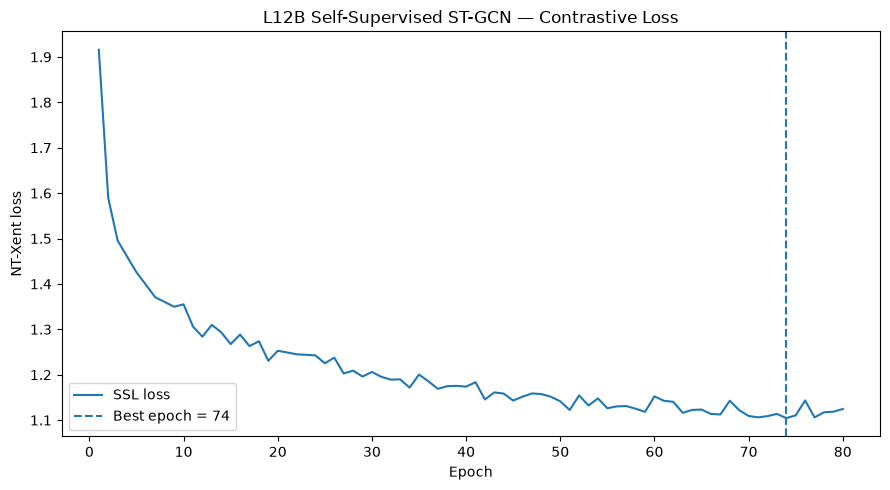


SSL -> SUPERVISED TRANSFER
Loaded SSL epoch : 74
SSL loss         : 1.104496145132676
Missing keys     : []
Unexpected keys  : []
[PASS] SSL encoder transferred exactly.

STGCNClassifier(
  (encoder): STGCNEncoder(
    (input_bn): BatchNorm1d(462, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (block1): STGCNBlock(
      (gcn): GraphConv(
        (conv): Conv2d(11, 192, kernel_size=(1, 1), stride=(1, 1), bias=False)
      )
      (gcn_bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (temporal): Sequential(
        (0): ReLU(inplace=True)
        (1): Conv2d(64, 64, kernel_size=(9, 1), stride=(1, 1), padding=(4, 0), bias=False)
        (2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (3): Dropout(p=0.175, inplace=False)
      )
      (residual): Sequential(
        (0): Conv2d(11, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): Batc

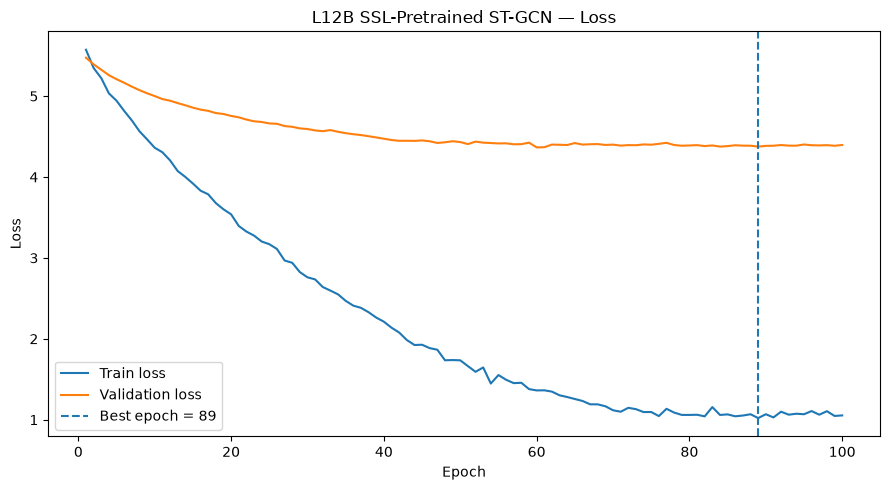

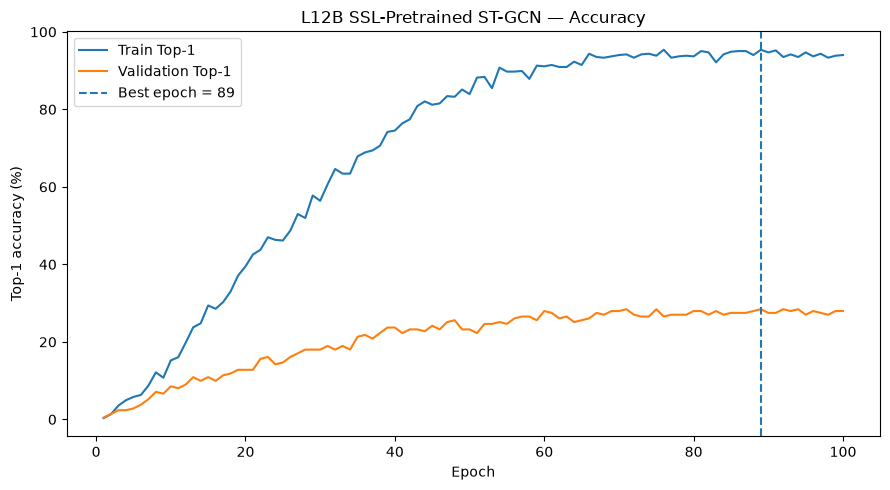


VALIDATION COMPARISON

experiment                 model  val_top1_percent  val_top5_percent
     L10.0                   GRU          7.109005         13.744076
     L11.0                BiLSTM          8.530806         17.535545
     L10.2          Enhanced GRU          3.791469          6.635071
      L12A   ST-GCN from scratch         18.009479         27.962085
      L12B SSL-pretrained ST-GCN         28.436019         37.914692

L12B vs L12A

L12A ST-GCN Top-1         : 18.01%
L12B SSL ST-GCN Top-1     : 28.44%
Top-1 delta               : +10.43 pp

L12A ST-GCN Top-5         : 27.96%
L12B SSL ST-GCN Top-5     : 37.91%
Top-5 delta               : +9.95 pp

GENERALIZATION DIAGNOSTIC

Train Top-1 @ selected epoch : 95.38%
Validation Top-1              : 28.44%
Top-1 generalization gap      : 66.95 pp

L12B FINAL REPORT

SELF-SUPERVISED PRETRAINING
----------------------------------------------------------------------------------------------------------------------------------
Availa

In [6]:
# ==================================================================================================
# CISLR LANDMARK MODEL — L12B
# LEAKAGE-SAFE SELF-SUPERVISED ST-GCN PRETRAINING + FROZEN-L9 FINE-TUNING
# ==================================================================================================
#
# PURPOSE
# -------
# L12A showed that explicit hand-skeleton topology substantially improves recognition:
#
#   L10 GRU       :  7.11% Top-1
#   L11 BiLSTM    :  8.53% Top-1
#   L10.2 GRU     :  3.79% Top-1
#   L12A ST-GCN   : 18.01% Top-1
#
# L12B asks:
#
#   Can a skeleton encoder learn a better representation from the much larger
#   unlabeled CISLR skeleton corpus BEFORE supervised training on the 211-class task?
#
# CRITICAL LEAKAGE RULE
# ---------------------
# L9 validation and L9 test videos are EXCLUDED from self-supervised pretraining.
#
# PRETRAIN:
#   L6 raw sequences
#       - L9 validation UIDs
#       - L9 test UIDs
#       -> two augmented skeleton views
#       -> shared ST-GCN encoder
#       -> NT-Xent contrastive loss
#
# FINE-TUNE:
#   ONLY frozen L9 train = 585
#
# MODEL SELECTION:
#   ONLY frozen L9 validation = 211
#
# TEST:
#   Manifest may be verified.
#   Raw test sequences are NEVER loaded.
#   Test is NEVER evaluated here.
#
# ==================================================================================================

import os
import json
import math
import time
import random
import hashlib
from pathlib import Path
from copy import deepcopy

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt


# ==================================================================================================
# 0. CONFIGURATION
# ==================================================================================================

SEED = 42

PROJECT_ROOT = Path("/home/dipshikha/Music/cao/CISLR_RESEARCH")
MODEL_ROOT = PROJECT_ROOT / "CISLR_LANDMARK_MODEL"

RAW_DIR = (
    MODEL_ROOT
    / "audit"
    / "l6_full_extraction"
    / "raw_sequences"
)

L9_ROOT = (
    MODEL_ROOT
    / "audit"
    / "l9_split_freeze"
)

TRAIN_MANIFEST = L9_ROOT / "splits" / "l9_train_manifest.csv"
VAL_MANIFEST   = L9_ROOT / "splits" / "l9_validation_manifest.csv"
TEST_MANIFEST  = L9_ROOT / "splits" / "l9_test_manifest.csv"

CLASS_MAPPING_PATH = (
    L9_ROOT
    / "class_mapping"
    / "l9_controlled_class_mapping.json"
)

L12A_ROOT = (
    MODEL_ROOT
    / "audit"
    / "l12_stgcn"
)

L12A_SUMMARY = L12A_ROOT / "reports" / "l12_summary.json"

# ----------------------------------------------------------------------------------
# L12B output
# ----------------------------------------------------------------------------------

L12B_ROOT = (
    MODEL_ROOT
    / "audit"
    / "l12b_ssl_stgcn"
)

MODEL_DIR = L12B_ROOT / "models"
REPORT_DIR = L12B_ROOT / "reports"
PLOT_DIR = L12B_ROOT / "plots"
PREPROCESS_DIR = L12B_ROOT / "preprocessing"

for d in [
    L12B_ROOT,
    MODEL_DIR,
    REPORT_DIR,
    PLOT_DIR,
    PREPROCESS_DIR
]:
    d.mkdir(parents=True, exist_ok=True)


# ----------------------------------------------------------------------------------
# Sequence / graph configuration
# ----------------------------------------------------------------------------------

SEQ_LEN = 32
NUM_HANDS = 2
JOINTS_PER_HAND = 21
NUM_NODES = 42

# 11 channels:
#
# 0:3   world XYZ
# 3:6   world velocity XYZ
# 6:8   global image XY
# 8:10  global image velocity XY
# 10    presence mask
#
INPUT_CHANNELS = 11

NUM_CLASSES = 211


# ----------------------------------------------------------------------------------
# SSL configuration
# ----------------------------------------------------------------------------------

SSL_BATCH_SIZE = 64
SSL_EPOCHS = 80

SSL_LR = 5e-4
SSL_WEIGHT_DECAY = 5e-4

TEMPERATURE = 0.20

PROJECTION_DIM = 128

SSL_PATIENCE = 15


# ----------------------------------------------------------------------------------
# Fine-tuning configuration
# ----------------------------------------------------------------------------------

FT_BATCH_SIZE = 32
FT_EPOCHS = 100

FT_LR = 3e-4
FT_WEIGHT_DECAY = 5e-4

FT_PATIENCE = 18

LABEL_SMOOTHING = 0.05

DROPOUT = 0.35


# ==================================================================================================
# 1. REPRODUCIBILITY
# ==================================================================================================

def seed_everything(seed=42):

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed_everything(SEED)


# ==================================================================================================
# 2. DEVICE
# ==================================================================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("=" * 130)
print("CISLR LANDMARK MODEL — L12B")
print("SELF-SUPERVISED ST-GCN PRETRAINING + FROZEN-L9 FINE-TUNING")
print("=" * 130)

print()
print("PyTorch version :", torch.__version__)
print("Device          :", device)

if torch.cuda.is_available():
    print("GPU             :", torch.cuda.get_device_name(0))


# ==================================================================================================
# 3. REQUIRED FILE CHECK
# ==================================================================================================

required_paths = [
    RAW_DIR,
    TRAIN_MANIFEST,
    VAL_MANIFEST,
    TEST_MANIFEST,
    CLASS_MAPPING_PATH,
]

for p in required_paths:
    if not p.exists():
        raise FileNotFoundError(f"Missing required path:\n{p}")

raw_files = sorted(RAW_DIR.glob("*.npz"))

print()
print("Raw L6 sequence files :", len(raw_files))

if len(raw_files) == 0:
    raise RuntimeError("No raw L6 NPZ files found.")

print("[PASS] Required files exist.")


# ==================================================================================================
# 4. LOAD FROZEN L9 MANIFESTS
# ==================================================================================================

train_df = pd.read_csv(TRAIN_MANIFEST)
val_df   = pd.read_csv(VAL_MANIFEST)
test_df  = pd.read_csv(TEST_MANIFEST)

for name, df in [
    ("train", train_df),
    ("validation", val_df),
    ("test", test_df),
]:
    if "uid" not in df.columns:
        raise RuntimeError(
            f"{name} manifest does not contain UID column."
        )

train_df["uid"] = train_df["uid"].astype(str)
val_df["uid"]   = val_df["uid"].astype(str)
test_df["uid"]  = test_df["uid"].astype(str)

train_uids = set(train_df["uid"])
val_uids   = set(val_df["uid"])
test_uids  = set(test_df["uid"])


# ----------------------------------------------------------------------------------
# Verify frozen counts
# ----------------------------------------------------------------------------------

assert len(train_df) == 585
assert len(val_df) == 211
assert len(test_df) == 211

assert len(train_uids & val_uids) == 0
assert len(train_uids & test_uids) == 0
assert len(val_uids & test_uids) == 0


print()
print("=" * 130)
print("FROZEN L9 SPLIT")
print("=" * 130)

print("Train      :", len(train_df))
print("Validation :", len(val_df))
print("Test       :", len(test_df), "(LOCKED)")
print("[PASS] Zero UID overlap.")


# ==================================================================================================
# 5. CLASS MAPPING
# ==================================================================================================

with open(CLASS_MAPPING_PATH, "r") as f:
    mapping_obj = json.load(f)


# Mapping file can be stored in several equivalent forms.
if isinstance(mapping_obj, dict):

    if "gloss_to_id" in mapping_obj:
        gloss_to_id = {
            str(k): int(v)
            for k, v in mapping_obj["gloss_to_id"].items()
        }

    elif "class_to_idx" in mapping_obj:
        gloss_to_id = {
            str(k): int(v)
            for k, v in mapping_obj["class_to_idx"].items()
        }

    else:
        # direct mapping
        try:
            gloss_to_id = {
                str(k): int(v)
                for k, v in mapping_obj.items()
            }
        except Exception:
            gloss_to_id = None

else:
    gloss_to_id = None


# If mapping JSON structure is unusual, reconstruct from manifest class IDs.
if gloss_to_id is None:

    possible_label_cols = [
        "class_id",
        "label",
        "class_index",
        "target"
    ]

    label_col = None

    for c in possible_label_cols:
        if c in train_df.columns:
            label_col = c
            break

    if label_col is None:
        raise RuntimeError(
            "Could not understand class mapping JSON and no class-ID "
            "column exists in L9 train manifest."
        )

    if "gloss" not in train_df.columns:
        raise RuntimeError("Train manifest missing gloss.")

    gloss_to_id = dict(
        zip(
            train_df["gloss"].astype(str),
            train_df[label_col].astype(int)
        )
    )


if len(gloss_to_id) != NUM_CLASSES:
    raise RuntimeError(
        f"Expected {NUM_CLASSES} controlled classes, "
        f"found {len(gloss_to_id)}."
    )


id_to_gloss = {
    int(v): str(k)
    for k, v in gloss_to_id.items()
}


print("[PASS] 211-class mapping verified.")


# ==================================================================================================
# 6. HAND GRAPH
# ==================================================================================================

# MediaPipe-style 21-landmark hand topology
HAND_EDGES = [
    (0, 1), (1, 2), (2, 3), (3, 4),

    (0, 5), (5, 6), (6, 7), (7, 8),

    (5, 9), (9, 10), (10, 11), (11, 12),

    (9, 13), (13, 14), (14, 15), (15, 16),

    (13, 17), (17, 18), (18, 19), (19, 20),

    (0, 17),
]


def normalize_adjacency(A):

    A = A.astype(np.float32)

    degree = A.sum(axis=0)

    degree[degree < 1e-6] = 1.0

    return A / degree[None, :]


def build_graph():

    # ----------------------------------------------------------
    # A0 = self
    # A1 = inward
    # A2 = outward
    # ----------------------------------------------------------

    A_self = np.eye(NUM_NODES, dtype=np.float32)

    A_in = np.zeros(
        (NUM_NODES, NUM_NODES),
        dtype=np.float32
    )

    A_out = np.zeros_like(A_in)

    for hand in range(2):

        offset = hand * JOINTS_PER_HAND

        for parent, child in HAND_EDGES:

            p = parent + offset
            c = child + offset

            # Matrix convention:
            # output[v] = sum_w input[w] * A[w,v]

            A_in[c, p] = 1.0
            A_out[p, c] = 1.0

    A_self = normalize_adjacency(A_self)
    A_in   = normalize_adjacency(A_in)
    A_out  = normalize_adjacency(A_out)

    return np.stack(
        [A_self, A_in, A_out],
        axis=0
    )


A = build_graph()

assert A.shape == (3, 42, 42)


print()
print("=" * 130)
print("GRAPH")
print("=" * 130)

print("Nodes              :", NUM_NODES)
print("Hand components    :", 2)
print("Partitions         :", A.shape[0])
print("Adjacency shape    :", A.shape)
print("Inter-hand edge    : NO")


# ==================================================================================================
# 7. TEMPORAL UTILITIES
# ==================================================================================================

def uniform_indices(length, target_length=32):

    if length <= 0:
        return np.zeros(
            target_length,
            dtype=np.int64
        )

    idx = np.linspace(
        0,
        length - 1,
        target_length
    )

    idx = np.round(idx).astype(np.int64)

    return np.clip(
        idx,
        0,
        length - 1
    )


def interpolate_short_gaps(
    data,
    mask,
    max_gap=3
):

    """
    data:
        [T,H,J,C]

    mask:
        [T,H]

    Only fills INTERNAL short gaps.
    No extrapolation.
    """

    data = data.copy()
    mask = mask.copy().astype(np.uint8)

    T, H = mask.shape

    for h in range(H):

        valid = np.where(mask[:, h] > 0)[0]

        if len(valid) < 2:
            continue

        for a, b in zip(valid[:-1], valid[1:]):

            gap = b - a - 1

            if gap <= 0 or gap > max_gap:
                continue

            for k in range(1, gap + 1):

                alpha = k / (gap + 1)

                data[a + k, h] = (
                    (1.0 - alpha) * data[a, h]
                    +
                    alpha * data[b, h]
                )

                mask[a + k, h] = 1

    return data, mask


# ==================================================================================================
# 8. RAW NPZ -> 42-NODE GRAPH
# ==================================================================================================

def raw_to_graph(npz_path):

    with np.load(npz_path, allow_pickle=True) as d:

        uid = str(d["uid"].item())

        landmarks_px = d["landmarks_px"].astype(
            np.float32
        )

        world = d["world_landmarks"].astype(
            np.float32
        )

        hand_mask = d["hand_mask"].astype(
            np.uint8
        )

        width = float(d["width"].item())
        height = float(d["height"].item())


    # Expected:
    # [T,2,21,3]
    if landmarks_px.ndim != 4:
        raise ValueError(
            f"Bad landmarks shape: {landmarks_px.shape}"
        )

    if world.shape != landmarks_px.shape:
        raise ValueError(
            f"World/image shape mismatch for {uid}"
        )

    T = landmarks_px.shape[0]

    if hand_mask.shape != (T, 2):
        raise ValueError(
            f"Bad hand mask shape for {uid}: {hand_mask.shape}"
        )


    # ----------------------------------------------------------------------------------
    # Repair ONLY short missing intervals
    # ----------------------------------------------------------------------------------

    world, repaired_mask = interpolate_short_gaps(
        world,
        hand_mask,
        max_gap=3
    )

    image = landmarks_px.copy()

    image, _ = interpolate_short_gaps(
        image,
        hand_mask,
        max_gap=3
    )


    # ----------------------------------------------------------------------------------
    # WORLD XYZ
    #
    # World landmarks are already metric-ish hand coordinates from the hand model.
    # Center each visible hand at its wrist.
    # Scale using average wrist -> MCP distance.
    # ----------------------------------------------------------------------------------

    world_norm = np.zeros_like(
        world,
        dtype=np.float32
    )

    MCP = [5, 9, 13, 17]

    for t in range(T):

        for h in range(2):

            if repaired_mask[t, h] == 0:
                continue

            pts = world[t, h].copy()

            wrist = pts[0].copy()

            centered = pts - wrist

            scale = np.mean(
                np.linalg.norm(
                    centered[MCP],
                    axis=1
                )
            )

            if not np.isfinite(scale) or scale < 1e-5:
                scale = 1.0

            world_norm[t, h] = centered / scale


    # ----------------------------------------------------------------------------------
    # GLOBAL IMAGE XY
    #
    # Preserve where the hand/joints are in the original image.
    #
    # x normalized by width
    # y normalized by height
    #
    # Then centered around image center:
    # approximately [-0.5,+0.5]
    # ----------------------------------------------------------------------------------

    image_xy = np.zeros(
        (T, 2, 21, 2),
        dtype=np.float32
    )

    for t in range(T):

        for h in range(2):

            if repaired_mask[t, h] == 0:
                continue

            image_xy[t, h, :, 0] = (
                image[t, h, :, 0] / max(width, 1.0)
                - 0.5
            )

            image_xy[t, h, :, 1] = (
                image[t, h, :, 1] / max(height, 1.0)
                - 0.5
            )


    # ----------------------------------------------------------------------------------
    # VELOCITIES
    # ----------------------------------------------------------------------------------

    world_vel = np.zeros_like(
        world_norm,
        dtype=np.float32
    )

    image_vel = np.zeros_like(
        image_xy,
        dtype=np.float32
    )

    for t in range(1, T):

        for h in range(2):

            if (
                repaired_mask[t, h] > 0
                and repaired_mask[t - 1, h] > 0
            ):

                world_vel[t, h] = (
                    world_norm[t, h]
                    -
                    world_norm[t - 1, h]
                )

                image_vel[t, h] = (
                    image_xy[t, h]
                    -
                    image_xy[t - 1, h]
                )


    # ----------------------------------------------------------------------------------
    # Uniform temporal sampling -> 32
    # ----------------------------------------------------------------------------------

    idx = uniform_indices(
        T,
        SEQ_LEN
    )

    world_norm = world_norm[idx]
    world_vel  = world_vel[idx]

    image_xy   = image_xy[idx]
    image_vel  = image_vel[idx]

    sampled_mask = repaired_mask[idx]


    # ----------------------------------------------------------------------------------
    # [32,2,21,*] -> [32,42,*]
    # ----------------------------------------------------------------------------------

    world_norm = world_norm.reshape(
        SEQ_LEN,
        NUM_NODES,
        3
    )

    world_vel = world_vel.reshape(
        SEQ_LEN,
        NUM_NODES,
        3
    )

    image_xy = image_xy.reshape(
        SEQ_LEN,
        NUM_NODES,
        2
    )

    image_vel = image_vel.reshape(
        SEQ_LEN,
        NUM_NODES,
        2
    )


    node_mask = np.repeat(
        sampled_mask[:, :, None],
        JOINTS_PER_HAND,
        axis=2
    ).reshape(
        SEQ_LEN,
        NUM_NODES
    ).astype(np.float32)


    # ----------------------------------------------------------------------------------
    # Enforce missing nodes = 0
    # ----------------------------------------------------------------------------------

    m = node_mask[..., None]

    world_norm *= m
    world_vel  *= m
    image_xy   *= m
    image_vel  *= m


    # ----------------------------------------------------------------------------------
    # Concatenate:
    #
    # world XYZ       3
    # world velocity  3
    # image XY        2
    # image velocity  2
    # mask            1
    #
    # total           11
    # ----------------------------------------------------------------------------------

    graph = np.concatenate(
        [
            world_norm,
            world_vel,
            image_xy,
            image_vel,
            node_mask[..., None]
        ],
        axis=-1
    )


    # [T,V,C] -> [C,T,V]

    graph = np.transpose(
        graph,
        (2, 0, 1)
    ).astype(np.float32)


    if graph.shape != (
        INPUT_CHANNELS,
        SEQ_LEN,
        NUM_NODES
    ):
        raise RuntimeError(
            f"Bad graph shape for {uid}: {graph.shape}"
        )


    if not np.isfinite(graph).all():
        raise RuntimeError(
            f"NaN/Inf in graph for {uid}"
        )


    return graph, node_mask, uid


# ==================================================================================================
# 9. MAP UID -> RAW FILE
# ==================================================================================================

uid_to_raw = {}

print()
print("Indexing raw sequences...")

for i, path in enumerate(raw_files, start=1):

    try:

        with np.load(path, allow_pickle=True) as d:
            uid = str(d["uid"].item())

        uid_to_raw[uid] = path

    except Exception as e:

        print(
            "[WARNING] Could not index:",
            path.name,
            e
        )

    if i % 1000 == 0:
        print(f"  {i}/{len(raw_files)}")


print("Indexed raw UIDs :", len(uid_to_raw))


# ==================================================================================================
# 10. VERIFY ALL FROZEN L9 UIDS
# ==================================================================================================

for split_name, uid_set in [
    ("TRAIN", train_uids),
    ("VALIDATION", val_uids),
    ("TEST", test_uids),
]:

    missing = sorted(
        uid_set - set(uid_to_raw)
    )

    if missing:

        raise RuntimeError(
            f"{split_name}: missing raw sequences: "
            f"{missing[:10]}"
        )


print("[PASS] All frozen L9 UIDs have raw sequences.")


# ==================================================================================================
# 11. BUILD LEAKAGE-SAFE SSL PRETRAINING POOL
# ==================================================================================================

# ----------------------------------------------------------------------------------
# VERY IMPORTANT:
#
# Validation and test UIDs are excluded.
#
# L9 TRAIN videos ARE allowed because they are legitimate training data.
#
# Other CISLR videos are used WITHOUT their labels.
# ----------------------------------------------------------------------------------

forbidden_ssl_uids = val_uids | test_uids

ssl_paths = []

ssl_rejected = []

print()
print("=" * 130)
print("BUILDING LEAKAGE-SAFE SSL CORPUS")
print("=" * 130)

print("Total raw files             :", len(raw_files))
print("L9 validation excluded      :", len(val_uids))
print("L9 test excluded            :", len(test_uids))


for i, path in enumerate(raw_files, start=1):

    try:

        with np.load(path, allow_pickle=True) as d:

            uid = str(d["uid"].item())

            mask = d["hand_mask"].astype(
                np.uint8
            )

        if uid in forbidden_ssl_uids:
            continue

        # Require at least a small amount of actual hand evidence.
        any_hand_frames = int(
            np.sum(
                np.any(mask > 0, axis=1)
            )
        )

        if any_hand_frames < 8:

            ssl_rejected.append(
                {
                    "uid": uid,
                    "reason": "fewer_than_8_detected_frames"
                }
            )

            continue

        ssl_paths.append(path)

    except Exception as e:

        ssl_rejected.append(
            {
                "uid": path.stem,
                "reason": str(e)
            }
        )

    if i % 1000 == 0:
        print(f"  scanned {i}/{len(raw_files)}")


ssl_uids = set()

for path in ssl_paths:

    with np.load(path, allow_pickle=True) as d:
        ssl_uids.add(str(d["uid"].item()))


# ABSOLUTE LEAKAGE CHECK

assert len(ssl_uids & val_uids) == 0
assert len(ssl_uids & test_uids) == 0


print()
print("SSL usable sequences        :", len(ssl_paths))
print("SSL rejected low-quality    :", len(ssl_rejected))

print(
    "L9 train represented in SSL:",
    len(ssl_uids & train_uids),
    "/",
    len(train_uids)
)

print(
    "Validation leakage          :",
    len(ssl_uids & val_uids)
)

print(
    "Test leakage                :",
    len(ssl_uids & test_uids)
)

print("[PASS] Validation/test completely excluded from SSL.")


pd.DataFrame(
    {
        "raw_path": [
            str(x)
            for x in ssl_paths
        ]
    }
).to_csv(
    REPORT_DIR / "l12b_ssl_pretraining_files.csv",
    index=False
)

pd.DataFrame(
    ssl_rejected
).to_csv(
    REPORT_DIR / "l12b_ssl_rejected.csv",
    index=False
)


# ==================================================================================================
# 12. LOAD SUPERVISED TRAIN + VALIDATION GRAPHS
# ==================================================================================================

def get_label_from_row(row):

    # Preferred: use frozen gloss mapping

    if "gloss" in row.index:

        gloss = str(row["gloss"])

        if gloss in gloss_to_id:
            return gloss_to_id[gloss]

    # fallback
    for c in [
        "class_id",
        "label",
        "class_index",
        "target"
    ]:

        if c in row.index:
            return int(row[c])

    raise RuntimeError(
        "Could not determine label from manifest row."
    )


def load_supervised_split(df, name):

    graphs = []
    labels = []
    uids = []

    print()
    print(f"Building {name} graph representation...")

    start = time.time()

    for i, (_, row) in enumerate(
        df.iterrows(),
        start=1
    ):

        uid = str(row["uid"])

        graph, node_mask, loaded_uid = raw_to_graph(
            uid_to_raw[uid]
        )

        if loaded_uid != uid:
            raise RuntimeError(
                f"UID mismatch: {uid} vs {loaded_uid}"
            )

        label = get_label_from_row(row)

        graphs.append(graph)
        labels.append(label)
        uids.append(uid)

        if (
            i % 100 == 0
            or i == len(df)
        ):
            print(f"  {i}/{len(df)}")


    graphs = np.stack(graphs).astype(
        np.float32
    )

    labels = np.asarray(
        labels,
        dtype=np.int64
    )

    elapsed = time.time() - start

    print(
        f"[DONE] {name}: {elapsed:.2f} sec"
    )

    return graphs, labels, uids


X_train, y_train, train_uid_order = load_supervised_split(
    train_df,
    "TRAIN"
)

X_val, y_val, val_uid_order = load_supervised_split(
    val_df,
    "VALIDATION"
)


assert X_train.shape == (
    585,
    11,
    32,
    42
)

assert X_val.shape == (
    211,
    11,
    32,
    42
)


print()
print("Train graph shape :", X_train.shape)
print("Val graph shape   :", X_val.shape)

print("[PASS] Supervised graph representation built.")

print()
print("TEST RAW SEQUENCES HAVE NOT BEEN LOADED.")


# ==================================================================================================
# 13. TRAIN-ONLY MASK-AWARE NORMALIZATION
# ==================================================================================================

# Continuous channels only:
# 0..9
#
# channel 10 = mask

CONT_CHANNELS = 10


def compute_mask_aware_stats(X):

    sums = np.zeros(
        CONT_CHANNELS,
        dtype=np.float64
    )

    sqs = np.zeros(
        CONT_CHANNELS,
        dtype=np.float64
    )

    counts = np.zeros(
        CONT_CHANNELS,
        dtype=np.float64
    )

    for sample in X:

        mask = sample[10] > 0.5

        for c in range(CONT_CHANNELS):

            values = sample[c][mask]

            if len(values) == 0:
                continue

            sums[c] += values.sum(
                dtype=np.float64
            )

            sqs[c] += np.square(
                values.astype(np.float64)
            ).sum()

            counts[c] += len(values)


    means = sums / np.maximum(
        counts,
        1
    )

    var = (
        sqs / np.maximum(counts, 1)
        -
        means ** 2
    )

    var = np.maximum(
        var,
        1e-8
    )

    stds = np.sqrt(var)

    return (
        means.astype(np.float32),
        stds.astype(np.float32)
    )


channel_mean, channel_std = compute_mask_aware_stats(
    X_train
)


np.save(
    PREPROCESS_DIR / "l12b_channel_mean.npy",
    channel_mean
)

np.save(
    PREPROCESS_DIR / "l12b_channel_std.npy",
    channel_std
)


def normalize_graph(X):

    X = X.copy()

    mask = X[:, 10:11]

    for c in range(CONT_CHANNELS):

        X[:, c:c+1] = (
            X[:, c:c+1]
            -
            channel_mean[c]
        ) / channel_std[c]

        # preserve missing nodes = 0
        X[:, c:c+1] *= mask

    X[:, 10:11] = mask

    return X.astype(np.float32)


X_train = normalize_graph(X_train)
X_val   = normalize_graph(X_val)


print()
print("=" * 130)
print("TRAIN-ONLY MASK-AWARE NORMALIZATION")
print("=" * 130)

print("Channel mean:")
print(
    np.round(
        channel_mean,
        6
    )
)

print()
print("Channel std:")
print(
    np.round(
        channel_std,
        6
    )
)

# verify missing nodes remain zero

train_missing = X_train[:, 10] < 0.5

for c in range(10):

    if not np.allclose(
        X_train[:, c][train_missing],
        0.0
    ):
        raise RuntimeError(
            "Missing nodes became non-zero."
        )

print()
print("[PASS] Missing nodes remain zero.")


# ==================================================================================================
# 14. SSL AUGMENTATIONS
# ==================================================================================================

def temporal_crop_and_resize(x):

    """
    x = [C,T,V]

    Random temporal crop then interpolation back to T=32.
    """

    C, T, V = x.shape

    ratio = np.random.uniform(
        0.70,
        1.00
    )

    crop_len = max(
        16,
        int(round(T * ratio))
    )

    if crop_len >= T:
        return x.copy()

    start = np.random.randint(
        0,
        T - crop_len + 1
    )

    crop = x[
        :,
        start:start + crop_len,
        :
    ]

    tensor = torch.from_numpy(
        crop
    ).float().unsqueeze(0)

    resized = F.interpolate(
        tensor,
        size=(T, V),
        mode="bilinear",
        align_corners=False
    )

    return (
        resized.squeeze(0)
        .numpy()
        .astype(np.float32)
    )


def augment_graph(x):

    """
    Skeleton-safe SSL augmentation.

    NO left/right swapping.
    NO joint permutation.
    NO graph topology change.
    """

    x = x.copy()

    # ------------------------------------------------------------------
    # Temporal crop
    # ------------------------------------------------------------------

    if np.random.rand() < 0.70:
        x = temporal_crop_and_resize(x)


    # ------------------------------------------------------------------
    # Original presence mask
    # ------------------------------------------------------------------

    mask = (
        x[10:11] > 0.5
    ).astype(np.float32)


    # ------------------------------------------------------------------
    # Mild coordinate noise
    # ------------------------------------------------------------------

    if np.random.rand() < 0.80:

        noise = np.random.normal(
            0.0,
            0.015,
            size=x[:10].shape
        ).astype(np.float32)

        x[:10] += noise * mask


    # ------------------------------------------------------------------
    # Mild global scale jitter
    #
    # Apply to coordinate/motion channels only.
    # ------------------------------------------------------------------

    if np.random.rand() < 0.70:

        scale = np.random.uniform(
            0.90,
            1.10
        )

        x[0:10] *= scale


    # ------------------------------------------------------------------
    # Temporal frame masking
    # ------------------------------------------------------------------

    if np.random.rand() < 0.60:

        n_mask = np.random.randint(
            1,
            5
        )

        frames = np.random.choice(
            SEQ_LEN,
            size=n_mask,
            replace=False
        )

        x[:10, frames, :] = 0.0
        x[10, frames, :] = 0.0


    # ------------------------------------------------------------------
    # Random short contiguous temporal occlusion
    # ------------------------------------------------------------------

    if np.random.rand() < 0.40:

        length = np.random.randint(
            2,
            6
        )

        start = np.random.randint(
            0,
            SEQ_LEN - length + 1
        )

        x[
            :,
            start:start + length,
            :
        ] = 0.0


    # ------------------------------------------------------------------
    # Random hand dropout
    #
    # Small probability only.
    # Forces encoder not to collapse when one hand is temporarily absent.
    # ------------------------------------------------------------------

    if np.random.rand() < 0.15:

        hand = np.random.randint(0, 2)

        s = hand * 21
        e = s + 21

        x[:, :, s:e] = 0.0


    # ------------------------------------------------------------------
    # Keep missing nodes zero
    # ------------------------------------------------------------------

    mask = (
        x[10:11] > 0.5
    ).astype(np.float32)

    x[:10] *= mask

    x[10:11] = mask

    return x.astype(np.float32)


# ==================================================================================================
# 15. SSL DATASET
# ==================================================================================================

class SSLDataset(Dataset):

    def __init__(
        self,
        paths,
        mean,
        std
    ):

        self.paths = list(paths)
        self.mean = mean
        self.std = std


    def __len__(self):
        return len(self.paths)


    def normalize_single(self, x):

        x = x.copy()

        mask = x[10:11].copy()

        for c in range(10):

            x[c:c+1] = (
                x[c:c+1]
                -
                self.mean[c]
            ) / self.std[c]

            x[c:c+1] *= mask

        x[10:11] = mask

        return x.astype(np.float32)


    def __getitem__(self, idx):

        path = self.paths[idx]

        graph, _, uid = raw_to_graph(
            path
        )

        graph = self.normalize_single(
            graph
        )

        view1 = augment_graph(graph)
        view2 = augment_graph(graph)

        return (
            torch.from_numpy(view1),
            torch.from_numpy(view2)
        )


ssl_dataset = SSLDataset(
    ssl_paths,
    channel_mean,
    channel_std
)


ssl_loader = DataLoader(
    ssl_dataset,
    batch_size=SSL_BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
    drop_last=True
)


print()
print("SSL dataset size :", len(ssl_dataset))
print("SSL batches      :", len(ssl_loader))


# ==================================================================================================
# 16. GRAPH CONVOLUTION
# ==================================================================================================

class GraphConv(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels,
        num_partitions=3
    ):

        super().__init__()

        self.num_partitions = num_partitions
        self.out_channels = out_channels

        self.conv = nn.Conv2d(
            in_channels,
            out_channels * num_partitions,
            kernel_size=1,
            bias=False
        )


    def forward(self, x, A):

        # x:
        # [N,C,T,V]

        x = self.conv(x)

        N, KC, T, V = x.shape

        x = x.view(
            N,
            self.num_partitions,
            self.out_channels,
            T,
            V
        )

        # graph aggregation

        x = torch.einsum(
            "nkctv,kvw->nctw",
            x,
            A
        )

        return x.contiguous()


# ==================================================================================================
# 17. ST-GCN BLOCK
# ==================================================================================================

class STGCNBlock(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels,
        dropout=0.35
    ):

        super().__init__()

        self.gcn = GraphConv(
            in_channels,
            out_channels,
            num_partitions=3
        )

        self.gcn_bn = nn.BatchNorm2d(
            out_channels
        )

        self.temporal = nn.Sequential(

            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=(9, 1),
                padding=(4, 0),
                bias=False
            ),

            nn.BatchNorm2d(
                out_channels
            ),

            nn.Dropout(
                dropout
            )
        )


        if in_channels == out_channels:

            self.residual = nn.Identity()

        else:

            self.residual = nn.Sequential(

                nn.Conv2d(
                    in_channels,
                    out_channels,
                    kernel_size=1,
                    bias=False
                ),

                nn.BatchNorm2d(
                    out_channels
                )
            )


        self.relu = nn.ReLU(
            inplace=True
        )


    def forward(self, x, A):

        residual = self.residual(x)

        x = self.gcn(
            x,
            A
        )

        x = self.gcn_bn(x)

        x = self.temporal(x)

        x = x + residual

        return self.relu(x)


# ==================================================================================================
# 18. ST-GCN ENCODER
# ==================================================================================================

class STGCNEncoder(nn.Module):

    def __init__(
        self,
        in_channels=11,
        dropout=0.35
    ):

        super().__init__()

        self.input_bn = nn.BatchNorm1d(
            in_channels * NUM_NODES
        )

        self.block1 = STGCNBlock(
            in_channels,
            64,
            dropout=dropout * 0.5
        )

        self.block2 = STGCNBlock(
            64,
            64,
            dropout=dropout
        )

        self.block3 = STGCNBlock(
            64,
            128,
            dropout=dropout
        )

        self.block4 = STGCNBlock(
            128,
            128,
            dropout=dropout
        )

        self.output_norm = nn.LayerNorm(
            128
        )


    def forward(self, x, A):

        # --------------------------------------------------------------
        # Input BN
        #
        # [N,C,T,V]
        # -> [N,V,C,T]
        # -> [N,V*C,T]
        # --------------------------------------------------------------

        N, C, T, V = x.shape

        y = x.permute(
            0,
            3,
            1,
            2
        ).contiguous()

        y = y.view(
            N,
            V * C,
            T
        )

        y = self.input_bn(y)

        y = y.view(
            N,
            V,
            C,
            T
        )

        x = y.permute(
            0,
            2,
            3,
            1
        ).contiguous()


        x = self.block1(x, A)
        x = self.block2(x, A)
        x = self.block3(x, A)
        x = self.block4(x, A)


        # --------------------------------------------------------------
        # Mask-aware global pooling
        #
        # original input channel 10 = presence
        # --------------------------------------------------------------

        mask = (
            y.view(N, V, C, T)
            [:, :, 10, :]
        )

        mask = mask.permute(
            0,
            2,
            1
        ).unsqueeze(1)

        mask = (
            mask > 0.5
        ).float()


        weighted = x * mask

        denom = mask.sum(
            dim=(2, 3)
        ).clamp(min=1.0)

        pooled = weighted.sum(
            dim=(2, 3)
        ) / denom

        pooled = self.output_norm(
            pooled
        )

        return pooled


# ==================================================================================================
# 19. SSL MODEL
# ==================================================================================================

class ContrastiveSTGCN(nn.Module):

    def __init__(self):

        super().__init__()

        self.encoder = STGCNEncoder(
            in_channels=INPUT_CHANNELS,
            dropout=DROPOUT
        )

        self.projector = nn.Sequential(

            nn.Linear(
                128,
                256
            ),

            nn.ReLU(inplace=True),

            nn.Linear(
                256,
                PROJECTION_DIM
            )
        )


    def forward(self, x, A):

        h = self.encoder(
            x,
            A
        )

        z = self.projector(h)

        z = F.normalize(
            z,
            dim=1
        )

        return z


A_tensor = torch.tensor(
    A,
    dtype=torch.float32,
    device=device
)


ssl_model = ContrastiveSTGCN().to(
    device
)


# ==================================================================================================
# 20. NT-XENT LOSS
# ==================================================================================================

def nt_xent_loss(
    z1,
    z2,
    temperature=0.20
):

    batch_size = z1.size(0)

    z = torch.cat(
        [z1, z2],
        dim=0
    )

    z = F.normalize(
        z,
        dim=1
    )

    similarity = torch.matmul(
        z,
        z.T
    ) / temperature


    # Remove self similarity

    eye = torch.eye(
        2 * batch_size,
        device=z.device,
        dtype=torch.bool
    )

    similarity = similarity.masked_fill(
        eye,
        -1e9
    )


    # Positive pair:
    #
    # i -> i+B
    # i+B -> i

    targets = torch.arange(
        2 * batch_size,
        device=z.device
    )

    targets = (
        targets + batch_size
    ) % (
        2 * batch_size
    )


    loss = F.cross_entropy(
        similarity,
        targets
    )

    return loss


# ==================================================================================================
# 21. SSL PRETRAINING
# ==================================================================================================

ssl_optimizer = torch.optim.AdamW(
    ssl_model.parameters(),
    lr=SSL_LR,
    weight_decay=SSL_WEIGHT_DECAY
)

ssl_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    ssl_optimizer,
    T_max=SSL_EPOCHS,
    eta_min=1e-6
)


ssl_history = []

best_ssl_loss = float("inf")
best_ssl_epoch = 0
ssl_no_improve = 0


print()
print("=" * 130)
print("STARTING L12B SELF-SUPERVISED PRETRAINING")
print("=" * 130)

print()
print("SSL videos       :", len(ssl_dataset))
print("Validation used  : NO")
print("Test used        : NO")
print("Batch size       :", SSL_BATCH_SIZE)
print("Epochs           :", SSL_EPOCHS)
print("Temperature      :", TEMPERATURE)
print("Projection dim   :", PROJECTION_DIM)
print()


ssl_start_time = time.time()


for epoch in range(
    1,
    SSL_EPOCHS + 1
):

    epoch_start = time.time()

    ssl_model.train()

    running_loss = 0.0
    seen = 0


    for view1, view2 in ssl_loader:

        view1 = view1.to(
            device,
            non_blocking=True
        )

        view2 = view2.to(
            device,
            non_blocking=True
        )


        ssl_optimizer.zero_grad(
            set_to_none=True
        )


        z1 = ssl_model(
            view1,
            A_tensor
        )

        z2 = ssl_model(
            view2,
            A_tensor
        )


        loss = nt_xent_loss(
            z1,
            z2,
            TEMPERATURE
        )


        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            ssl_model.parameters(),
            5.0
        )

        ssl_optimizer.step()


        batch_n = view1.size(0)

        running_loss += (
            loss.item()
            * batch_n
        )

        seen += batch_n


    ssl_scheduler.step()


    epoch_loss = (
        running_loss
        /
        max(seen, 1)
    )


    lr_now = ssl_optimizer.param_groups[0]["lr"]

    elapsed = time.time() - epoch_start


    improved = (
        epoch_loss
        <
        best_ssl_loss - 1e-5
    )


    if improved:

        best_ssl_loss = epoch_loss
        best_ssl_epoch = epoch

        ssl_no_improve = 0

        torch.save(
            {
                "epoch": epoch,
                "encoder_state_dict":
                    deepcopy(
                        ssl_model.encoder.state_dict()
                    ),

                "projector_state_dict":
                    deepcopy(
                        ssl_model.projector.state_dict()
                    ),

                "ssl_loss":
                    float(epoch_loss),

                "channel_mean":
                    channel_mean,

                "channel_std":
                    channel_std,

                "adjacency":
                    A,

                "config": {
                    "input_channels":
                        INPUT_CHANNELS,

                    "nodes":
                        NUM_NODES,

                    "sequence_length":
                        SEQ_LEN,

                    "temperature":
                        TEMPERATURE,

                    "projection_dim":
                        PROJECTION_DIM,

                    "validation_excluded":
                        True,

                    "test_excluded":
                        True
                }
            },

            MODEL_DIR
            / "l12b_best_ssl_encoder.pt"
        )

    else:

        ssl_no_improve += 1


    ssl_history.append(
        {
            "epoch": epoch,
            "ssl_loss": epoch_loss,
            "lr": lr_now,
            "seconds": elapsed
        }
    )


    marker = (
        "  <-- BEST"
        if improved
        else ""
    )


    print(
        f"SSL Epoch {epoch:03d}/{SSL_EPOCHS} | "
        f"loss={epoch_loss:.5f} | "
        f"lr={lr_now:.2e} | "
        f"{elapsed:.2f}s"
        f"{marker}"
    )


# Save final SSL model

torch.save(
    {
        "encoder_state_dict":
            ssl_model.encoder.state_dict(),

        "projector_state_dict":
            ssl_model.projector.state_dict()
    },

    MODEL_DIR
    / "l12b_last_ssl_model.pt"
)


ssl_total_time = (
    time.time()
    -
    ssl_start_time
)


ssl_history_df = pd.DataFrame(
    ssl_history
)

ssl_history_df.to_csv(
    REPORT_DIR
    / "l12b_ssl_training_history.csv",
    index=False
)


print()
print("SSL pretraining complete.")
print("Best SSL epoch :", best_ssl_epoch)
print("Best SSL loss  :", f"{best_ssl_loss:.6f}")
print("SSL time       :", f"{ssl_total_time:.2f} sec")


# ==================================================================================================
# 22. SSL LOSS PLOT
# ==================================================================================================

plt.figure(
    figsize=(9, 5)
)

plt.plot(
    ssl_history_df["epoch"],
    ssl_history_df["ssl_loss"],
    label="SSL loss"
)

plt.axvline(
    best_ssl_epoch,
    linestyle="--",
    label=f"Best epoch = {best_ssl_epoch}"
)

plt.xlabel("Epoch")
plt.ylabel("NT-Xent loss")
plt.title(
    "L12B Self-Supervised ST-GCN — Contrastive Loss"
)

plt.legend()
plt.tight_layout()

plt.savefig(
    PLOT_DIR
    / "l12b_ssl_loss.png",
    dpi=160
)

plt.show()


# ==================================================================================================
# 23. SUPERVISED DATASET
# ==================================================================================================

class SupervisedDataset(Dataset):

    def __init__(
        self,
        X,
        y,
        augment=False
    ):

        self.X = X
        self.y = y
        self.augment = augment


    def __len__(self):
        return len(self.y)


    def __getitem__(self, idx):

        x = self.X[idx].copy()

        if self.augment:
            x = augment_graph(x)

        return (
            torch.from_numpy(x),
            torch.tensor(
                self.y[idx],
                dtype=torch.long
            )
        )


train_dataset = SupervisedDataset(
    X_train,
    y_train,
    augment=True
)

val_dataset = SupervisedDataset(
    X_val,
    y_val,
    augment=False
)


train_loader = DataLoader(
    train_dataset,
    batch_size=FT_BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=FT_BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)


# ==================================================================================================
# 24. FINE-TUNING CLASSIFIER
# ==================================================================================================

class STGCNClassifier(nn.Module):

    def __init__(
        self,
        num_classes=211
    ):

        super().__init__()

        self.encoder = STGCNEncoder(
            in_channels=INPUT_CHANNELS,
            dropout=DROPOUT
        )

        self.dropout = nn.Dropout(
            DROPOUT
        )

        self.classifier = nn.Linear(
            128,
            num_classes
        )


    def forward(self, x, A):

        features = self.encoder(
            x,
            A
        )

        features = self.dropout(
            features
        )

        return self.classifier(
            features
        )


model = STGCNClassifier(
    NUM_CLASSES
).to(device)


# ==================================================================================================
# 25. LOAD PRETRAINED ENCODER
# ==================================================================================================

ssl_checkpoint = torch.load(
    MODEL_DIR
    / "l12b_best_ssl_encoder.pt",
    map_location=device,
    weights_only=False
)


load_result = model.encoder.load_state_dict(
    ssl_checkpoint["encoder_state_dict"],
    strict=True
)


print()
print("=" * 130)
print("SSL -> SUPERVISED TRANSFER")
print("=" * 130)

print("Loaded SSL epoch :", ssl_checkpoint["epoch"])
print("SSL loss         :", ssl_checkpoint["ssl_loss"])
print("Missing keys     :", load_result.missing_keys)
print("Unexpected keys  :", load_result.unexpected_keys)

assert len(load_result.missing_keys) == 0
assert len(load_result.unexpected_keys) == 0

print("[PASS] SSL encoder transferred exactly.")


# ==================================================================================================
# 26. MODEL INFO
# ==================================================================================================

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)


print()
print(model)

print()
print("Parameters           :", f"{total_params:,}")
print("Trainable parameters :", f"{trainable_params:,}")


# Forward pass

with torch.no_grad():

    sample = torch.from_numpy(
        X_train[:2]
    ).to(device)

    out = model(
        sample,
        A_tensor
    )

assert out.shape == (
    2,
    NUM_CLASSES
)

print("[PASS] Forward pass:", tuple(out.shape))


# ==================================================================================================
# 27. TRAIN / EVALUATION FUNCTIONS
# ==================================================================================================

def topk_correct(
    logits,
    targets,
    k
):

    k = min(
        k,
        logits.size(1)
    )

    pred = logits.topk(
        k,
        dim=1
    ).indices

    correct = pred.eq(
        targets.view(-1, 1)
    ).any(dim=1)

    return int(
        correct.sum().item()
    )


def train_one_epoch(
    model,
    loader,
    optimizer,
    criterion
):

    model.train()

    total_loss = 0.0
    total = 0

    correct1 = 0
    correct5 = 0


    for x, y in loader:

        x = x.to(
            device,
            non_blocking=True
        )

        y = y.to(
            device,
            non_blocking=True
        )


        optimizer.zero_grad(
            set_to_none=True
        )


        logits = model(
            x,
            A_tensor
        )

        loss = criterion(
            logits,
            y
        )


        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            5.0
        )

        optimizer.step()


        n = y.size(0)

        total_loss += (
            loss.item()
            * n
        )

        total += n

        correct1 += topk_correct(
            logits,
            y,
            1
        )

        correct5 += topk_correct(
            logits,
            y,
            5
        )


    return {
        "loss":
            total_loss / total,

        "top1":
            100.0 * correct1 / total,

        "top5":
            100.0 * correct5 / total
    }


@torch.no_grad()
def evaluate(
    model,
    loader,
    criterion
):

    model.eval()

    total_loss = 0.0
    total = 0

    correct1 = 0
    correct5 = 0

    all_logits = []
    all_targets = []


    for x, y in loader:

        x = x.to(
            device,
            non_blocking=True
        )

        y = y.to(
            device,
            non_blocking=True
        )


        logits = model(
            x,
            A_tensor
        )

        loss = criterion(
            logits,
            y
        )


        n = y.size(0)

        total_loss += (
            loss.item()
            * n
        )

        total += n

        correct1 += topk_correct(
            logits,
            y,
            1
        )

        correct5 += topk_correct(
            logits,
            y,
            5
        )


        all_logits.append(
            logits.cpu()
        )

        all_targets.append(
            y.cpu()
        )


    logits = torch.cat(
        all_logits,
        dim=0
    )

    targets = torch.cat(
        all_targets,
        dim=0
    )


    return (
        {
            "loss":
                total_loss / total,

            "top1":
                100.0 * correct1 / total,

            "top5":
                100.0 * correct5 / total,

            "correct1":
                correct1,

            "correct5":
                correct5,

            "total":
                total
        },

        logits,

        targets
    )


# ==================================================================================================
# 28. FINE-TUNING SETUP
# ==================================================================================================

criterion = nn.CrossEntropyLoss(
    label_smoothing=LABEL_SMOOTHING
)


# Lower LR for pretrained encoder.
# Higher LR for newly initialized classifier.

optimizer = torch.optim.AdamW(
    [
        {
            "params":
                model.encoder.parameters(),

            "lr":
                FT_LR * 0.5
        },

        {
            "params":
                model.classifier.parameters(),

            "lr":
                FT_LR
        }
    ],

    weight_decay=FT_WEIGHT_DECAY
)


scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=5,
    min_lr=1e-6
)


# ==================================================================================================
# 29. FINE-TUNE
# ==================================================================================================

history = []

best_top1 = -1.0
best_val_loss = float("inf")
best_epoch = 0

epochs_without_top1_improvement = 0


print()
print("=" * 130)
print("STARTING L12B SUPERVISED FINE-TUNING")
print("=" * 130)

print()
print("Training samples       :", len(train_dataset))
print("Validation samples     :", len(val_dataset))
print("Test samples           :", len(test_df), "(LOCKED)")
print()
print("Encoder initialization : SSL PRETRAINED")
print("Input                  : [B,11,32,42]")
print("Dropout                :", DROPOUT)
print("Label smoothing        :", LABEL_SMOOTHING)
print("Encoder LR             :", FT_LR * 0.5)
print("Classifier LR          :", FT_LR)
print("Weight decay           :", FT_WEIGHT_DECAY)
print()


ft_start_time = time.time()


for epoch in range(
    1,
    FT_EPOCHS + 1
):

    epoch_start = time.time()


    train_metrics = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion
    )


    val_metrics, _, _ = evaluate(
        model,
        val_loader,
        criterion
    )


    scheduler.step(
        val_metrics["loss"]
    )


    encoder_lr = (
        optimizer.param_groups[0]["lr"]
    )

    classifier_lr = (
        optimizer.param_groups[1]["lr"]
    )


    # ----------------------------------------------------------------------------------
    # Selection rule:
    #
    # PRIMARY   = highest validation Top-1
    # TIE BREAK = lower validation loss
    # ----------------------------------------------------------------------------------

    improved = False


    if (
        val_metrics["top1"]
        >
        best_top1 + 1e-12
    ):

        improved = True


    elif (
        abs(
            val_metrics["top1"]
            -
            best_top1
        )
        <= 1e-12

        and

        val_metrics["loss"]
        <
        best_val_loss
    ):

        improved = True


    if improved:

        best_top1 = val_metrics["top1"]
        best_val_loss = val_metrics["loss"]
        best_epoch = epoch

        epochs_without_top1_improvement = 0


        torch.save(
            {
                "epoch":
                    epoch,

                "model_state_dict":
                    deepcopy(
                        model.state_dict()
                    ),

                "val_top1":
                    float(
                        val_metrics["top1"]
                    ),

                "val_top5":
                    float(
                        val_metrics["top5"]
                    ),

                "val_loss":
                    float(
                        val_metrics["loss"]
                    ),

                "ssl_checkpoint":
                    str(
                        MODEL_DIR
                        / "l12b_best_ssl_encoder.pt"
                    ),

                "channel_mean":
                    channel_mean,

                "channel_std":
                    channel_std,

                "adjacency":
                    A,

                "num_classes":
                    NUM_CLASSES,

                "input_channels":
                    INPUT_CHANNELS,

                "sequence_length":
                    SEQ_LEN,

                "graph_nodes":
                    NUM_NODES
            },

            MODEL_DIR
            / "l12b_best_stgcn.pt"
        )

    else:

        epochs_without_top1_improvement += 1


    elapsed = (
        time.time()
        -
        epoch_start
    )


    history.append(
        {
            "epoch":
                epoch,

            "train_loss":
                train_metrics["loss"],

            "train_top1":
                train_metrics["top1"],

            "train_top5":
                train_metrics["top5"],

            "val_loss":
                val_metrics["loss"],

            "val_top1":
                val_metrics["top1"],

            "val_top5":
                val_metrics["top5"],

            "encoder_lr":
                encoder_lr,

            "classifier_lr":
                classifier_lr,

            "seconds":
                elapsed
        }
    )


    marker = (
        "  <-- BEST"
        if improved
        else ""
    )


    print(
        f"Epoch {epoch:03d}/{FT_EPOCHS} | "
        f"train loss={train_metrics['loss']:.4f} | "
        f"Top1={train_metrics['top1']:6.2f}% | "
        f"Top5={train_metrics['top5']:6.2f}% || "
        f"val loss={val_metrics['loss']:.4f} | "
        f"Top1={val_metrics['top1']:6.2f}% | "
        f"Top5={val_metrics['top5']:6.2f}% | "
        f"enc_lr={encoder_lr:.2e} | "
        f"{elapsed:.2f}s"
        f"{marker}"
    )


    if (
        epochs_without_top1_improvement
        >=
        FT_PATIENCE
    ):

        print()
        print("[EARLY STOPPING]")
        print(
            "No validation Top-1 improvement for",
            FT_PATIENCE,
            "epochs."
        )

        break


ft_total_time = (
    time.time()
    -
    ft_start_time
)


# ==================================================================================================
# 30. SAVE LAST MODEL
# ==================================================================================================

torch.save(
    {
        "epoch":
            history[-1]["epoch"],

        "model_state_dict":
            model.state_dict(),

        "channel_mean":
            channel_mean,

        "channel_std":
            channel_std,

        "adjacency":
            A
    },

    MODEL_DIR
    / "l12b_last_stgcn.pt"
)


# ==================================================================================================
# 31. LOAD BEST MODEL
# ==================================================================================================

best_checkpoint = torch.load(
    MODEL_DIR
    / "l12b_best_stgcn.pt",
    map_location=device,
    weights_only=False
)


model.load_state_dict(
    best_checkpoint[
        "model_state_dict"
    ]
)


best_metrics, best_logits, best_targets = evaluate(
    model,
    val_loader,
    criterion
)


print()
print("=" * 130)
print("BEST L12B VALIDATION RESULT")
print("=" * 130)

print()
print(
    "Best epoch       :",
    best_checkpoint["epoch"]
)

print(
    "Validation loss  :",
    f"{best_metrics['loss']:.6f}"
)

print(
    "Validation Top-1 :",
    f"{best_metrics['top1']:.2f}%"
)

print(
    "Validation Top-5 :",
    f"{best_metrics['top5']:.2f}%"
)

print(
    "Top-1 correct    :",
    f"{best_metrics['correct1']}/211"
)

print(
    "Top-5 correct    :",
    f"{best_metrics['correct5']}/211"
)

print()
print(
    "Chance Top-1     :",
    f"{100 / NUM_CLASSES:.3f}%"
)

print(
    "Chance Top-5     :",
    f"{500 / NUM_CLASSES:.3f}%"
)


# ==================================================================================================
# 32. VALIDATION PREDICTIONS
# ==================================================================================================

probabilities = torch.softmax(
    best_logits,
    dim=1
)

top5_prob, top5_idx = probabilities.topk(
    5,
    dim=1
)


prediction_rows = []


for i in range(len(val_uid_order)):

    true_id = int(
        best_targets[i]
    )

    predicted_id = int(
        top5_idx[i, 0]
    )

    row = {
        "uid":
            val_uid_order[i],

        "true_class_id":
            true_id,

        "true_gloss":
            id_to_gloss.get(
                true_id,
                str(true_id)
            ),

        "predicted_class_id":
            predicted_id,

        "predicted_gloss":
            id_to_gloss.get(
                predicted_id,
                str(predicted_id)
            ),

        "top1_correct":
            int(
                predicted_id
                ==
                true_id
            )
    }


    for k in range(5):

        cid = int(
            top5_idx[i, k]
        )

        row[
            f"top{k+1}_class_id"
        ] = cid

        row[
            f"top{k+1}_gloss"
        ] = id_to_gloss.get(
            cid,
            str(cid)
        )

        row[
            f"top{k+1}_probability"
        ] = float(
            top5_prob[i, k]
        )


    prediction_rows.append(row)


pred_df = pd.DataFrame(
    prediction_rows
)


pred_df.to_csv(
    REPORT_DIR
    / "l12b_validation_predictions.csv",
    index=False
)


# ==================================================================================================
# 33. HISTORY
# ==================================================================================================

history_df = pd.DataFrame(
    history
)

history_df.to_csv(
    REPORT_DIR
    / "l12b_finetuning_history.csv",
    index=False
)


# ==================================================================================================
# 34. PLOTS
# ==================================================================================================

plt.figure(
    figsize=(9, 5)
)

plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    label="Train loss"
)

plt.plot(
    history_df["epoch"],
    history_df["val_loss"],
    label="Validation loss"
)

plt.axvline(
    best_checkpoint["epoch"],
    linestyle="--",
    label=f"Best epoch = {best_checkpoint['epoch']}"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "L12B SSL-Pretrained ST-GCN — Loss"
)

plt.legend()
plt.tight_layout()

plt.savefig(
    PLOT_DIR
    / "l12b_loss_curve.png",
    dpi=160
)

plt.show()


plt.figure(
    figsize=(9, 5)
)

plt.plot(
    history_df["epoch"],
    history_df["train_top1"],
    label="Train Top-1"
)

plt.plot(
    history_df["epoch"],
    history_df["val_top1"],
    label="Validation Top-1"
)

plt.axvline(
    best_checkpoint["epoch"],
    linestyle="--",
    label=f"Best epoch = {best_checkpoint['epoch']}"
)

plt.xlabel("Epoch")
plt.ylabel("Top-1 accuracy (%)")

plt.title(
    "L12B SSL-Pretrained ST-GCN — Accuracy"
)

plt.legend()
plt.tight_layout()

plt.savefig(
    PLOT_DIR
    / "l12b_accuracy_curve.png",
    dpi=160
)

plt.show()


# ==================================================================================================
# 35. L12A BASELINE
# ==================================================================================================

L12A_TOP1 = 18.009479
L12A_TOP5 = 27.962085


if L12A_SUMMARY.exists():

    try:

        with open(
            L12A_SUMMARY,
            "r"
        ) as f:

            l12a_summary = json.load(f)

        # Try common structures without requiring them.
        candidates_top1 = [
            l12a_summary.get(
                "val_top1_percent"
            ),

            l12a_summary.get(
                "validation_top1"
            ),

            l12a_summary.get(
                "best_val_top1"
            )
        ]

        candidates_top5 = [
            l12a_summary.get(
                "val_top5_percent"
            ),

            l12a_summary.get(
                "validation_top5"
            ),

            l12a_summary.get(
                "best_val_top5"
            )
        ]

        for value in candidates_top1:

            if value is not None:
                L12A_TOP1 = float(value)
                break

        for value in candidates_top5:

            if value is not None:
                L12A_TOP5 = float(value)
                break

    except Exception:
        pass


# ==================================================================================================
# 36. COMPARISON
# ==================================================================================================

comparison = pd.DataFrame(
    [
        {
            "experiment":
                "L10.0",

            "model":
                "GRU",

            "val_top1_percent":
                7.109005,

            "val_top5_percent":
                13.744076
        },

        {
            "experiment":
                "L11.0",

            "model":
                "BiLSTM",

            "val_top1_percent":
                8.530806,

            "val_top5_percent":
                17.535545
        },

        {
            "experiment":
                "L10.2",

            "model":
                "Enhanced GRU",

            "val_top1_percent":
                3.791469,

            "val_top5_percent":
                6.635071
        },

        {
            "experiment":
                "L12A",

            "model":
                "ST-GCN from scratch",

            "val_top1_percent":
                L12A_TOP1,

            "val_top5_percent":
                L12A_TOP5
        },

        {
            "experiment":
                "L12B",

            "model":
                "SSL-pretrained ST-GCN",

            "val_top1_percent":
                best_metrics["top1"],

            "val_top5_percent":
                best_metrics["top5"]
        }
    ]
)


comparison.to_csv(
    REPORT_DIR
    / "l12b_model_comparison.csv",
    index=False
)


print()
print("=" * 130)
print("VALIDATION COMPARISON")
print("=" * 130)

print()
print(
    comparison.to_string(
        index=False
    )
)


# ==================================================================================================
# 37. L12B vs L12A
# ==================================================================================================

delta_top1 = (
    best_metrics["top1"]
    -
    L12A_TOP1
)

delta_top5 = (
    best_metrics["top5"]
    -
    L12A_TOP5
)


print()
print("=" * 130)
print("L12B vs L12A")
print("=" * 130)

print()
print(
    f"L12A ST-GCN Top-1         : "
    f"{L12A_TOP1:.2f}%"
)

print(
    f"L12B SSL ST-GCN Top-1     : "
    f"{best_metrics['top1']:.2f}%"
)

print(
    f"Top-1 delta               : "
    f"{delta_top1:+.2f} pp"
)

print()

print(
    f"L12A ST-GCN Top-5         : "
    f"{L12A_TOP5:.2f}%"
)

print(
    f"L12B SSL ST-GCN Top-5     : "
    f"{best_metrics['top5']:.2f}%"
)

print(
    f"Top-5 delta               : "
    f"{delta_top5:+.2f} pp"
)


# ==================================================================================================
# 38. GENERALIZATION DIAGNOSTIC
# ==================================================================================================

best_epoch_row = history_df[
    history_df["epoch"]
    ==
    best_checkpoint["epoch"]
].iloc[0]


train_top1_best = float(
    best_epoch_row[
        "train_top1"
    ]
)


generalization_gap = (
    train_top1_best
    -
    best_metrics["top1"]
)


print()
print("=" * 130)
print("GENERALIZATION DIAGNOSTIC")
print("=" * 130)

print()
print(
    f"Train Top-1 @ selected epoch : "
    f"{train_top1_best:.2f}%"
)

print(
    f"Validation Top-1              : "
    f"{best_metrics['top1']:.2f}%"
)

print(
    f"Top-1 generalization gap      : "
    f"{generalization_gap:.2f} pp"
)


# ==================================================================================================
# 39. SAVE SUMMARY
# ==================================================================================================

summary = {

    "experiment":
        "L12B",

    "description":
        "Leakage-safe self-supervised ST-GCN pretraining followed by frozen-L9 supervised fine-tuning",

    "seed":
        SEED,

    "population": {

        "l9_train":
            len(train_df),

        "l9_validation":
            len(val_df),

        "l9_test_locked":
            len(test_df),

        "ssl_pretraining_sequences":
            len(ssl_paths),

        "ssl_rejected":
            len(ssl_rejected),

        "ssl_validation_overlap":
            len(
                ssl_uids
                &
                val_uids
            ),

        "ssl_test_overlap":
            len(
                ssl_uids
                &
                test_uids
            )
    },

    "representation": {

        "sequence_length":
            SEQ_LEN,

        "nodes":
            NUM_NODES,

        "input_channels":
            INPUT_CHANNELS,

        "channels": [
            "world_x",
            "world_y",
            "world_z",

            "world_velocity_x",
            "world_velocity_y",
            "world_velocity_z",

            "image_x",
            "image_y",

            "image_velocity_x",
            "image_velocity_y",

            "presence"
        ],

        "inter_hand_edge":
            False
    },

    "ssl": {

        "method":
            "NT-Xent contrastive learning",

        "best_epoch":
            int(best_ssl_epoch),

        "best_loss":
            float(best_ssl_loss),

        "temperature":
            TEMPERATURE,

        "projection_dimension":
            PROJECTION_DIM,

        "validation_excluded":
            True,

        "test_excluded":
            True
    },

    "finetuning": {

        "best_epoch":
            int(
                best_checkpoint["epoch"]
            ),

        "validation_loss":
            float(
                best_metrics["loss"]
            ),

        "validation_top1_percent":
            float(
                best_metrics["top1"]
            ),

        "validation_top5_percent":
            float(
                best_metrics["top5"]
            ),

        "validation_top1_correct":
            int(
                best_metrics["correct1"]
            ),

        "validation_top5_correct":
            int(
                best_metrics["correct5"]
            )
    },

    "comparison": {

        "l12a_top1_percent":
            float(L12A_TOP1),

        "l12a_top5_percent":
            float(L12A_TOP5),

        "l12b_minus_l12a_top1_pp":
            float(delta_top1),

        "l12b_minus_l12a_top5_pp":
            float(delta_top5)
    },

    "generalization": {

        "train_top1_at_selected_epoch":
            train_top1_best,

        "validation_top1":
            float(
                best_metrics["top1"]
            ),

        "gap_pp":
            float(
                generalization_gap
            )
    },

    "test": {

        "manifest_verified":
            True,

        "raw_sequences_loaded":
            False,

        "evaluated":
            False,

        "status":
            "LOCKED"
    }
}


with open(
    REPORT_DIR
    / "l12b_summary.json",
    "w"
) as f:

    json.dump(
        summary,
        f,
        indent=2
    )


# ==================================================================================================
# 40. CHECKPOINT
# ==================================================================================================

checkpoint = {

    "stage":
        "L12B",

    "status":
        "PASS",

    "ssl_pretraining_complete":
        True,

    "validation_excluded_from_ssl":
        True,

    "test_excluded_from_ssl":
        True,

    "supervised_training_uses_only_l9_train":
        True,

    "model_selection_uses_only_l9_validation":
        True,

    "test_evaluated":
        False,

    "best_ssl_epoch":
        int(best_ssl_epoch),

    "best_finetune_epoch":
        int(
            best_checkpoint["epoch"]
        ),

    "validation_top1_percent":
        float(
            best_metrics["top1"]
        ),

    "validation_top5_percent":
        float(
            best_metrics["top5"]
        )
}


with open(
    REPORT_DIR
    / "l12b_checkpoint.json",
    "w"
) as f:

    json.dump(
        checkpoint,
        f,
        indent=2
    )


# ==================================================================================================
# 41. FINAL REPORT
# ==================================================================================================

print()
print("=" * 130)
print("L12B FINAL REPORT")
print("=" * 130)

print()

print("SELF-SUPERVISED PRETRAINING")
print("-" * 130)

print(
    f"Available L6 raw videos     : "
    f"{len(raw_files)}"
)

print(
    f"SSL sequences used          : "
    f"{len(ssl_paths)}"
)

print(
    f"L9 validation in SSL        : "
    f"{len(ssl_uids & val_uids)}"
)

print(
    f"L9 test in SSL              : "
    f"{len(ssl_uids & test_uids)}"
)

print(
    f"Best SSL epoch              : "
    f"{best_ssl_epoch}"
)

print(
    f"Best SSL loss               : "
    f"{best_ssl_loss:.6f}"
)


print()
print("SUPERVISED FINE-TUNING")
print("-" * 130)

print(
    f"Train                       : "
    f"{len(train_df)}"
)

print(
    f"Validation                  : "
    f"{len(val_df)}"
)

print(
    f"Test                        : "
    f"{len(test_df)} (LOCKED)"
)

print(
    f"Best fine-tune epoch        : "
    f"{best_checkpoint['epoch']}"
)


print()
print("VALIDATION")
print("-" * 130)

print(
    f"Top-1                       : "
    f"{best_metrics['top1']:.2f}%"
)

print(
    f"Top-1 correct               : "
    f"{best_metrics['correct1']}/211"
)

print(
    f"Top-5                       : "
    f"{best_metrics['top5']:.2f}%"
)

print(
    f"Top-5 correct               : "
    f"{best_metrics['correct5']}/211"
)

print(
    f"Loss                        : "
    f"{best_metrics['loss']:.6f}"
)


print()
print("L12A COMPARISON")
print("-" * 130)

print(
    f"L12A Top-1                  : "
    f"{L12A_TOP1:.2f}%"
)

print(
    f"L12B Top-1                  : "
    f"{best_metrics['top1']:.2f}%"
)

print(
    f"Top-1 change                : "
    f"{delta_top1:+.2f} pp"
)

print()

print(
    f"L12A Top-5                  : "
    f"{L12A_TOP5:.2f}%"
)

print(
    f"L12B Top-5                  : "
    f"{best_metrics['top5']:.2f}%"
)

print(
    f"Top-5 change                : "
    f"{delta_top5:+.2f} pp"
)


print()
print("GENERALIZATION")
print("-" * 130)

print(
    f"Train Top-1 @ best          : "
    f"{train_top1_best:.2f}%"
)

print(
    f"Validation Top-1            : "
    f"{best_metrics['top1']:.2f}%"
)

print(
    f"Gap                         : "
    f"{generalization_gap:.2f} pp"
)


print()
print("TEST")
print("-" * 130)

print("Test manifest               : verified")
print("Test raw sequences loaded   : NO")
print("Test evaluated              : NO")
print("Status                      : LOCKED")


print()
print("=" * 130)
print("L12B CHECKPOINT")
print("=" * 130)

print()
print("[PASS] L12B COMPLETE.")
print()
print(
    "PASS means the SSL pretraining and supervised fine-tuning "
    "experiment completed correctly."
)
print(
    "It does NOT automatically mean SSL improved validation accuracy."
)


print()
print("=" * 130)
print("OUTPUTS")
print("=" * 130)

print()

print("Best SSL encoder:")
print(
    MODEL_DIR
    / "l12b_best_ssl_encoder.pt"
)

print()
print("Best fine-tuned model:")
print(
    MODEL_DIR
    / "l12b_best_stgcn.pt"
)

print()
print("SSL history:")
print(
    REPORT_DIR
    / "l12b_ssl_training_history.csv"
)

print()
print("Fine-tuning history:")
print(
    REPORT_DIR
    / "l12b_finetuning_history.csv"
)

print()
print("Validation predictions:")
print(
    REPORT_DIR
    / "l12b_validation_predictions.csv"
)

print()
print("Comparison:")
print(
    REPORT_DIR
    / "l12b_model_comparison.csv"
)

print()
print("Summary:")
print(
    REPORT_DIR
    / "l12b_summary.json"
)

print()
print("Checkpoint:")
print(
    REPORT_DIR
    / "l12b_checkpoint.json"
)

print()
print("=" * 130)